In [1]:
import pandas as pd
from adjustText import adjust_text
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import glob
import os
from sklearn.decomposition import PCA
import scipy
from scipy.stats import ttest_ind
from scipy.stats import gmean
import statsmodels.stats.multitest as multi

In [2]:
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
plt.rcParams.update(new_rc_params)

# 1. CNL and CNN LOH statistics

In [32]:
genes = pd.read_csv('~/Downloads/Oncobox/ACTH/true_genes.tsv', sep = '\t', index_col=0)
genes = genes[genes['0'].apply(lambda x: ('_' not in x) and ('chrY' not in x))]
genes.rename(columns = {'0': 'chr', '1': 'start', '2': 'end', '3': 'Gene'}, inplace = True)

In [33]:
genes_names = pd.read_csv("../CNV/all_genes_names.txt", sep="\t")
productibe_genes = set(genes_names[genes_names.locus_group.apply(lambda x: x not in {'pseudogene', 'other'})].symbol)
genes = genes[genes.Gene.apply(lambda x: x in productibe_genes)]
genes.shape

/tmp/ipykernel_65944/1978148028.py:1: DtypeWarning: Columns (32,34,38,40,50) have mixed types. Specify dtype option on import or set low_memory=False.
  genes_names = pd.read_csv("../CNV/all_genes_names.txt", sep="\t")


(27164, 9)

In [34]:
def make_statistic_table(dir_):
    statistic_dict = {}
    csv_files = glob.glob(dir_ + "/*.csv")
    
    for file in csv_files:
        
        file_name = file.split('/')[-1]
        sample_name = file_name.replace('_loh_annotated.csv', '')
       
        if sample_name == 'W_FGF_8_S134':
            continue
        
        df = pd.read_csv(file)
        df = df[df['type'].str.contains('LOH', na=False) & (df['M.flagged']==False)]

        affected_genes_all = pd.DataFrame()

        for _, seg in df.iterrows():

            genes_cur = genes[genes.chr == seg.chr]
            genes_cur = genes_cur[(genes_cur.start >= seg.start) & (genes_cur.end <= seg.end)]
            affected_genes = genes_cur[['Gene', 'start', 'end']]
            affected_genes['chr'] = seg.chr
            affected_genes['seg_start'] = seg.start
            affected_genes['seg_end'] = seg.end
            affected_genes['seg_status'] = 1
            affected_genes['M'] = seg.M
            affected_genes['C'] = seg.C
            affected_genes_all = pd.concat([affected_genes_all, affected_genes])

        unaffected_genes = pd.DataFrame(list(set(genes.Gene).difference(set(affected_genes_all.Gene))))
        unaffected_genes.rename(columns = {0:'Gene'}, inplace = True)
        unaffected_genes['seg_status'] = 0
        unaffected_genes['M'] = seg.M
        unaffected_genes['C'] = seg.C

        total_statuses = pd.concat([unaffected_genes, affected_genes_all[['Gene','seg_status', 'M', 'C']]]).set_index('Gene')        
        statistic_dict['_'.join(sample_name.split('_')[:3])] = [total_statuses.shape[0],
                                     total_statuses.seg_status.sum(),
                total_statuses[(total_statuses.M==0)&(total_statuses.C==2)].seg_status.sum(),
                total_statuses[(total_statuses.M==0)&(total_statuses.C==1)].seg_status.sum()]
        
    res_df = pd.DataFrame.from_dict(statistic_dict, orient='index',
            columns=['All_genes', 'LOH_genes_count', 'CNN_LOH', 'CNL_LOH'])
    return res_df

In [35]:
sample_stat = make_statistic_table('LOH_segments')

/tmp/ipykernel_65944/2341777095.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  affected_genes['chr'] = seg.chr
/tmp/ipykernel_65944/2341777095.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  affected_genes['seg_start'] = seg.start
/tmp/ipykernel_65944/2341777095.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

In [36]:
sample_stat['LOH_genes_count']#.hist()

W_FGF_7     3151
W_FGF_1     1747
W_FGF_4      131
W_FGF_16    1025
W_FGF_6      972
W_FGF_3       91
W_FGF_15    1359
W_FGF_13    2345
W_FGF_12     773
W_FGF_10    2071
Name: LOH_genes_count, dtype: int64

In [37]:
sample_stat['fraq_CNN_LOH'] = sample_stat['CNN_LOH']/sample_stat['LOH_genes_count']
sample_stat['fraq_CNL_LOH'] = sample_stat['CNL_LOH']/sample_stat['LOH_genes_count']
sample_stat.fillna(0, inplace = True)

In [38]:
sample_stat.sort_values(by='LOH_genes_count', ascending=False)#.to_csv('statistic_LOH_types_each_sample.csv')

,All_genes,LOH_genes_count,CNN_LOH,CNL_LOH,fraq_CNN_LOH,fraq_CNL_LOH
W_FGF_7,27164,3151,353,2798,0.112028,0.887972
W_FGF_13,27164,2345,41,2304,0.017484,0.982516
W_FGF_10,27164,2071,0,2071,0.000000,1.000000
W_FGF_1,27164,1747,0,1747,0.000000,1.000000
W_FGF_15,27164,1359,24,1332,0.017660,0.980132
W_FGF_16,27164,1025,0,1025,0.000000,1.000000
W_FGF_6,27164,972,0,972,0.000000,1.000000
W_FGF_12,27164,773,0,733,0.000000,0.948254
W_FGF_4,27164,131,0,131,0.000000,1.000000
W_FGF_3,27164,91,0,91,0.000000,1.000000


In [39]:
print(f'All number of genes in LOH: {sample_stat.LOH_genes_count.median()}')
print(f'Fraction of genes with CNL LOH in LOH genes: {sample_stat.fraq_CNL_LOH.mean()}')
print(f'Fraction of genes with CNN LOH in LOH genes: {sample_stat.fraq_CNN_LOH.mean()}')

All number of genes in LOH: 1192.0
Fraction of genes with CNL LOH in LOH genes: 0.9798874071728239
Fraction of genes with CNN LOH in LOH genes: 0.014717198032091344


In [40]:
fusions = ['W_FGF_16', 'W_FGF_1', 'W_FGF_6', 'W_FGF_13', 'W_FGF_3', 'W_FGF_7', 'W_FGF_10']
sample_stat['Has_Fusion'] = sample_stat.index.isin(fusions)

sample_stat

,All_genes,LOH_genes_count,CNN_LOH,CNL_LOH,fraq_CNN_LOH,fraq_CNL_LOH,Has_Fusion
W_FGF_7,27164,3151,353,2798,0.112028,0.887972,True
W_FGF_1,27164,1747,0,1747,0.000000,1.000000,True
W_FGF_4,27164,131,0,131,0.000000,1.000000,False
W_FGF_16,27164,1025,0,1025,0.000000,1.000000,True
W_FGF_6,27164,972,0,972,0.000000,1.000000,True
W_FGF_3,27164,91,0,91,0.000000,1.000000,True
W_FGF_15,27164,1359,24,1332,0.017660,0.980132,False
W_FGF_13,27164,2345,41,2304,0.017484,0.982516,True
W_FGF_12,27164,773,0,733,0.000000,0.948254,False
W_FGF_10,27164,2071,0,2071,0.000000,1.000000,True


In [41]:
CNN_loh = sample_stat[['CNN_LOH', 'Has_Fusion']]
CNN_loh['type'] = 'CNN LOH'
CNN_loh.rename(columns={'CNN_LOH': 'Number of genes'}, inplace=True)

CNL_loh = sample_stat[['CNL_LOH', 'Has_Fusion']]
CNL_loh['type'] = 'CNL LOH'
CNL_loh.rename(columns={'CNL_LOH': 'Number of genes'}, inplace=True)

LOH = sample_stat[['LOH_genes_count', 'Has_Fusion']]
LOH['type'] = 'total LOH'
LOH.rename(columns={'LOH_genes_count': 'Number of genes'}, inplace=True)

loh = pd.concat([CNN_loh, CNL_loh, LOH])

/tmp/ipykernel_65944/778159666.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CNN_loh['type'] = 'CNN LOH'
/tmp/ipykernel_65944/778159666.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CNN_loh.rename(columns={'CNN_LOH': 'Number of genes'}, inplace=True)
/tmp/ipykernel_65944/778159666.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-

In [42]:
loh[(loh.type == 'CNL LOH')&(loh.Has_Fusion == True)]['Number of genes'].median()

1747.0

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

CNL LOH_False vs. CNL LOH_True: Mann-Whitney-Wilcoxon test two-sided, P_val:2.667e-01 U_stat=5.000e+00
CNN LOH_False vs. CNN LOH_True: Mann-Whitney-Wilcoxon test two-sided, P_val:1.000e+00 U_stat=1.000e+01
total LOH_False vs. total LOH_True: Mann-Whitney-Wilcoxon test two-sided, P_val:2.667e-01 U_stat=5.000e+00


(<Axes: xlabel='type', ylabel='Number of genes'>,
  <statannotations.Annotation.Annotation at 0x7fe2d97483b0>])

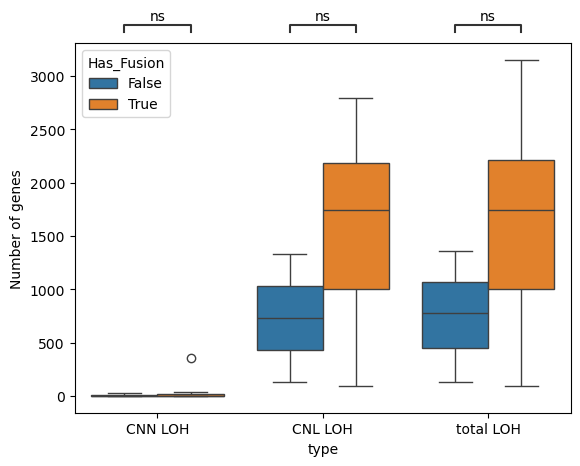

In [43]:
import seaborn as sns
from statannotations.Annotator import Annotator

ax = sns.boxplot(loh, x='type', y='Number of genes', hue='Has_Fusion')

annotator = Annotator(ax, data=loh, x='type', y='Number of genes', hue='Has_Fusion',
                    pairs=[(("CNN LOH", True), ("CNN LOH", False)),
                                 (("CNL LOH", True), ("CNL LOH", False)),
                                 (("total LOH", True), ("total LOH", False))
                                ])
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside')
annotator.apply_and_annotate()

In [44]:
ax.figure.savefig('paper_figures/boxplot_statictics.svg',dpi=600)

# 2. Generate a main table and calculate statistics

In [52]:
genes = pd.read_csv('~/Downloads/Oncobox/ACTH/true_genes.tsv', sep = '\t', index_col=0)
genes = genes[genes['0'].apply(lambda x: ('_' not in x) and ('chrY' not in x))]
genes.rename(columns = {'0': 'chr', '1': 'start', '2': 'end', '3': 'Gene'}, inplace = True)
genes

,chr,start,end,Gene,4,5,6,7,8
0,chr1,11873,14408,DDX11L1,0,.,0,0,"253,66,253"
1,chr1,14361,29369,WASH7P,0,.,0,0,"253,66,253"
2,chr1,17368,17435,MIR6859-1,0,.,0,0,"9,99,11"
3,chr1,29773,35417,MIR1302-2HG,0,.,0,0,"9,99,11"
4,chr1,30365,30502,MIR1302-2,0,.,0,0,"9,99,11"
...,...,...,...,...,...,...,...,...,...
41766,chr22,50672822,50733211,SHANK3,0,.,0,0,"13,20,118"
41767,chr22,50691259,50691362,RNU6-409P,0,.,0,0,"253,66,253"
41768,chr22,50738203,50745338,ACR,0,.,0,0,"13,20,118"
41769,chr22,50757085,50799636,RPL23AP82,0,.,0,0,"253,66,253"


In [53]:
genes_names = pd.read_csv("../CNV/all_genes_names.txt", sep="\t")
genes_names

/tmp/ipykernel_15551/3532897341.py:1: DtypeWarning: Columns (32,34,38,40,50) have mixed types. Specify dtype option on import or set low_memory=False.
  genes_names = pd.read_csv("../CNV/all_genes_names.txt", sep="\t")


,hgnc_id,symbol,name,locus_group,locus_type,status,location,location_sortable,alias_symbol,alias_name,...,cd,lncrnadb,enzyme_id,intermediate_filament_db,rna_central_ids,lncipedia,gtrnadb,agr,mane_select,gencc
0,HGNC:5,A1BG,alpha-1-B glycoprotein,protein-coding gene,gene with protein product,Approved,19q13.43,19q13.43,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HGNC:5,ENST00000263100.8|NM_130786.4,NaN
1,HGNC:37133,A1BG-AS1,A1BG antisense RNA 1,non-coding RNA,"RNA, long non-coding",Approved,19q13.43,19q13.43,FLJ23569,NaN,...,NaN,NaN,NaN,NaN,NaN,A1BG-AS1,NaN,HGNC:37133,NaN,NaN
2,HGNC:24086,A1CF,APOBEC1 complementation factor,protein-coding gene,gene with protein product,Approved,10q11.23,10q11.23,ACF|ASP|ACF64|ACF65|APOBEC1CF,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HGNC:24086,ENST00000373997.8|NM_014576.4,NaN
3,HGNC:7,A2M,alpha-2-macroglobulin,protein-coding gene,gene with protein product,Approved,12p13.31,12p13.31,FWP007|S863-7|CPAMD5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HGNC:7,ENST00000318602.12|NM_000014.6,HGNC:7
4,HGNC:27057,A2M-AS1,A2M antisense RNA 1,non-coding RNA,"RNA, long non-coding",Approved,12p13.31,12p13.31,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,A2M-AS1,NaN,HGNC:27057,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43790,HGNC:25820,ZYG11B,"zyg-11 family member B, cell cycle regulator",protein-coding gene,gene with protein product,Approved,1p32.3,01p32.3,FLJ13456,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HGNC:25820,ENST00000294353.7|NM_024646.3,HGNC:25820
43791,HGNC:13200,ZYX,zyxin,protein-coding gene,gene with protein product,Approved,7q34,07q34,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HGNC:13200,ENST00000322764.10|NM_003461.5,NaN
43792,HGNC:51695,ZYXP1,zyxin pseudogene 1,pseudogene,pseudogene,Approved,8q24.23,08q24.23,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HGNC:51695,NaN,NaN
43793,HGNC:29027,ZZEF1,zinc finger ZZ-type and EF-hand domain contain...,protein-coding gene,gene with protein product,Approved,17p13.2,17p13.2,KIAA0399|ZZZ4|FLJ10821,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HGNC:29027,ENST00000381638.7|NM_015113.4,NaN


In [54]:
productibe_genes = set(genes_names[genes_names.locus_group.apply(lambda x: x not in {'pseudogene', 'other'})].symbol)
genes = genes[genes.Gene.apply(lambda x: x in productibe_genes)]
genes.shape

(27164, 9)

In [55]:
def make_gene_table(dir_):
    statuses_list = []
    csv_files = glob.glob(dir_ + "/*.csv")
    
    for file in csv_files:
        
        file_name = file.split('/')[-1]
        sample_name = file_name.replace('_loh_annotated.csv', '')
       
        if sample_name == 'W_FGF_8_S134':
            continue
        
        df = pd.read_csv(file)
        df = df[df['type'].str.contains('LOH', na=False) & (df['M.flagged']==False)]

        affected_genes_all = pd.DataFrame()

        for _, seg in df.iterrows():

            genes_cur = genes[genes.chr == seg.chr]
            genes_cur = genes_cur[(genes_cur.start >= seg.start) & (genes_cur.end <= seg.end)]
            affected_genes = genes_cur[['Gene', 'start', 'end']]
            affected_genes['chr'] = seg.chr
            affected_genes['seg_start'] = seg.start
            affected_genes['seg_end'] = seg.end
            affected_genes['seg_status'] = 1
            affected_genes_all = pd.concat([affected_genes_all, affected_genes])


        unaffected_genes = pd.DataFrame(list(set(genes.Gene).difference(set(affected_genes_all.Gene))))
        unaffected_genes.rename(columns = {0:'Gene'}, inplace = True)
        unaffected_genes['seg_status'] = 0
        
        total_statuses = pd.concat([unaffected_genes, affected_genes_all[['Gene','seg_status']]]).set_index('Gene')
        total_statuses.rename(columns = {'seg_status': '_'.join(sample_name.split('_')[0:3])}, inplace=True)
        statuses_list.append(total_statuses)

    res_df = pd.concat(statuses_list, axis=1)
#    res_df.index.names = ['Gene']
    return res_df

In [56]:
res = make_gene_table('LOH_segments')

/tmp/ipykernel_15551/3253981.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  affected_genes['chr'] = seg.chr
/tmp/ipykernel_15551/3253981.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  affected_genes['seg_start'] = seg.start
/tmp/ipykernel_15551/3253981.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gui

In [57]:
print(f'Number of genes not pseodogene and other: {res.shape[0]}')
protein_coding_genes = genes_names[genes_names['locus_group'] == 'protein-coding gene']['symbol']
res_cds = res[res.index.isin(protein_coding_genes)]
print(f'Number of only protein-coding genes: {res_cds.shape[0]}')

Number of genes not pseodogene and other: 27164
Number of only protein-coding genes: 19151


In [58]:
res['start'] = res.index.map(dict(zip(genes['Gene'],genes['start'])))
res['end'] = res.index.map(dict(zip(genes['Gene'],genes['end'])))
res['chr'] = res.index.map(dict(zip(genes['Gene'],genes['chr'])))

In [59]:
res

,W_FGF_7,W_FGF_1,W_FGF_4,W_FGF_16,W_FGF_6,W_FGF_3,W_FGF_15,W_FGF_13,W_FGF_12,W_FGF_10,start,end,chr
Gene,,,,,,,,,,,,,
FNIP1,0,0,0,0,0,0,0,0,0,0,131641713,131797016,chr5
ZBTB24-DT,0,0,0,0,0,0,0,0,0,0,109482678,109502195,chr6
ELN-AS1,0,0,0,0,0,0,0,0,0,0,74058904,74062279,chr7
NMRK2,0,0,0,0,0,0,0,0,0,0,3933068,3942415,chr19
HMSD,0,0,0,0,0,0,0,0,0,0,63949300,63969647,chr18
...,...,...,...,...,...,...,...,...,...,...,...,...,...
F8A3,1,0,0,0,0,0,0,1,0,0,155456913,155458619,chrX
MIR1184-3,1,0,0,0,0,0,0,1,0,0,155457516,155457614,chrX
H2AB3,1,0,0,0,0,0,0,1,0,0,155459414,155460004,chrX


In [185]:
res.to_csv('FGF23_LOH_statuses.csv')

In [60]:
res = res.sort_values(['chr', 'start'],)
chrom_order = ['chr' + str(i) for i in range(1, 23)]
res = res.reset_index().set_index('chr').loc[chrom_order].reset_index().set_index('Gene').drop(['start', 'chr', 'end'], axis = 1)
res

,W_FGF_7,W_FGF_1,W_FGF_4,W_FGF_16,W_FGF_6,W_FGF_3,W_FGF_15,W_FGF_13,W_FGF_12,W_FGF_10
Gene,,,,,,,,,,
MIR6859-1,0,0,0,0,0,0,0,0,0,0
MIR1302-2HG,0,0,0,0,0,0,0,0,0,0
MIR1302-2,0,0,0,0,0,0,0,0,0,0
FAM138A,0,0,0,0,0,0,0,0,0,0
OR4F5,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
MAPK8IP2,0,0,0,0,0,0,1,0,0,0
ARSA,0,0,0,0,0,0,1,0,0,0
SHANK3,0,0,0,0,0,0,1,0,0,0


# 3. PCA visualization of LOH and CNV

In [11]:
def transform_PCA(res_df):
    embedding = PCA(n_components=2,)
    
    X_transformed = embedding.fit_transform(res_df.T)
    
    
    X_transformed = pd.DataFrame(X_transformed)
    X_transformed['sample_id'] = pd.Series(res_df.columns)
    
    return X_transformed, embedding

In [12]:
filt_trans, embedding = transform_PCA(res)
filt_trans.set_index('sample_id', inplace=True)
filt_trans

,0,1
sample_id,,
W_FGF_7,-39.589749,-13.186781
W_FGF_1,15.885855,13.742790
W_FGF_4,0.545732,-6.140032
W_FGF_16,15.516546,-10.831434
W_FGF_6,-6.024124,7.627519
W_FGF_3,2.289835,-4.085741
W_FGF_15,16.416767,-16.539496
W_FGF_13,-4.311352,3.742935
W_FGF_12,4.764487,-8.282010


/tmp/ipykernel_130443/66614106.py:78: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


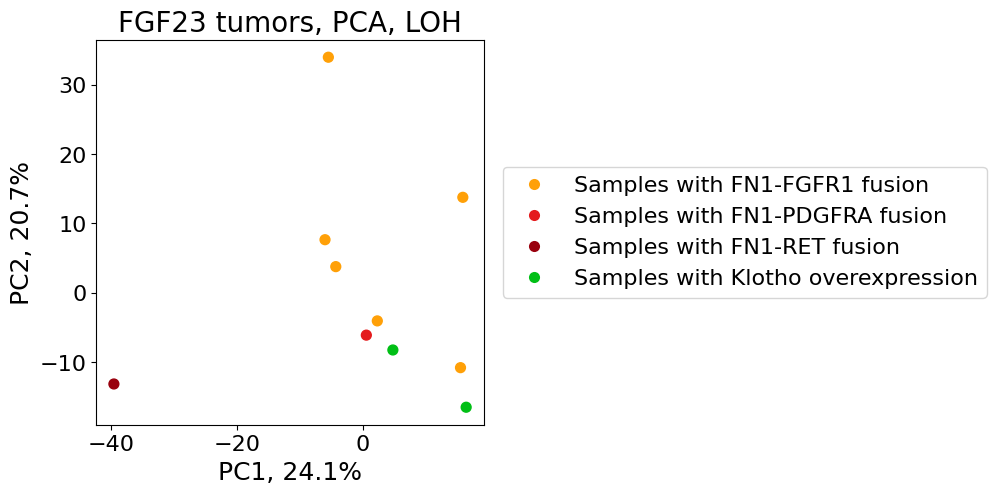

In [16]:
# Set global font sizes
plt.rcParams.update({
    'font.size': 18,         # Base font size
    'axes.titlesize': 20,    # Title font
    'axes.labelsize': 18,    # Axis labels
    'xtick.labelsize': 16,   # X tick labels
    'ytick.labelsize': 16,   # Y tick labels
    'legend.fontsize': 16
})

# --- color mapping (index -> color) ---
def rgba_from_hex8(hex8: str):
    hex8 = hex8.strip().lstrip('#')
    rgb = f"#{hex8[:6]}"
    a = int(hex8[6:8], 16) / 255.0
    return rgb, a

group_ffa007fe = {'W_FGF_1','W_FGF_3','W_FGF_6','W_FGF_10','W_FGF_13','W_FGF_16'}
group_fb6a4afe = {'W_FGF_4'}
group_e41a1cfe = {'W_FGF_7'}
group_00bf15fe = {'W_FGF_12','W_FGF_15'}

rgb1, a1 = rgba_from_hex8('ffa007fe')
rgb2, a2 = rgba_from_hex8('e41a1cfe')
rgb3, a3 = rgba_from_hex8('99000dfe')
rgb4, a4 = rgba_from_hex8('00bf15fe')

# default (если образец не в списках)
default_rgb, default_a = '#808080', 0.6

colors = []
alphas = []
for idx in filt_trans.index.astype(str):
    if idx in group_ffa007fe:
        colors.append(rgb1); alphas.append(a1)
    elif idx in group_fb6a4afe:
        colors.append(rgb2); alphas.append(a2)
    elif idx in group_e41a1cfe:
        colors.append(rgb3); alphas.append(a3)
    elif idx in group_00bf15fe:
        colors.append(rgb4); alphas.append(a4)
    else:
        colors.append(default_rgb); alphas.append(default_a)
        
# Scatter plot
plt.figure(figsize=(5, 5))
sc = plt.scatter(filt_trans[0], filt_trans[1], s=50, c=colors)
# применяем альфу по-точечно (matplotlib не принимает список alpha напрямую в scatter)
sc.set_alpha(None)
sc.set_facecolors([
    (*plt.matplotlib.colors.to_rgb(c), a)
    for c, a in zip(colors, alphas)
])

plt.xlabel(f'PC1, {embedding.explained_variance_ratio_[0]*100:.1f}%')
plt.ylabel(f'PC2, {embedding.explained_variance_ratio_[1]*100:.1f}%')
plt.title('FGF23 tumors, PCA, LOH')

# legend
handles = [
    plt.Line2D([0],[0], marker='o', linestyle='', markersize=8,
               markerfacecolor=rgb1, markeredgecolor='none', alpha=a1,
               label='Samples with FN1-FGFR1 fusion'),
    plt.Line2D([0],[0], marker='o', linestyle='', markersize=8,
               markerfacecolor=rgb2, markeredgecolor='none', alpha=a2,
               label='Samples with FN1-PDGFRA fusion'),
    plt.Line2D([0],[0], marker='o', linestyle='', markersize=8,
               markerfacecolor=rgb3, markeredgecolor='none', alpha=a3,
               label='Samples with FN1-RET fusion'),
    plt.Line2D([0],[0], marker='o', linestyle='', markersize=8,
               markerfacecolor=rgb4, markeredgecolor='none', alpha=a4,
               label='Samples with Klotho overexpression')
]
plt.legend(handles=handles, frameon=True, loc='center left',
    bbox_to_anchor=(1.02, 0.5))

#plt.style.use('default')
plt.tight_layout()
plt.savefig('./paper_figures/FGF23_pca_loh.png', bbox_inches='tight')

In [97]:
#same analysis for CNV

cnv = pd.read_csv("../CNV/CNV_statuses_FGF.tsv", sep="\t")
cnv = cnv.set_index("Gene")
cnv.drop(columns='W_FGF_8', inplace=True)
cnv

,W_FGF_3,W_FGF_15,W_FGF_6,W_FGF_1,W_FGF_10,W_FGF_7,W_FGF_16,W_FGF_4,W_FGF_12,W_FGF_13
Gene,,,,,,,,,,
MIR6859-1,0,0,0,0,0,0,0,0,0,0
MIR1302-2HG,0,0,0,0,0,0,0,0,0,0
MIR1302-2,0,0,0,0,0,0,0,0,0,0
FAM138A,0,0,0,0,0,0,0,0,0,0
OR4F5,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
TMLHE,0,0,0,0,0,-,0,0,0,0
SPRY3,0,0,0,0,0,-,0,0,0,0
VAMP7,0,0,0,0,0,-,0,0,0,0


In [99]:
cnv_del = cnv.map(lambda x: 1 if x =='-' else 0)

filt_trans, embedding = transform_PCA(cnv_del)
filt_trans.set_index('sample_id', inplace=True)
filt_trans

,0,1
sample_id,,
W_FGF_3,-7.574616,-8.610307
W_FGF_15,2.513087,30.626201
W_FGF_6,-2.970520,-16.362587
W_FGF_1,-17.570507,4.383266
W_FGF_10,-6.622928,-7.140709
W_FGF_7,47.782096,-5.756808
W_FGF_16,0.267424,23.082027
W_FGF_4,-5.566442,-9.269687
W_FGF_12,-5.078696,-4.823244


/tmp/ipykernel_52422/1600449292.py:94: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


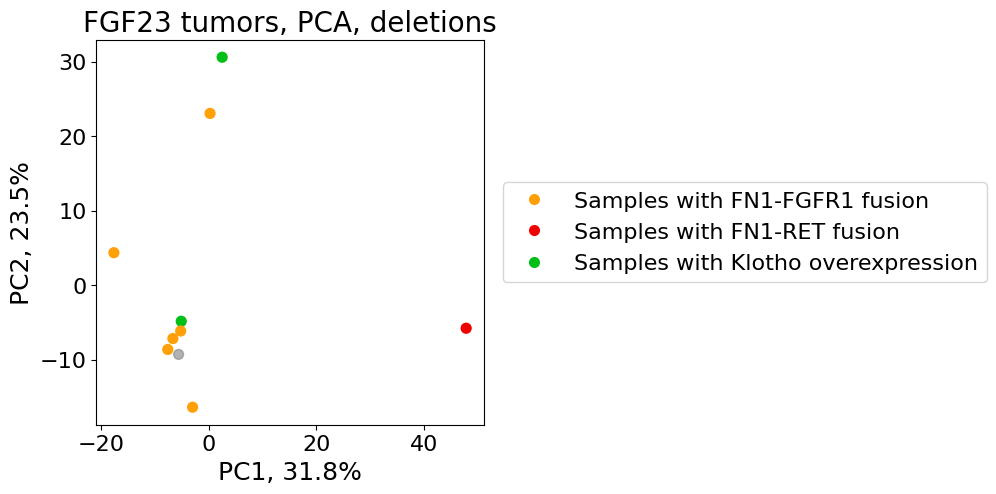

In [91]:
# Set global font sizes
plt.rcParams.update({
    'font.size': 18,         # Base font size
    'axes.titlesize': 20,    # Title font
    'axes.labelsize': 18,    # Axis labels
    'xtick.labelsize': 16,   # X tick labels
    'ytick.labelsize': 16,   # Y tick labels
    'legend.fontsize': 16
})

# --- color mapping (index -> color) ---
def rgba_from_hex8(hex8: str):
    hex8 = hex8.strip().lstrip('#')
    rgb = f"#{hex8[:6]}"
    a = int(hex8[6:8], 16) / 255.0
    return rgb, a

group_ffa007fe = {'W_FGF_1','W_FGF_3','W_FGF_6','W_FGF_10','W_FGF_13','W_FGF_16'}
group_f00000fe = {'W_FGF_7'}
group_00bf15fe = {'W_FGF_12','W_FGF_15'}

rgb1, a1 = rgba_from_hex8('ffa007fe')
rgb2, a2 = rgba_from_hex8('f00000fe')
rgb3, a3 = rgba_from_hex8('00bf15fe')

# default (если образец не в списках)
default_rgb, default_a = '#808080', 0.6

colors = []
alphas = []
for idx in filt_trans.index.astype(str):
    if idx in group_ffa007fe:
        colors.append(rgb1); alphas.append(a1)
    elif idx in group_f00000fe:
        colors.append(rgb2); alphas.append(a2)
    elif idx in group_00bf15fe:
        colors.append(rgb3); alphas.append(a3)
    else:
        colors.append(default_rgb); alphas.append(default_a)
        
# Scatter plot
plt.figure(figsize=(5, 5))
sc = plt.scatter(filt_trans[0], filt_trans[1], s=50, c=colors)
# применяем альфу по-точечно (matplotlib не принимает список alpha напрямую в scatter)
sc.set_alpha(None)
sc.set_facecolors([
    (*plt.matplotlib.colors.to_rgb(c), a)
    for c, a in zip(colors, alphas)
])

# Annotate points
#texts = []
#for idx in filt_trans.index:
#    texts.append(
#        plt.text(
#            filt_trans.loc[idx, 0],
#            filt_trans.loc[idx, 1],
#            str(idx),
#            fontsize=15,   # Increased annotation font size
#            alpha=0.8
#        )
#    )
#
# Adjust text to avoid overlap
#adjust_text(
#    texts,
#    arrowprops=dict(arrowstyle='-', color='gray', lw=0.6),
#    force_points=0.3,
#    force_text=0.5,
#    expand_points=(1.2, 1.4),
#    expand_text=(1.2, 1.4),
#)

plt.xlabel(f'PC1, {embedding.explained_variance_ratio_[0]*100:.1f}%')
plt.ylabel(f'PC2, {embedding.explained_variance_ratio_[1]*100:.1f}%')
plt.title('FGF23 tumors, PCA, deletions')

# legend
handles = [
    plt.Line2D([0],[0], marker='o', linestyle='', markersize=8,
               markerfacecolor=rgb1, markeredgecolor='none', alpha=a1,
               label='Samples with FN1-FGFR1 fusion'),
    plt.Line2D([0],[0], marker='o', linestyle='', markersize=8,
               markerfacecolor=rgb2, markeredgecolor='none', alpha=a2,
               label='Samples with FN1-RET fusion'),
    plt.Line2D([0],[0], marker='o', linestyle='', markersize=8,
               markerfacecolor=rgb3, markeredgecolor='none', alpha=a3,
               label='Samples with Klotho overexpression'),
]
plt.legend(handles=handles, frameon=True, loc='center left',
    bbox_to_anchor=(1.02, 0.5))

#plt.style.use('default')
plt.tight_layout()
plt.savefig('./paper_figures/FGF23_pca_deletions.svg', bbox_inches='tight')

In [100]:
cnv_dup = cnv.map(lambda x: 1 if x =='+' else 0)

filt_trans, embedding = transform_PCA(cnv_dup)
filt_trans.set_index('sample_id', inplace=True)
filt_trans

,0,1
sample_id,,
W_FGF_3,45.386047,9.521382
W_FGF_15,-5.104339,-7.062964
W_FGF_6,-4.096848,-4.145203
W_FGF_1,-4.928184,-7.134957
W_FGF_10,-4.831369,-5.865186
W_FGF_7,-16.615281,35.943807
W_FGF_16,-4.727554,-4.409293
W_FGF_4,-2.677466,-6.094821
W_FGF_12,-3.079312,-4.963766


/tmp/ipykernel_52422/145009021.py:94: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


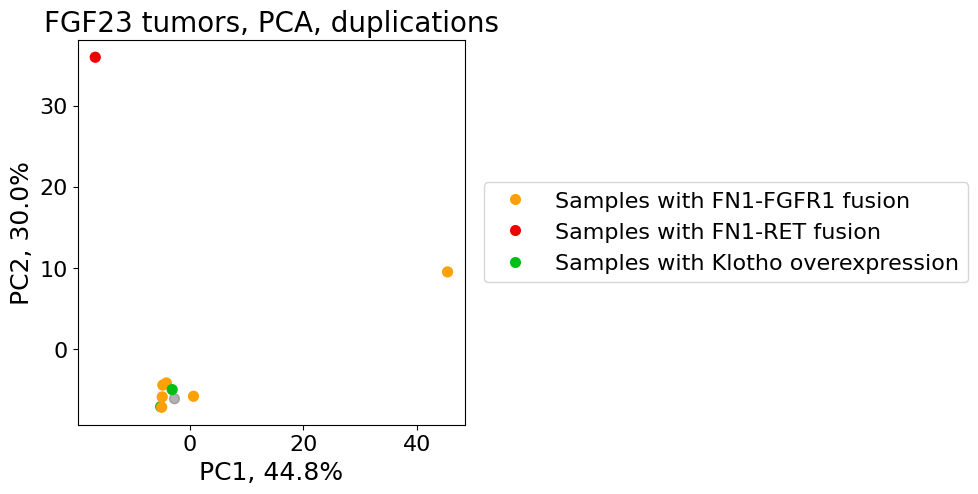

In [93]:
# Set global font sizes
plt.rcParams.update({
    'font.size': 18,         # Base font size
    'axes.titlesize': 20,    # Title font
    'axes.labelsize': 18,    # Axis labels
    'xtick.labelsize': 16,   # X tick labels
    'ytick.labelsize': 16,   # Y tick labels
    'legend.fontsize': 16
})

# --- color mapping (index -> color) ---
def rgba_from_hex8(hex8: str):
    hex8 = hex8.strip().lstrip('#')
    rgb = f"#{hex8[:6]}"
    a = int(hex8[6:8], 16) / 255.0
    return rgb, a

group_ffa007fe = {'W_FGF_1','W_FGF_3','W_FGF_6','W_FGF_10','W_FGF_13','W_FGF_16'}
group_f00000fe = {'W_FGF_7'}
group_00bf15fe = {'W_FGF_12','W_FGF_15'}

rgb1, a1 = rgba_from_hex8('ffa007fe')
rgb2, a2 = rgba_from_hex8('f00000fe')
rgb3, a3 = rgba_from_hex8('00bf15fe')

# default (если образец не в списках)
default_rgb, default_a = '#808080', 0.6

colors = []
alphas = []
for idx in filt_trans.index.astype(str):
    if idx in group_ffa007fe:
        colors.append(rgb1); alphas.append(a1)
    elif idx in group_f00000fe:
        colors.append(rgb2); alphas.append(a2)
    elif idx in group_00bf15fe:
        colors.append(rgb3); alphas.append(a3)
    else:
        colors.append(default_rgb); alphas.append(default_a)
        
# Scatter plot
plt.figure(figsize=(5, 5))
sc = plt.scatter(filt_trans[0], filt_trans[1], s=50, c=colors)
# применяем альфу по-точечно (matplotlib не принимает список alpha напрямую в scatter)
sc.set_alpha(None)
sc.set_facecolors([
    (*plt.matplotlib.colors.to_rgb(c), a)
    for c, a in zip(colors, alphas)
])

# Annotate points
#texts = []
#for idx in filt_trans.index:
#    texts.append(
#        plt.text(
#            filt_trans.loc[idx, 0],
#            filt_trans.loc[idx, 1],
#            str(idx),
#            fontsize=15,   # Increased annotation font size
#            alpha=0.8
#        )
#    )
#
# Adjust text to avoid overlap
#adjust_text(
#    texts,
#    arrowprops=dict(arrowstyle='-', color='gray', lw=0.6),
#    force_points=0.3,
#    force_text=0.5,
#    expand_points=(1.2, 1.4),
#    expand_text=(1.2, 1.4),
#)

plt.xlabel(f'PC1, {embedding.explained_variance_ratio_[0]*100:.1f}%')
plt.ylabel(f'PC2, {embedding.explained_variance_ratio_[1]*100:.1f}%')
plt.title('FGF23 tumors, PCA, duplications')

# legend
handles = [
    plt.Line2D([0],[0], marker='o', linestyle='', markersize=8,
               markerfacecolor=rgb1, markeredgecolor='none', alpha=a1,
               label='Samples with FN1-FGFR1 fusion'),
    plt.Line2D([0],[0], marker='o', linestyle='', markersize=8,
               markerfacecolor=rgb2, markeredgecolor='none', alpha=a2,
               label='Samples with FN1-RET fusion'),
    plt.Line2D([0],[0], marker='o', linestyle='', markersize=8,
               markerfacecolor=rgb3, markeredgecolor='none', alpha=a3,
               label='Samples with Klotho overexpression'),
]
plt.legend(handles=handles, frameon=True, loc='center left',
    bbox_to_anchor=(1.02, 0.5))

#plt.style.use('default')
plt.tight_layout()
plt.savefig('./paper_figures/FGF23_pca_duplications.svg', bbox_inches='tight')

# 4. CNV statistics

In [96]:
cnv = pd.read_csv("../CNV/CNV_statuses_FGF.tsv", sep="\t")
cnv = cnv.set_index("Gene")
cnv

,W_FGF_3,W_FGF_15,W_FGF_6,W_FGF_1,W_FGF_10,W_FGF_7,W_FGF_16,W_FGF_4,W_FGF_12,W_FGF_8,W_FGF_13
Gene,,,,,,,,,,,
MIR6859-1,0,0,0,0,0,0,0,0,0,0,0
MIR1302-2HG,0,0,0,0,0,0,0,0,0,0,0
MIR1302-2,0,0,0,0,0,0,0,0,0,0,0
FAM138A,0,0,0,0,0,0,0,0,0,0,0
OR4F5,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
TMLHE,0,0,0,0,0,-,0,0,0,0,0
SPRY3,0,0,0,0,0,-,0,0,0,0,0
VAMP7,0,0,0,0,0,-,0,0,0,0,0


In [97]:
columns_to_group = [s for s in cnv.columns.to_list() if s != 'W_FGF_8']

In [8]:
cnv_counts = pd.DataFrame({
    'Sample': columns_to_group,
    'Deletion_Count': [cnv[col].eq('-').sum() for col in columns_to_group],
    'Amplification_Count': [cnv[col].eq('+').sum() for col in columns_to_group],
    'CNV_Count': [cnv[col].isin(['-', '+']).sum() for col in columns_to_group]
})

In [9]:
cnv_counts.sort_values(by='CNV_Count', ascending=False)#.to_csv("../CNV/cnv_stats.csv", index=False)

,Sample,Deletion_Count,Amplification_Count,CNV_Count
5,W_FGF_7,3287,2132,5419
0,W_FGF_3,169,2906,3075
1,W_FGF_15,2025,49,2074
6,W_FGF_16,1678,302,1980
3,W_FGF_1,1747,72,1819
2,W_FGF_6,994,347,1341
8,W_FGF_12,564,593,1157
9,W_FGF_13,226,562,788
7,W_FGF_4,181,327,508
4,W_FGF_10,51,204,255


In [10]:
fusions = ['W_FGF_16', 'W_FGF_1', 'W_FGF_6', 'W_FGF_13', 'W_FGF_3', 'W_FGF_7', 'W_FGF_10']

cnv_counts.set_index('Sample', inplace=True)
cnv_counts['Has_Fusion'] = cnv_counts.index.isin(fusions)

cnv_counts

,Deletion_Count,Amplification_Count,CNV_Count,Has_Fusion
Sample,,,,
W_FGF_3,169,2906,3075,True
W_FGF_15,2025,49,2074,False
W_FGF_6,994,347,1341,True
W_FGF_1,1747,72,1819,True
W_FGF_10,51,204,255,True
W_FGF_7,3287,2132,5419,True
W_FGF_16,1678,302,1980,True
W_FGF_4,181,327,508,False
W_FGF_12,564,593,1157,False


In [11]:
amplification = cnv_counts[['Amplification_Count', 'Has_Fusion']]
amplification['type'] = 'Duplication'
amplification.rename(columns={'Amplification_Count': 'Number of genes'}, inplace=True)

deletion = cnv_counts[['Deletion_Count', 'Has_Fusion']]
deletion['type'] = 'Deletion'
deletion.rename(columns={'Deletion_Count': 'Number of genes'}, inplace=True)

CNV = cnv_counts[['CNV_Count', 'Has_Fusion']]
CNV['type'] = 'total CNV'
CNV.rename(columns={'CNV_Count': 'Number of genes'}, inplace=True)

cnv_plot = pd.concat([amplification, deletion, CNV])

/tmp/ipykernel_65944/2563325671.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amplification['type'] = 'Duplication'
/tmp/ipykernel_65944/2563325671.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amplification.rename(columns={'Amplification_Count': 'Number of genes'}, inplace=True)
/tmp/ipykernel_65944/2563325671.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_g

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Deletion_False vs. Deletion_True: Mann-Whitney-Wilcoxon test two-sided, P_val:1.000e+00 U_stat=1.100e+01
Duplication_False vs. Duplication_True: Mann-Whitney-Wilcoxon test two-sided, P_val:6.667e-01 U_stat=8.000e+00
total CNV_False vs. total CNV_True: Mann-Whitney-Wilcoxon test two-sided, P_val:6.667e-01 U_stat=8.000e+00


(<Axes: xlabel='type', ylabel='Number of genes'>,
  <statannotations.Annotation.Annotation at 0x7fe2dae50cd0>])

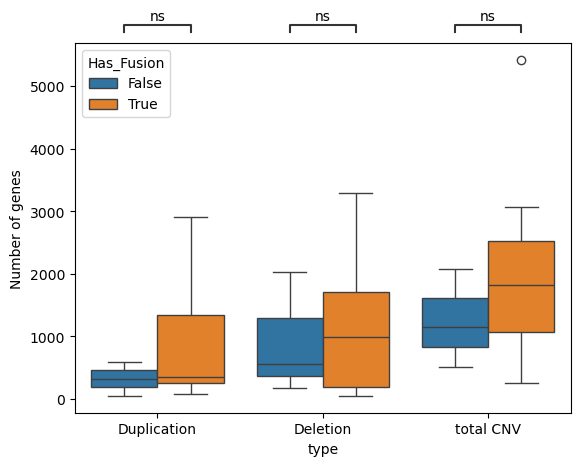

In [12]:
import seaborn as sns
from statannotations.Annotator import Annotator

ax = sns.boxplot(cnv_plot, x='type', y='Number of genes', hue='Has_Fusion')

annotator = Annotator(ax, data=cnv_plot, x='type', y='Number of genes', hue='Has_Fusion',
                    pairs=[(("Duplication", True), ("Duplication", False)),
                                 (("Deletion", True), ("Deletion", False)),
                                 (("total CNV", True), ("total CNV", False))
                                ])
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside')
annotator.apply_and_annotate()

In [13]:
ax.figure.savefig('paper_figures/boxplot_CNV_fusion.svg',dpi=600)

In [21]:
cnv['deletion_count'] = cnv.apply(lambda row: sum(s.count('-') for s in row if isinstance(s, str)), axis=1)
cnv['amplification_count'] = cnv.apply(lambda row: sum(s.count('+') for s in row if isinstance(s, str)), axis=1)
cnv['deletion_proportion'] = cnv.deletion_count / 10 * 100
cnv['amplification_proportion'] = cnv.amplification_count / 10 * 100

## Add bands

In [61]:
bands = pd.read_csv('~/Downloads/Oncobox/ideogram_9606_GCF_000001305.16_850_V1.tsv', sep='\t')
bands = bands.astype({'band': str})

In [80]:
bands[bands['#chromosome'] == 'X']

,#chromosome,arm,band,iscn_start,iscn_stop,bp_start,bp_stop,stain,density
811,X,p,22.33,0,323,1,4400000,gneg,NaN
812,X,p,22.32,323,504,4400001,6100000,gpos,50.0
813,X,p,22.31,504,866,6100001,9600000,gneg,NaN
814,X,p,22.2,866,1034,9600001,17400000,gpos,50.0
815,X,p,22.13,1034,1345,17400001,19200000,gneg,NaN
816,X,p,22.12,1345,1448,19200001,21900000,gpos,50.0
817,X,p,22.11,1448,1577,21900001,24900000,gneg,NaN
818,X,p,21.3,1577,1784,24900001,29300000,gpos,100.0
819,X,p,21.2,1784,1862,29300001,31500000,gneg,NaN
820,X,p,21.1,1862,2120,31500001,37800000,gpos,100.0


In [62]:
def get_bands(table):
    band_res = {}
    
    for name, gene in table.iterrows():
        try:
            band_res[name] = []
            bands_res = bands[(((bands.bp_start<=gene.start)&(gene.start<bands.bp_stop))|((bands.bp_start<gene.end)&(gene.end<=bands.bp_stop)))&(('chr'+bands['#chromosome']) == gene.chr)] 
            if len(bands_res.index) != 0:
                for _, band in bands_res.iterrows(): 
                    band_res[name].append(band['#chromosome'] + band.arm + band.band.strip("0"))
            else:
                band_res[nae].append('NA')
            band_res[name] = ';'.join(band_res[name])
        except Exception:
            band_res[name] = 'NaN'
    
    table['region'] = table.index.map(band_res)

In [98]:
cnv = pd.read_csv("../CNV/CNV_statuses_FGF.tsv", sep="\t")
cnv.drop(columns = ['W_FGF_8'], inplace=True)
cnv = cnv.set_index("Gene")

In [68]:
genes = pd.read_csv('~/Downloads/Oncobox/ACTH/true_genes.tsv', sep = '\t', index_col=0)
genes = genes[genes['0'].apply(lambda x: ('_' not in x) and ('chrY' not in x))]
genes.rename(columns = {'0': 'chr', '1': 'start', '2': 'end', '3': 'Gene'}, inplace = True)

cnv['start'] = cnv.index.map(dict(zip(genes['Gene'],genes['start'])))
cnv['end'] = cnv.index.map(dict(zip(genes['Gene'],genes['end'])))
cnv['chr'] = cnv.index.map(dict(zip(genes['Gene'],genes['chr'])))

In [69]:
get_bands(cnv)

In [113]:
cnv[cnv['W_FGF_4'].isin(['+'])].region.unique()

array(['1p36.13', '5q31.3', '6p22.2', '6p22.1', '11q12.3', '11q13.1',
       '17q21.2', '19q13.42', 'Xq28.'], dtype=object)

In [99]:
cnv[(cnv['W_FGF_4'].isin(['+']))&(cnv.region=='Xq28.')].shape

(31, 15)

In [110]:
genes = pd.read_csv('~/Downloads/Oncobox/ACTH/true_genes.tsv', sep = '\t', index_col=0)
genes = genes[genes['0'].apply(lambda x: ('_' not in x) and ('chrY' not in x))]
genes.rename(columns = {'0': 'chr', '1': 'start', '2': 'end', '3': 'Gene'}, inplace = True)

res['start'] = res.index.map(dict(zip(genes['Gene'],genes['start'])))
res['end'] = res.index.map(dict(zip(genes['Gene'],genes['end'])))
res['chr'] = res.index.map(dict(zip(genes['Gene'],genes['chr'])))

In [111]:
get_bands(res)

In [112]:
res[res['W_FGF_4'].isin([1])].region.unique()

array(['9p24.3', '9p24.2', '9p24.2;9p24.1', '9p24.1', '9p24.1;9p23.',
       '9p23.', '9p23.;9p22.3', '9p22.3', '9p22.1', '9p21.3', '9p21.2',
       '9p21.2;9p21.1', '9p21.1'], dtype=object)

In [ ]:
deleted_genes = '''ADAM18
FGF3
MUC3A
ITGAM
ITGAX
RYR1
ITPKA
LTK
RPAP1
TYRO3
SUN5
BPIFB2
BPIFB6
BPIFB3'''

deleted_genes = deleted_genes.split('\n')

In [ ]:
duplicated_genes = '''HLA-DOB
TAP2
TAP1
PSMB8
PSMB8-AS1
PSMB9
DHRS2
NBPF9
RNVU1-24'''

duplicated_genes = duplicated_genes.split('\n')

In [100]:
genes_of_interest = 'FGF23,KL,SLC30A3,SYT1,STX1A,SNAP25,PHEX,ERBB4,PCDH7,LRRFIP2,FN1,FGFR1'.split(',')

In [102]:
genes_of_pathway = 'FGFR1,RET,PDGFRA,KL,PLCB4,CAMK4,CAMK1,CAMK1G,CAMK2A,CAMK2B,CAMK2D,CAMKK1,CAMK1D,CAMKV,MEF2C,FGF23'.split(',')

In [103]:
cnv.reindex(genes_of_pathway)#[cnv.region.str.contains('1p')]

,W_FGF_3,W_FGF_15,W_FGF_6,W_FGF_1,W_FGF_10,W_FGF_7,W_FGF_16,W_FGF_4,W_FGF_12,W_FGF_13
Gene,,,,,,,,,,
FGFR1,0,0,0,0,0,-,0,0,0,0
RET,0,0,0,0,0,0,0,0,0,0
PDGFRA,0,0,0,0,0,0,0,0,0,0
KL,0,0,0,-,0,0,-,0,0,0
PLCB4,0,0,0,0,0,0,0,0,0,0
CAMK4,0,0,0,0,0,0,0,0,0,0
CAMK1,0,0,-,0,0,0,0,0,0,0
CAMK1G,0,0,0,0,0,0,0,0,0,0
CAMK2A,0,0,0,0,0,0,0,0,0,0


In [105]:
cnv.loc['MZF1']

W_FGF_3     0
W_FGF_15    0
W_FGF_6     0
W_FGF_1     0
W_FGF_10    0
W_FGF_7     0
W_FGF_16    0
W_FGF_4     0
W_FGF_12    0
W_FGF_13    0
Name: MZF1, dtype: object

In [97]:
res['loh_count'] = res.select_dtypes(include='number').eq(1).sum(axis=1)

In [106]:
res.reindex(genes_of_interest)

,W_FGF_7,W_FGF_1,W_FGF_4,W_FGF_16,W_FGF_6,W_FGF_3,W_FGF_15,W_FGF_13,W_FGF_12,W_FGF_10
Gene,,,,,,,,,,
FGF23,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
KL,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
SLC30A3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
SYT1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
STX1A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SNAP25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PHEX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ERBB4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PCDH7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 5. Expression analysis of amplified and deleted genes

In [24]:
deseq = pd.read_csv('../RNA/FGF23_oncobox_08_10_2025.csv')
deseq = deseq.set_index('HGNC')
deseq_tumor = deseq.iloc[:,deseq.columns.str.contains('Tumor')]
col_rename = {i: '_'.join(i.split('_')[2:4]) for i in deseq_tumor.columns}
deseq_tumor.rename(columns=col_rename, inplace=True)

/tmp/ipykernel_65944/1146617409.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deseq_tumor.rename(columns=col_rename, inplace=True)


In [25]:
deseq_tumor

,FGF_1,FGF_10,FGF_12,FGF_13,FGF_15,FGF_16,FGF_2,FGF_3,FGF_4,FGF_6,FGF_7
HGNC,,,,,,,,,,,
TSPAN6,276.824729,194.987479,330.369045,158.531625,154.466466,259.188068,548.894438,101.410128,234.519623,371.419525,323.508066
TNMD,1.000000,9.817613,1.000000,1.000000,8.250384,1.737680,10.349734,1.573772,5.490762,1.717867,25.636033
DPM1,178.684844,217.031510,115.780122,144.045958,170.175632,256.975028,143.115963,108.295393,172.547108,231.435402,228.696667
SCYL3,210.709438,212.622704,222.242843,191.124375,194.947778,198.698292,308.606263,187.475951,278.529090,199.849241,175.691869
FIRRM,205.544181,123.344376,107.462722,156.720916,112.776757,170.666445,127.221415,98.541267,142.009926,126.626777,104.023410
...,...,...,...,...,...,...,...,...,...,...,...
MIR92B,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
MIR943,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
MIR7847,1.000000,3.204403,1.000000,4.621417,1.000000,2.475360,1.000000,1.000000,1.000000,1.000000,1.746546


In [26]:
deseq_clean = deseq_tumor.loc[(deseq_tumor != 1).all(axis=1)]
deseq_clean = np.log2(deseq_clean)
deseq_clean

,FGF_1,FGF_10,FGF_12,FGF_13,FGF_15,FGF_16,FGF_2,FGF_3,FGF_4,FGF_6,FGF_7
HGNC,,,,,,,,,,,
TSPAN6,8.112829,7.607238,8.367935,7.308627,7.271150,8.017855,9.100385,6.664058,7.873565,8.536906,8.337658
DPM1,7.481273,7.761761,6.855244,7.170385,7.410881,8.005484,7.161041,6.758828,7.430846,7.854466,7.837292
SCYL3,7.719111,7.732152,7.795993,7.578368,7.606944,7.634436,8.269624,7.550562,8.121684,7.642768,7.456904
FIRRM,7.683305,6.946548,6.747692,7.292054,6.817326,7.415036,6.991198,6.622656,7.149848,6.984439,6.700764
FGR,10.586040,8.732499,8.165503,6.284572,7.480866,9.370603,6.786490,7.606849,7.313562,5.937835,8.383530
...,...,...,...,...,...,...,...,...,...,...,...
MIR1244-2,1.616406,3.830501,2.582662,4.034834,3.044461,3.759216,4.550861,3.080494,2.675571,4.130185,3.775186
MIR5010,2.847658,3.714159,3.085027,2.685295,4.009434,1.982116,3.234924,1.951909,2.865338,2.198286,3.694294
PLD5P1,5.089907,4.132003,5.167241,4.990140,4.113814,4.043632,3.611135,4.775763,4.894375,4.188149,4.351219


In [27]:
cnv = pd.read_csv("../CNV/CNV_statuses_FGF.tsv", sep="\t")
cnv = cnv.set_index("Gene")
col_rename = {i:'_'.join(i.split('_')[1:]) for i in cnv.columns}
cnv.rename(columns=col_rename, inplace=True)

In [28]:
dup = pd.DataFrame(columns=['gene', 'overall_mean', 'ratio_plus_to_zero', 'p_value'])

for gene in cnv.index.unique():
    if gene not in deseq_clean.index:
        continue 
    
    df1_row = deseq_clean.loc[gene]
    df2_row = cnv.loc[gene]
    
    plus_samples = [sample for sample in df2_row.index if sample in df1_row.index and df2_row[sample] == '+']
    
    if len(plus_samples) == 0:
        continue
    
    zero_samples = [sample for sample in df2_row.index if sample in df1_row.index and df2_row[sample] == '0']
    all_samples = [sample for sample in df2_row.index if sample in df1_row.index]
    overall_mean = df1_row[all_samples].mean() if all_samples else np.nan
    mean_plus = df1_row[plus_samples].mean() if plus_samples else np.nan
    mean_zero = df1_row[zero_samples].mean() if zero_samples else np.nan
    ratio = mean_plus / mean_zero if mean_zero != 0 and not np.isnan(mean_zero) else np.nan
    
    p_value = np.nan
    if plus_samples and zero_samples:  
        plus_values = df1_row[plus_samples].dropna()
        zero_values = df1_row[zero_samples].dropna()
        if len(plus_values) > 0 and len(zero_values) > 0:  
            t_stat, p_value = ttest_ind(plus_values, zero_values, equal_var=False)  # Welch's t-test
    
    dup = pd.concat([dup, pd.DataFrame({
        'gene': [gene],
        'overall_mean': [overall_mean],
        'ratio_plus_to_zero': [ratio],
        'p_value': [p_value]
    })], ignore_index=True)

print(dup)

/tmp/ipykernel_65944/1274448463.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dup = pd.concat([dup, pd.DataFrame({


          gene  overall_mean  ratio_plus_to_zero   p_value
0       RNU1-2      2.912343            0.815564  0.628768
1       SEC22B      9.616533            0.993146       NaN
2        NBPF8      7.746918            1.069435       NaN
3       NBPF26      9.247563            1.022245       NaN
4     RNVU1-19      4.853443            0.925185       NaN
...        ...           ...                 ...       ...
2847    PLXNA3      9.735022            1.114380  0.350756
2848     LAGE3      5.183129            0.908962  0.447640
2849     UBL4A      8.061108            1.035577  0.669199
2850   SLC10A3      7.173629            1.036475  0.722503
2851     FAM3A      8.067264            1.029496  0.732353

[2852 rows x 4 columns]


In [29]:
del_ = pd.DataFrame(columns=['gene', 'overall_mean', 'ratio_minus_to_zero', 'p_value'])

for gene in cnv.index.unique():
    if gene not in deseq_clean.index:
        continue 
    
    df1_row = deseq_clean.loc[gene]
    df2_row = cnv.loc[gene]

    minus_samples = [sample for sample in df2_row.index if sample in df1_row.index and df2_row[sample] == '-']
    
    if len(minus_samples) == 0:
        continue
    
    zero_samples = [sample for sample in df2_row.index if sample in df1_row.index and df2_row[sample] == '0']
    all_samples = [sample for sample in df2_row.index if sample in df1_row.index]
    overall_mean = df1_row[all_samples].mean() if all_samples else np.nan
    mean_minus = df1_row[minus_samples].mean() if minus_samples else np.nan
    mean_zero = df1_row[zero_samples].mean() if zero_samples else np.nan
    ratio = mean_minus / mean_zero if mean_zero != 0 and not np.isnan(mean_zero) else np.nan
    
    p_value = np.nan
    if minus_samples and zero_samples:  
        minus_values = df1_row[minus_samples].dropna()
        zero_values = df1_row[zero_samples].dropna()
        if len(minus_values) > 0 and len(zero_values) > 0:  
            t_stat, p_value = ttest_ind(minus_values, zero_values, equal_var=False)  # Welch's t-test
 
    del_ = pd.concat([del_, pd.DataFrame({
        'gene': [gene],
        'overall_mean': [overall_mean],
        'ratio_minus_to_zero': [ratio],
        'p_value': [p_value]
    })], ignore_index=True)

print(del_)

/tmp/ipykernel_65944/3160986175.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  del_ = pd.concat([del_, pd.DataFrame({


          gene  overall_mean  ratio_minus_to_zero   p_value
0        NOC2L      8.972184             0.982239  0.415566
1         HES4      6.408632             0.931880  0.217628
2        ISG15      5.182351             1.296025  0.089466
3         AGRN     10.428696             0.920190  0.010833
4     C1orf159      7.107425             0.881912  0.002004
...        ...           ...                  ...       ...
3581      VBP1      7.003907             1.125393       NaN
3582     CLIC2      7.342015             0.779398       NaN
3583     TMLHE      7.073232             0.941831       NaN
3584     SPRY3      6.200173             0.924351       NaN
3585     VAMP7      7.972260             1.088883       NaN

[3586 rows x 4 columns]


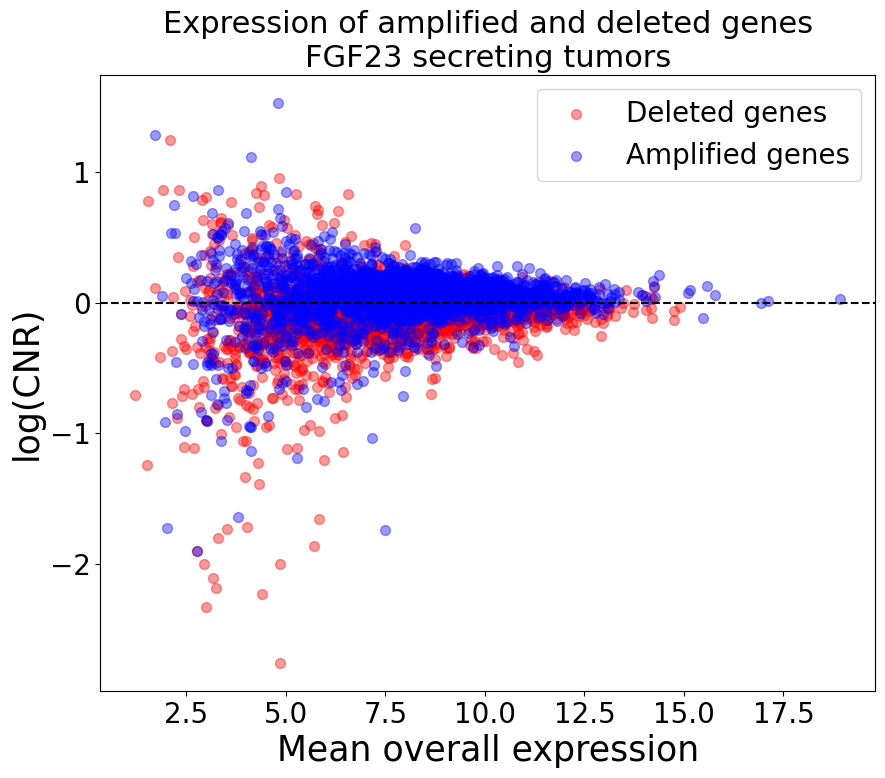

In [34]:
del_ = del_.dropna(subset=['ratio_minus_to_zero'])
dup = dup.dropna(subset=['ratio_plus_to_zero'])

del_filt = del_.dropna(subset=['ratio_minus_to_zero'])
dup_filt = dup.dropna(subset=['ratio_plus_to_zero'])

plt.figure(figsize=(10, 8))

plt.scatter(
    del_filt['overall_mean'], 
    np.log2(del_filt['ratio_minus_to_zero']), 
    color='red', 
    label='Deleted genes', 
    s=50,  
    alpha=0.4  
)

plt.scatter(
    dup_filt['overall_mean'], 
    np.log2(dup_filt['ratio_plus_to_zero']), 
    color='blue', 
    label='Amplified genes', 
    s=50, 
    alpha=0.4
)

plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)

plt.xlabel(r'$\log_2$(Mean overall expression)',fontsize=25)
plt.ylabel(r'$\log_2$(CNR)',fontsize=25)
plt.title('Expression of amplified and deleted genes\nFGF23 secreting tumors',fontsize=22)
plt.legend(fontsize=20)  

plt.xticks(fontsize=20)  
plt.yticks(fontsize=20)

plt.savefig('./paper_figures/Exp_dup_del.png', dpi=300, bbox_inches='tight')
plt.show()

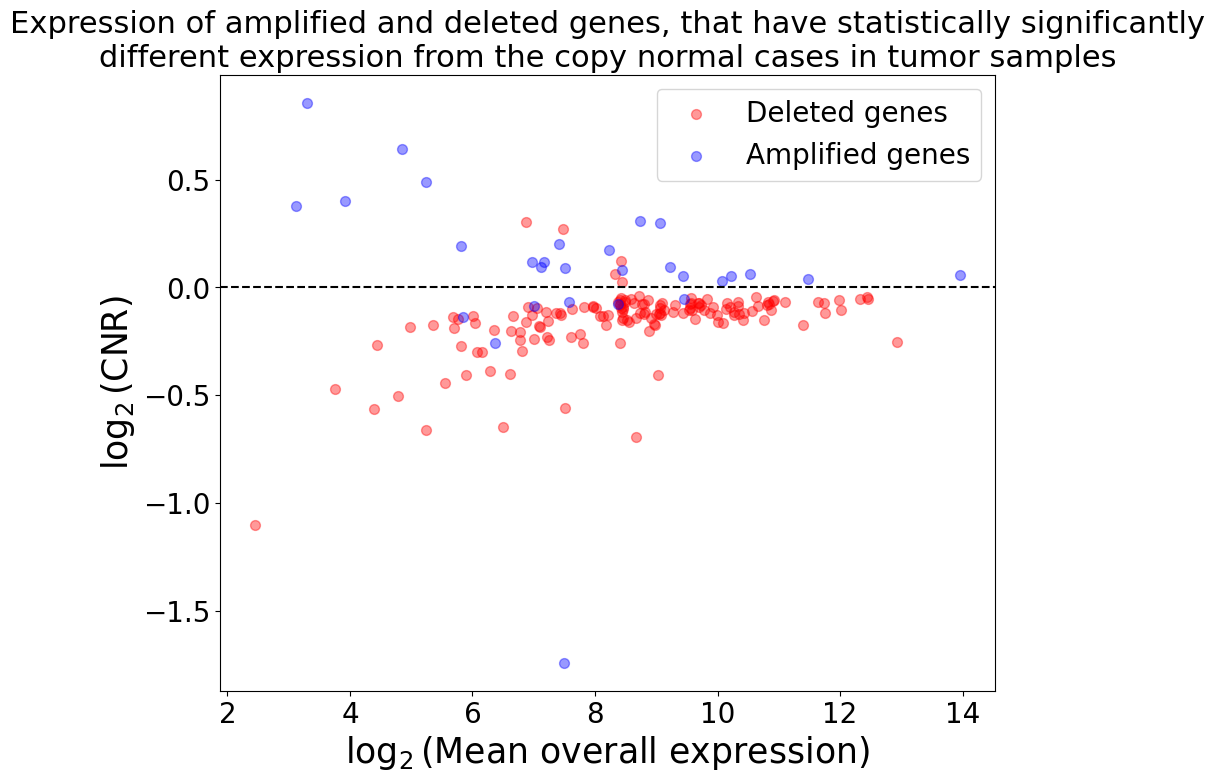

In [31]:
del_filt = del_[del_.p_value < 0.05]
dup_filt = dup[dup.p_value < 0.05]

del_filt = del_filt.dropna(subset=['ratio_minus_to_zero'])
dup_filt = dup_filt.dropna(subset=['ratio_plus_to_zero'])

plt.figure(figsize=(10, 8))

plt.scatter(
    del_filt['overall_mean'], 
    np.log2(del_filt['ratio_minus_to_zero']), 
    color='red', 
    label='Deleted genes', 
    s=50,  
    alpha=0.4  
)

plt.scatter(
    dup_filt['overall_mean'], 
    np.log2(dup_filt['ratio_plus_to_zero']), 
    color='blue', 
    label='Amplified genes', 
    s=50, 
    alpha=0.4
)

plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)

plt.xlabel(r'$\log_2$(Mean overall expression)',fontsize=25)
plt.ylabel(r'$\log_2$(CNR)',fontsize=25)
plt.title('Expression of amplified and deleted genes, that have statistically significantly\ndifferent expression from the copy normal cases in tumor samples',fontsize=22)
plt.legend(fontsize=20)  

plt.xticks(fontsize=20)  
plt.yticks(fontsize=20)

plt.savefig('./paper_figures/Exp_dup_del_p_val.svg', dpi=300, bbox_inches='tight')
plt.show()

# 6. Dotplot of normalized genes

## 6a. Dotplot of LOH genes

In [48]:
genes = pd.read_csv('~/Downloads/Oncobox/ACTH/true_genes.tsv', sep = '\t', index_col=0)
genes = genes[genes['0'].apply(lambda x: ('_' not in x) and ('chrY' not in x))]
genes.rename(columns = {'0': 'chr', '1': 'start', '2': 'end', '3': 'Gene'}, inplace = True)

res['start'] = res.index.map(dict(zip(genes['Gene'],genes['start'])))
res['end'] = res.index.map(dict(zip(genes['Gene'],genes['end'])))
res['chr'] = res.index.map(dict(zip(genes['Gene'],genes['chr'])))

In [49]:
res_df = res

In [50]:
res_df.rename(columns = {'start': 'gene_start', 'end': 'gene_end', 'chr': 'gene_chrom', 'region': 'band'}, inplace=True)

In [51]:
res_list = []
cur_max = 0

chrom_order = ['chr' + str(i) for i in range(1, 23)]

for chrom in chrom_order:
    
    res_df_chr = res_df[res_df.gene_chrom == chrom]
    intervals_chr = np.arange(0, res_df_chr.gene_end.max(), 10**5)

    for i in range(len(intervals_chr) -1):

        res_df_chr_i = res_df_chr[(res_df_chr.gene_end >= intervals_chr[i]) & (res_df_chr.gene_end <= intervals_chr[i+1])].drop(['gene_start', 'gene_chrom', 'gene_end'], axis = 1)

        bin_loh = (res_df_chr_i.values == 1).sum()

        res_list.append(
                        {'chr': chrom,
                        'bin_coordinate': intervals_chr[i] + 10**5/2,
                        'bin_coordinate_adjusted': intervals_chr[i] + 10**5/2 + cur_max,
                        'loh': bin_loh,
                        'genes_number': len(res_df_chr_i),
                        'bin_genes': list(res_df_chr_i.index)})
    cur_max += intervals_chr[-1]

In [52]:
res_df = pd.DataFrame(res_list)
res_df

,chr,bin_coordinate,bin_coordinate_adjusted,loh,genes_number,bin_genes
0,chr1,50000.0,5.000000e+04,0,5,"[MIR6859-1, MIR1302-2HG, MIR1302-2, FAM138A, O..."
1,chr1,150000.0,1.500000e+05,0,0,[]
2,chr1,250000.0,2.500000e+05,0,0,[]
3,chr1,350000.0,3.500000e+05,0,0,[]
4,chr1,450000.0,4.500000e+05,0,1,[OR4F29]
...,...,...,...,...,...,...
28710,chr22,50250000.0,2.871050e+09,6,6,"[SELENOO, SELENOO-AS1, TUBGCP6, HDAC10, MAPK12..."
28711,chr22,50350000.0,2.871150e+09,2,2,"[PLXNB2, DENND6B]"
28712,chr22,50450000.0,2.871250e+09,5,5,"[PPP6R2, MIR12114, SBF1, ADM2, MIOX]"
28713,chr22,50550000.0,2.871350e+09,11,11,"[LMF2, NCAPH2, SCO2, TYMP, CIMAP1B, KLHDC7B-DT..."


In [53]:
res_df_filtered = res_df[res_df.genes_number != 0]

In [54]:
res_df_filtered['loh_per_gene'] = res_df_filtered['loh'] / res_df_filtered['genes_number']

/tmp/ipykernel_11736/2625239709.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_df_filtered['loh_per_gene'] = res_df_filtered['loh'] / res_df_filtered['genes_number']


In [55]:
res_df_filtered[res_df_filtered['loh_per_gene'] == res_df_filtered['loh_per_gene'].max()]#.genes_number.sum()

,chr,bin_coordinate,bin_coordinate_adjusted,loh,genes_number,bin_genes,loh_per_gene
21051,chr13,29950000.0,2.105150e+09,8,2,"[LINC00572, LINC00544]",4.0
21053,chr13,30150000.0,2.105350e+09,12,3,"[LINC00365, LINC00384, LINC00385]",4.0
21055,chr13,30350000.0,2.105550e+09,8,2,"[KATNAL1, LINC00426]",4.0
21056,chr13,30450000.0,2.105650e+09,8,2,"[LINC01058, UBE2L5]",4.0
21058,chr13,30650000.0,2.105850e+09,12,3,"[HMGB1, USPL1, TRN-GTT2-4]",4.0
21059,chr13,30750000.0,2.105950e+09,4,1,[ALOX5AP],4.0
21060,chr13,30850000.0,2.106050e+09,8,2,"[LINC00398, LINC00545]",4.0
21061,chr13,30950000.0,2.106150e+09,12,3,"[TEX26-AS1, MEDAG, TEX26]",4.0
21063,chr13,31150000.0,2.106350e+09,4,1,[HSPH1],4.0
21065,chr13,31350000.0,2.106550e+09,4,1,[B3GLCT],4.0


In [56]:
res_df_filtered['bin_genes_str'] = res_df_filtered.bin_genes.apply(lambda x: ', '.join(x))    

/tmp/ipykernel_11736/3089231544.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_df_filtered['bin_genes_str'] = res_df_filtered.bin_genes.apply(lambda x: ', '.join(x))


In [57]:
res_df_filtered[res_df_filtered.bin_genes_str.str.contains('ZAR1L')]

,chr,bin_coordinate,bin_coordinate_adjusted,loh,genes_number,bin_genes,loh_per_gene,bin_genes_str
21075,chr13,32350000.0,2.107550e+09,4,1,[ZAR1L],4.0,ZAR1L


In [58]:
res_df_filtered.loc[21065:21074,:]

,chr,bin_coordinate,bin_coordinate_adjusted,loh,genes_number,bin_genes,loh_per_gene,bin_genes_str
21065,chr13,31350000.0,2.106550e+09,4,1,[B3GLCT],4.0,B3GLCT
21070,chr13,31850000.0,2.107050e+09,4,1,[RXFP2],4.0,RXFP2
21072,chr13,32050000.0,2.107250e+09,4,1,[FRY-AS1],4.0,FRY-AS1
21074,chr13,32250000.0,2.107450e+09,4,1,[FRY],4.0,FRY


In [59]:
from scipy.signal import find_peaks

#def get_bordering_values(arr):
#    result = []
#    for val in arr:
#        result.extend([val-2, val, val+2])
#    return result
    
def get_bordering_values(peaks_idx, half_window=2):
    out = []
    for p in peaks_idx:
        out.extend(range(p-half_window, p+half_window+1))  # p-2..p+2
    return out

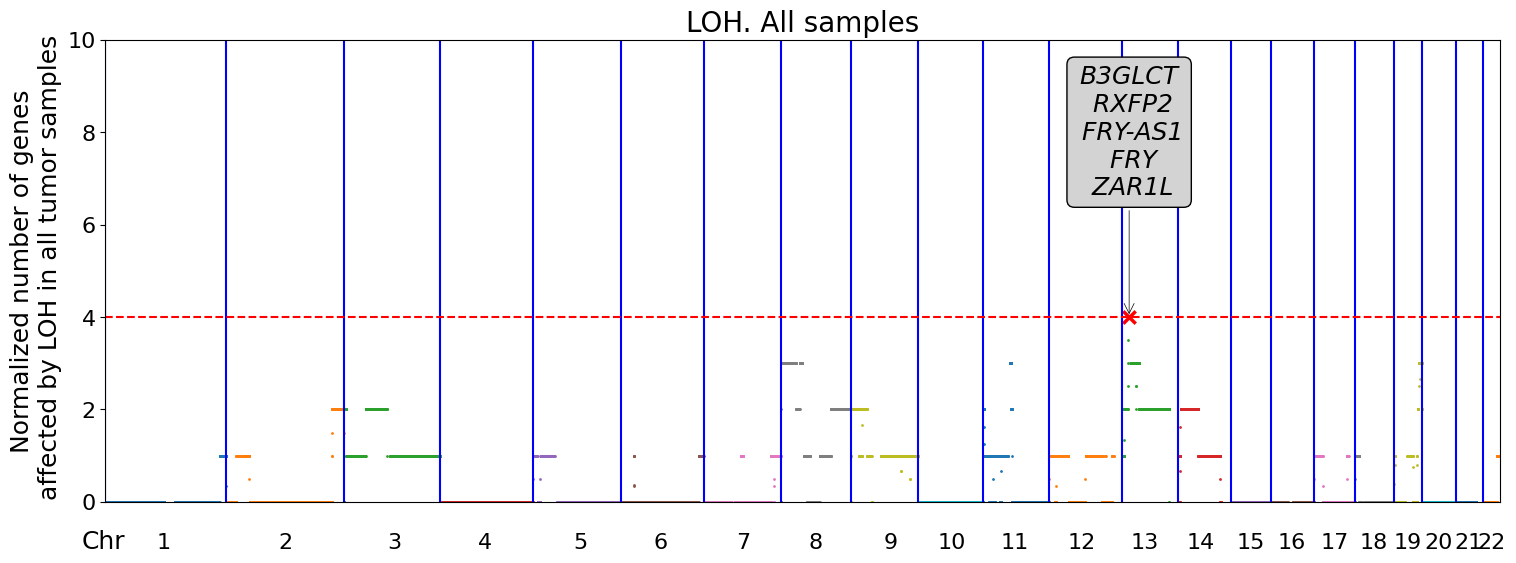

In [60]:
plt.style.use('default')

plt.figure(figsize=(18, 6))

peaks_list = []
broader_peaks_list = []

chrom_order = ['chr' + str(i) for i in range(1, 23)]
for chrom in chrom_order:
    res_df_filtered_chrom = res_df_filtered[res_df_filtered.chr == chrom]
    plt.scatter(res_df_filtered_chrom.bin_coordinate_adjusted, res_df_filtered_chrom.loh_per_gene, s=1)

    plt.text(res_df_filtered_chrom.bin_coordinate_adjusted.mean(), -1, chrom[3:], fontsize = 16, ha='center', color = 'black')
    plt.axvline(res_df_filtered_chrom.bin_coordinate_adjusted.min(), c='b')
    peaks = find_peaks(res_df_filtered_chrom.loh_per_gene, distance=25, height=4)
    
    plt.scatter(res_df_filtered_chrom.reset_index().loc[peaks[0]].bin_coordinate_adjusted, 
                res_df_filtered_chrom.reset_index().loc[peaks[0]].loh_per_gene, 
                marker='x', c='r', s=80, linewidths=2.5)
    peaks_list.append(res_df_filtered_chrom.reset_index().loc[peaks[0]])
    
    for i, p in enumerate(peaks[0]):
        # индексы окна
        idxs = list(range(p-2, p+3))  # half_window=2 -> 5 точек
        # срезаем по границам, чтобы не уйти в -1 или за конец
        idxs = [j for j in idxs if 0 <= j < len(res_df_filtered_chrom)]

        tmp = res_df_filtered_chrom.reset_index().loc[idxs].copy()
        tmp['peak_group'] = f"{chrom}_{i}"   # уникальная группа (можно просто i, но так безопаснее)
        broader_peaks_list.append(tmp)    
        
plt.xlim(0, cur_max)
plt.ylim(0, 10)

peaks_df = pd.concat(peaks_list)
broader_peaks_df = pd.concat(broader_peaks_list)
broader_peaks_df = broader_peaks_df[broader_peaks_df.loh_per_gene >= 4]

# Define aggregation rules
agg_dict = {
    'bin_genes': 'sum',
    'loh': 'sum',
    'genes_number': 'sum'
}

# For all other columns, determine aggregation based on data type
for col in broader_peaks_df.columns:
    if col not in ['peak_group', 'bin_genes', 'loh_per_gene', 'genes_number', 'loh']:
        # If column is numeric, use mean
        if pd.api.types.is_numeric_dtype(broader_peaks_df[col]):
            agg_dict[col] = 'mean'
        # If column is string or non-numeric, use first
        else:
            agg_dict[col] = 'first'
    
    # Group by peak_group and apply the aggregation
broader_peaks_df = broader_peaks_df.groupby('peak_group').agg(agg_dict).reset_index()
broader_peaks_df['bin_genes_str'] = broader_peaks_df.bin_genes.apply(lambda x: ', '.join(x))    
broader_peaks_df['loh_per_gene'] = broader_peaks_df['loh']/broader_peaks_df['genes_number']

for _,row in broader_peaks_df.iterrows():
    plt.annotate(
        row['bin_genes_str'].replace(',', '\n'), 
        xy=(row['bin_coordinate_adjusted'], row['loh_per_gene']),
        xytext=(row['bin_coordinate_adjusted'], row['loh_per_gene'] + 4),
        arrowprops=dict(arrowstyle='->', color='black', lw=0.5),
        bbox=dict(boxstyle='round', pad=0.3, fc='#D3D3D3', ec='black', lw=1),
        fontsize=18,
        fontstyle='italic',
        ha='center', va='center'
    )

plt.title('LOH. All samples', fontsize = 20)
plt.ylabel('Normalized number of genes\n affected by LOH in all tumor samples', fontsize = 18)

plt.xticks([], [])
plt.yticks(fontsize=16)
plt.text(-50000000, -1, 'Chr', fontsize = 18)
plt.axhline(4, c='r', linestyle = '--')	
plt.savefig('./paper_figures/loh_dotplot.svg')

In [127]:
broader_peaks_df

,peak_group,bin_genes,loh,genes_number,index,chr,bin_coordinate,bin_coordinate_adjusted,bin_genes_str,loh_per_gene
0,0,"[RXFP2, EEF1DP3, FRY-AS1]",12,3,21077.0,chr13,31950000.0,2.107750e+09,"RXFP2, EEF1DP3, FRY-AS1",4.0


In [75]:
top_genes = brader_peaks_df.bin_genes.to_list()

In [78]:
sum([len(i) for i in top_genes])

62

In [79]:
with open('ACTH_top_genes.txt', 'w') as f:
        for gene_list in top_genes:
            for gene in gene_list:
                f.write(gene + '\n')

## 6b. Dotplot of CNV genes

In [4]:
# same for cnv
cnv = pd.read_csv("../CNV/CNV_statuses_FGF.tsv", sep="\t")
cnv = cnv.set_index("Gene")
cnv.drop(columns=['W_FGF_8'], inplace=True)

genes = pd.read_csv('~/Downloads/Oncobox/ACTH/true_genes.tsv', sep = '\t', index_col=0)
genes = genes[genes['0'].apply(lambda x: ('_' not in x) and ('chrY' not in x))]
genes.rename(columns = {'0': 'chr', '1': 'start', '2': 'end', '3': 'Gene'}, inplace = True)

cnv['start'] = cnv.index.map(dict(zip(genes['Gene'],genes['start'])))
cnv['end'] = cnv.index.map(dict(zip(genes['Gene'],genes['end'])))
cnv['chr'] = cnv.index.map(dict(zip(genes['Gene'],genes['chr'])))

In [5]:
cnv

,W_FGF_3,W_FGF_15,W_FGF_6,W_FGF_1,W_FGF_10,W_FGF_7,W_FGF_16,W_FGF_4,W_FGF_12,W_FGF_13,start,end,chr
Gene,,,,,,,,,,,,,
MIR6859-1,0,0,0,0,0,0,0,0,0,0,17368,17435,chr1
MIR1302-2HG,0,0,0,0,0,0,0,0,0,0,29773,35417,chr1
MIR1302-2,0,0,0,0,0,0,0,0,0,0,30365,30502,chr1
FAM138A,0,0,0,0,0,0,0,0,0,0,34610,36080,chr1
OR4F5,0,0,0,0,0,0,0,0,0,0,65418,71584,chr1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TMLHE,0,0,0,0,0,-,0,0,0,0,155489010,155612951,chrX
SPRY3,0,0,0,0,0,-,0,0,0,0,155612585,155782458,chrX
VAMP7,0,0,0,0,0,-,0,0,0,0,155881344,155943768,chrX


In [6]:
res_df = cnv

res_df.rename(columns = {'start': 'gene_start', 'end': 'gene_end', 'chr': 'gene_chrom', 'region': 'band'}, inplace=True)

In [7]:
res_list = []
cur_max = 0

chrom_order = ['chr' + str(i) for i in range(1, 23)] + ['chrX']

for chrom in chrom_order:
    
    res_df_chr = res_df[res_df.gene_chrom == chrom]
    intervals_chr = np.arange(0, res_df_chr.gene_end.max(), 10**5)

    for i in range(len(intervals_chr) -1):

        res_df_chr_i = res_df_chr[(res_df_chr.gene_end >= intervals_chr[i]) & (res_df_chr.gene_end <= intervals_chr[i+1])].drop(['gene_start', 'gene_chrom', 'gene_end'], axis = 1)

        bin_del = (res_df_chr_i.values == '-').sum()
        bin_dup = (res_df_chr_i.values == '+').sum()
        res_list.append(
                        {'chr': chrom,
                        'bin_coordinate': intervals_chr[i] + 10**5/2,
                        'bin_coordinate_adjusted': intervals_chr[i] + 10**5/2 + cur_max,
                        'deletions': bin_del,
                        'duplications': bin_dup,
                        'genes_number': len(res_df_chr_i),
                        'bin_genes': list(res_df_chr_i.index)})
    cur_max += intervals_chr[-1]

In [8]:
res_df = pd.DataFrame(res_list)
res_df

,chr,bin_coordinate,bin_coordinate_adjusted,deletions,duplications,genes_number,bin_genes
0,chr1,50000.0,5.000000e+04,0,0,5,"[MIR6859-1, MIR1302-2HG, MIR1302-2, FAM138A, O..."
1,chr1,150000.0,1.500000e+05,0,0,0,[]
2,chr1,250000.0,2.500000e+05,0,0,0,[]
3,chr1,350000.0,3.500000e+05,0,0,0,[]
4,chr1,450000.0,4.500000e+05,0,0,1,[OR4F29]
...,...,...,...,...,...,...,...
30270,chrX,155550000.0,3.027050e+09,0,0,0,[]
30271,chrX,155650000.0,3.027150e+09,1,0,1,[TMLHE]
30272,chrX,155750000.0,3.027250e+09,1,0,1,[SPRY3]
30273,chrX,155850000.0,3.027350e+09,0,0,0,[]


In [9]:
res_df_filtered = res_df[res_df.genes_number != 0]
res_df_filtered['duplications_per_gene'] = res_df_filtered['duplications'] / res_df_filtered['genes_number']
res_df_filtered['deletions_per_gene'] = res_df_filtered['deletions'] / res_df_filtered['genes_number']
res_df_filtered['bin_genes_str'] = res_df_filtered.bin_genes.apply(lambda x: ', '.join(x))    

/tmp/ipykernel_23881/628870823.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_df_filtered['duplications_per_gene'] = res_df_filtered['duplications'] / res_df_filtered['genes_number']
/tmp/ipykernel_23881/628870823.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_df_filtered['deletions_per_gene'] = res_df_filtered['deletions'] / res_df_filtered['genes_number']
/tmp/ipykernel_23881/628870823.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try u

In [28]:
res_df_filtered[res_df_filtered.bin_genes_str.str.contains('CFAP46')]

,chr,bin_coordinate,bin_coordinate_adjusted,deletions,duplications,genes_number,bin_genes,duplications_per_gene,deletions_per_gene,bin_genes_str
18063,chr10,132950000.0,1.806350e+09,16,0,4,"[CFAP46, LINC01166, LINC01167, LINC01168]",0.0,4.0,"CFAP46, LINC01166, LINC01167, LINC01168"


In [11]:
res_df_filtered.loc[21065:21074, :]

,chr,bin_coordinate,bin_coordinate_adjusted,deletions,duplications,genes_number,bin_genes,duplications_per_gene,deletions_per_gene,bin_genes_str
21065,chr13,31350000.0,2.106550e+09,4,0,1,[B3GLCT],0.0,4.0,B3GLCT
21070,chr13,31850000.0,2.107050e+09,4,0,1,[RXFP2],0.0,4.0,RXFP2
21072,chr13,32050000.0,2.107250e+09,4,0,1,[FRY-AS1],0.0,4.0,FRY-AS1
21074,chr13,32250000.0,2.107450e+09,4,0,1,[FRY],0.0,4.0,FRY


In [12]:
from scipy.signal import find_peaks
    
def get_bordering_values(peaks_idx, half_window=1):
    out = []
    for p in peaks_idx:
        out.extend(range(p-half_window, p+half_window+1))  # p-2..p+2
    return out

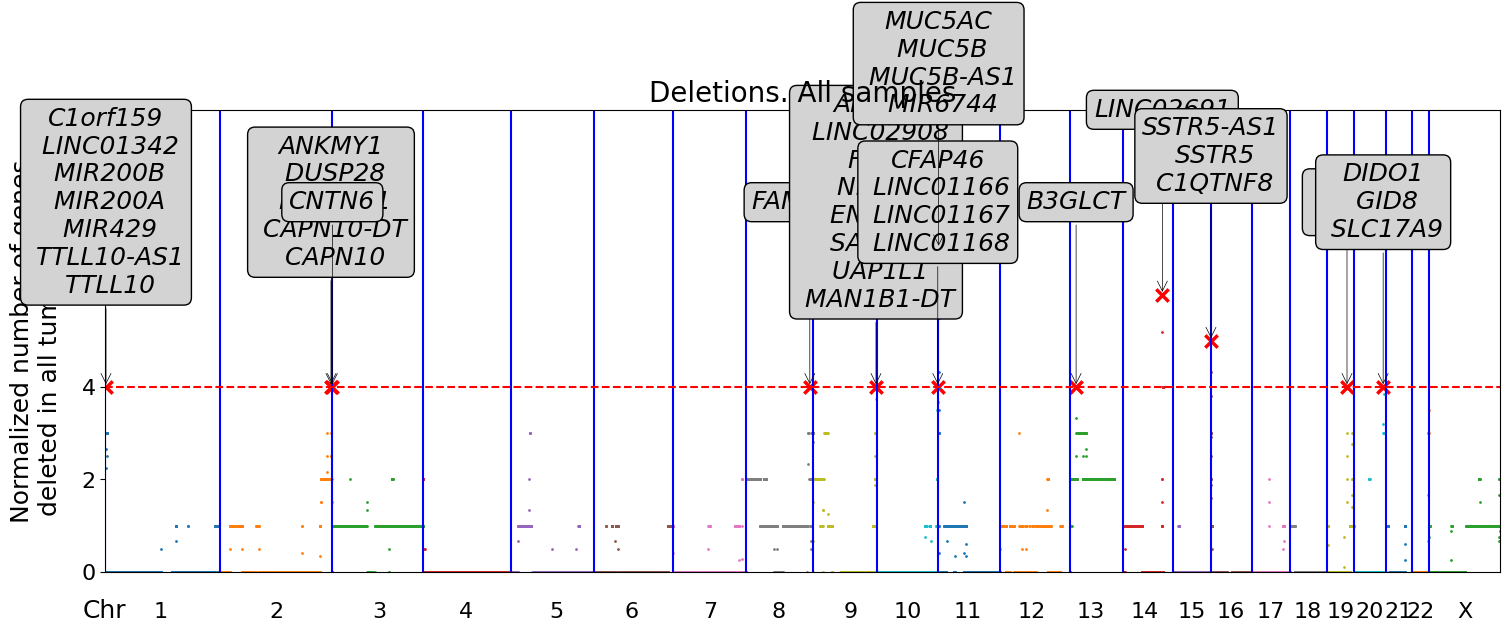

In [14]:
plt.style.use('default')

plt.figure(figsize=(18, 6))

peaks_list = []
broader_peaks_list = []

for chrom in chrom_order:
    res_df_filtered_chrom = res_df_filtered[res_df_filtered.chr == chrom]
    plt.scatter(res_df_filtered_chrom.bin_coordinate_adjusted, res_df_filtered_chrom.deletions_per_gene, s=1)

    plt.text(res_df_filtered_chrom.bin_coordinate_adjusted.mean(), -1, chrom[3:], fontsize = 16, ha='center', color = 'black')
    plt.axvline(res_df_filtered_chrom.bin_coordinate_adjusted.min(), c='b')
    peaks = find_peaks(res_df_filtered_chrom.deletions_per_gene, distance=25, height=4)
    
    plt.scatter(res_df_filtered_chrom.reset_index().loc[peaks[0]].bin_coordinate_adjusted, 
                res_df_filtered_chrom.reset_index().loc[peaks[0]].deletions_per_gene, 
                marker='x', c='r', s=80, linewidths=2.5)
    
    peaks_list.append(res_df_filtered_chrom.reset_index().loc[peaks[0]])
    
    for i, p in enumerate(peaks[0]):
        # индексы окна
        idxs = list(range(p-1, p+2))  # half_window=1 -> 3 точек
        # срезаем по границам, чтобы не уйти в -1 или за конец
        idxs = [j for j in idxs if 0 <= j < len(res_df_filtered_chrom)]

        tmp = res_df_filtered_chrom.reset_index().loc[idxs].copy()
        tmp['peak_group'] = f"{chrom}_{i}"   # уникальная группа (можно просто i, но так безопаснее)
        broader_peaks_list.append(tmp)    
        
plt.xlim(0, cur_max)
plt.ylim(0, 10)

peaks_df = pd.concat(peaks_list)
broader_peaks_df = pd.concat(broader_peaks_list)
broader_peaks_df = broader_peaks_df[broader_peaks_df.deletions_per_gene >= 4]

# Define aggregation rules
agg_dict = {
    'bin_genes': 'sum',
    'deletions': 'sum',
    'genes_number': 'sum'
}

# For all other columns, determine aggregation based on data type
for col in broader_peaks_df.columns:
    if col not in ['peak_group', 'bin_genes', 'deletions_per_gene', 'genes_number', 'deletions']:
        # If column is numeric, use mean
        if pd.api.types.is_numeric_dtype(broader_peaks_df[col]):
            agg_dict[col] = 'mean'
        # If column is string or non-numeric, use first
        else:
            agg_dict[col] = 'first'
    
    # Group by peak_group and apply the aggregation
broader_peaks_df = broader_peaks_df.groupby('peak_group').agg(agg_dict).reset_index()
broader_peaks_df['bin_genes_str'] = broader_peaks_df.bin_genes.apply(lambda x: ', '.join(x))    
broader_peaks_df['deletions_per_gene'] = broader_peaks_df['deletions']/broader_peaks_df['genes_number']

for _,row in peaks_df.iterrows():
    plt.annotate(
        row['bin_genes_str'].replace(',', '\n'), 
        xy=(row['bin_coordinate_adjusted'], row['deletions_per_gene']),
        xytext=(row['bin_coordinate_adjusted'], row['deletions_per_gene'] + 4),
        arrowprops=dict(arrowstyle='->', color='black', lw=0.5),
        bbox=dict(boxstyle='round', pad=0.3, fc='#D3D3D3', ec='black', lw=1),
        fontsize=18,
        fontstyle='italic',
        ha='center', va='center'
    )

plt.title('Deletions. All samples', fontsize = 20)
plt.ylabel('Normalized number of genes\n deleted in all tumor samples', fontsize = 18)

plt.xticks([], [])
plt.yticks(fontsize=16)
plt.text(-50000000, -1, 'Chr', fontsize = 18)
plt.axhline(4, c='r', linestyle = '--')	
plt.savefig('./paper_figures/deletions_dotplot.svg')

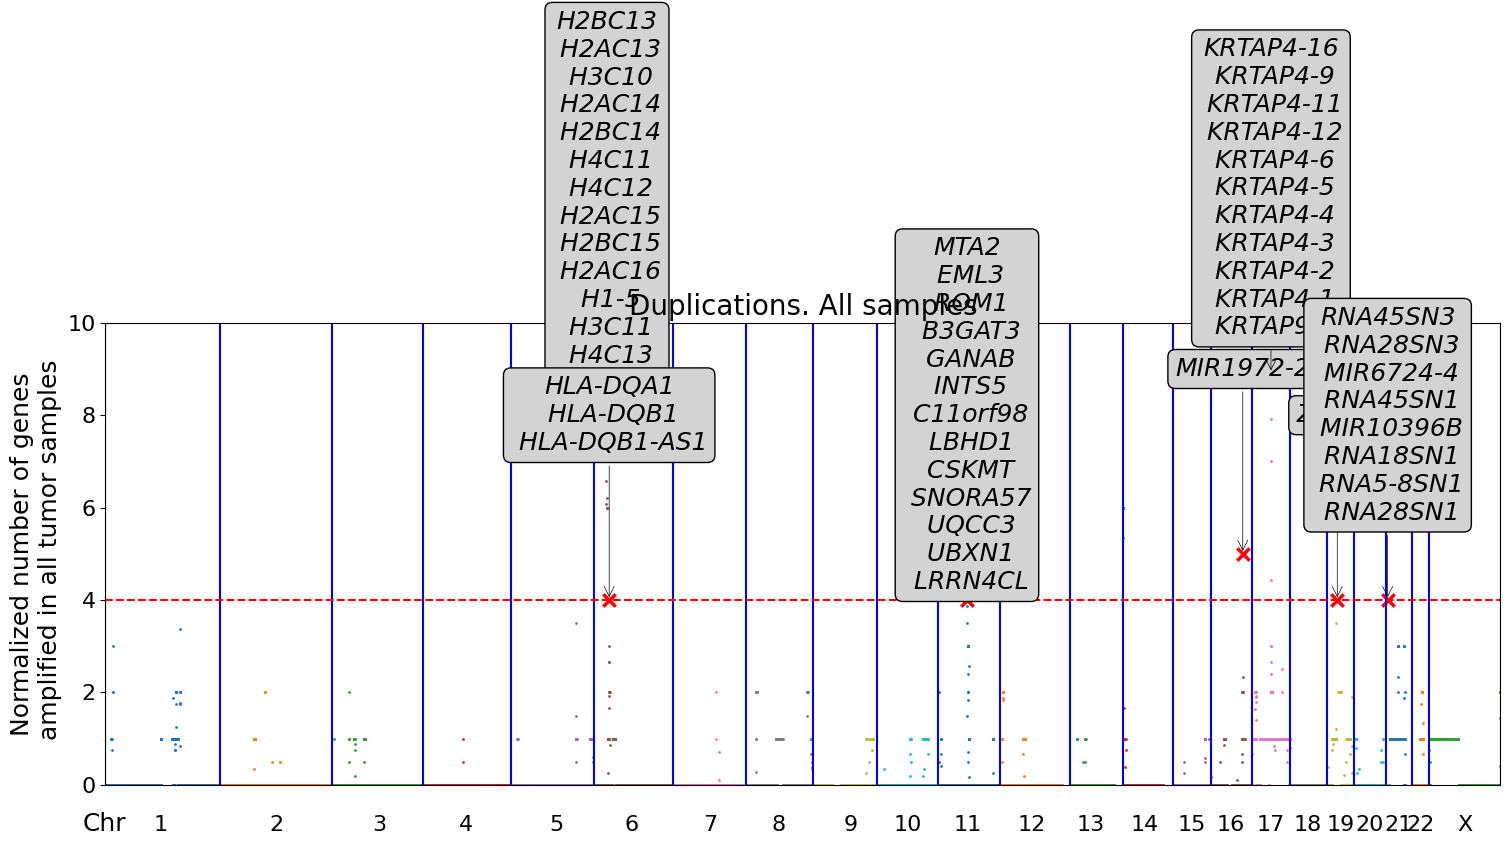

In [16]:
plt.style.use('default')

plt.figure(figsize=(18, 6))

peaks_list = []
broader_peaks_list = []

for chrom in chrom_order:
    res_df_filtered_chrom = res_df_filtered[res_df_filtered.chr == chrom]
    plt.scatter(res_df_filtered_chrom.bin_coordinate_adjusted, res_df_filtered_chrom.duplications_per_gene, s=1)

    plt.text(res_df_filtered_chrom.bin_coordinate_adjusted.mean(), -1, chrom[3:], fontsize = 16, ha='center', color = 'black')
    plt.axvline(res_df_filtered_chrom.bin_coordinate_adjusted.min(), c='b')
    peaks = find_peaks(res_df_filtered_chrom.duplications_per_gene, distance=25, height=4)
    
    plt.scatter(res_df_filtered_chrom.reset_index().loc[peaks[0]].bin_coordinate_adjusted, 
                res_df_filtered_chrom.reset_index().loc[peaks[0]].duplications_per_gene, 
                marker='x', c='r', s=80, linewidths=2.5)
    peaks_list.append(res_df_filtered_chrom.reset_index().loc[peaks[0]])
    
    for i, p in enumerate(peaks[0]):
        # индексы окна
        idxs = list(range(p-1, p+2))  # half_window=1 -> 3 точек
        # срезаем по границам, чтобы не уйти в -1 или за конец
        idxs = [j for j in idxs if 0 <= j < len(res_df_filtered_chrom)]

        tmp = res_df_filtered_chrom.reset_index().loc[idxs].copy()
        tmp['peak_group'] = f"{chrom}_{i}"   # уникальная группа (можно просто i, но так безопаснее)
        broader_peaks_list.append(tmp)    
        
plt.xlim(0, cur_max)
plt.ylim(0, 10)

peaks_df = pd.concat(peaks_list)
broader_peaks_df = pd.concat(broader_peaks_list)
broader_peaks_df = broader_peaks_df[broader_peaks_df.duplications_per_gene >= 4]

# Define aggregation rules
agg_dict = {
    'bin_genes': 'sum',
    'duplications': 'sum',
    'genes_number': 'sum'
}

# For all other columns, determine aggregation based on data type
for col in broader_peaks_df.columns:
    if col not in ['peak_group', 'bin_genes', 'duplications_per_gene', 'genes_number', 'duplications']:
        # If column is numeric, use mean
        if pd.api.types.is_numeric_dtype(broader_peaks_df[col]):
            agg_dict[col] = 'mean'
        # If column is string or non-numeric, use first
        else:
            agg_dict[col] = 'first'
    
    # Group by peak_group and apply the aggregation
broader_peaks_df = broader_peaks_df.groupby('peak_group').agg(agg_dict).reset_index()
broader_peaks_df['bin_genes_str'] = broader_peaks_df.bin_genes.apply(lambda x: ', '.join(x))    
broader_peaks_df['duplications_per_gene'] = broader_peaks_df['duplications']/broader_peaks_df['genes_number']

for _,row in peaks_df.iterrows():
    plt.annotate(
        row['bin_genes_str'].replace(',', '\n'), 
        xy=(row['bin_coordinate_adjusted'], row['duplications_per_gene']),
        xytext=(row['bin_coordinate_adjusted'], row['duplications_per_gene'] + 4),
        arrowprops=dict(arrowstyle='->', color='black', lw=0.5),
        bbox=dict(boxstyle='round', pad=0.3, fc='#D3D3D3', ec='black', lw=1),
        fontsize=18,
        fontstyle='italic',
        ha='center', va='center'
    )

plt.title('Duplications. All samples', fontsize = 20)
plt.ylabel('Normalized number of genes\n amplified in all tumor samples', fontsize = 18)

plt.xticks([], [])
plt.yticks(fontsize=16)
plt.text(-50000000, -1, 'Chr', fontsize = 18)
plt.axhline(4, c='r', linestyle = '--')	
plt.savefig('./paper_figures/duplications_dotplot.svg')

# 7. TERT deletion and expression analysis

In [4]:
segments_all = []

for file in os.listdir('../CNV/CNV_data'):
    if ('FGF_8' not in file) and ('.igv.seg' in file):
        print(file)
        seg_file = pd.read_csv(f'../CNV/CNV_data/{file}', sep = '\t')
        seg_file = seg_file[seg_file.Call.apply(lambda x: x in {'-', '+'})]
        seg_file = seg_file[seg_file.Segment_Mean.apply(lambda x: abs(x) > 0.3)]
        seg_file['sample_id'] = '_'.join(file.split('_')[1:3])
        segments_all.append(seg_file)

W_FGF_3_2_S165.called.igv.seg
W_FGF_4_S149.called.igv.seg
W_FGF_15_S150.called.igv.seg
W_FGF_1_S151.called.igv.seg
W_FGF_16_S126.called.igv.seg
W_FGF_7_S132.called.igv.seg
W_FGF_10_S137.called.igv.seg
W_FGF_12_S136.called.igv.seg
W_FGF_6_S123.called.igv.seg
W_FGF_13_S147.called.igv.seg


In [5]:
segments_df = pd.concat(segments_all).reset_index().drop('index', axis=1)
segments_df

,Sample,Chromosome,Start,End,Num_Probes,Call,Segment_Mean,sample_id
0,W_FGF_3_2_S165,chr1,16758800,16764507,6,+,2.191852,FGF_3
1,W_FGF_3_2_S165,chr1,145907350,146020243,35,+,1.109097,FGF_3
2,W_FGF_3_2_S165,chr1,149783951,149887960,8,+,2.129761,FGF_3
3,W_FGF_3_2_S165,chr1,149900027,150559923,170,+,0.371541,FGF_3
4,W_FGF_3_2_S165,chr1,150560039,150629502,8,+,2.029651,FGF_3
...,...,...,...,...,...,...,...,...
424,W_FGF_13_S147,chr6,33194666,33425910,135,+,0.426866,FGF_13
425,W_FGF_13_S147,chr7,149784796,149829026,79,-,-0.621672,FGF_13
426,W_FGF_13_S147,chr8,22354265,23681670,171,+,0.301914,FGF_13
427,W_FGF_13_S147,chr8,132836511,134509774,87,+,0.373701,FGF_13


In [6]:
chrom_sizes = pd.read_csv('./genome.chrom.sizes', sep='\t', header=None)
chrom_sizes

,0,1
0,1,248956422
1,10,133797422
2,11,135086622
3,12,133275309
4,13,114364328
...,...,...
189,KI270539.1,993
190,KI270385.1,990
191,KI270423.1,981
192,KI270392.1,971


In [7]:
telomere_proximity_statuses = []

for _, segment in segments_df.iterrows():
    
    cur_chrom_size = chrom_sizes[chrom_sizes[0] == segment.Chromosome[3:]][1].values[0]
    telomeric_status = 'non_telomeric'
    if segment.End <= cur_chrom_size*0.05:
        telomeric_status = 'telomeric_left'
    elif segment.Start >= cur_chrom_size*0.95:
        telomeric_status = 'telomeric_right'
    telomere_proximity_statuses.append(telomeric_status)

In [8]:
segments_df['telomere'] = telomere_proximity_statuses
segments_df_telomeric_deletions = segments_df[(segments_df.Call == '-') & (segments_df.telomere.apply(lambda x: 'telomeric_right' in x or 'telomeric_left' in x))]
segments_df_telomeric_deletions

,Sample,Chromosome,Start,End,Num_Probes,Call,Segment_Mean,sample_id,telomere
13,W_FGF_3_2_S165,chr11,1003704,1459275,214,-,-0.402388,FGF_3,telomeric_left
66,W_FGF_3_2_S165,chr20,64029375,64273650,52,-,-0.304752,FGF_3,telomeric_right
70,W_FGF_3_2_S165,chr22,50601782,50744223,42,-,-0.465557,FGF_3,telomeric_right
71,W_FGF_3_2_S165,chr3,319763,3105003,78,-,-0.409865,FGF_3,telomeric_left
109,W_FGF_3_2_S165,chr9,137818040,138219449,48,-,-0.382820,FGF_3,telomeric_right
...,...,...,...,...,...,...,...,...,...
407,W_FGF_13_S147,chr14,104085752,104604769,38,-,-0.742350,FGF_13,telomeric_right
408,W_FGF_13_S147,chr16,762664,1448783,214,-,-0.562440,FGF_13,telomeric_left
409,W_FGF_13_S147,chr16,2173171,2196445,32,-,-0.647086,FGF_13,telomeric_left
419,W_FGF_13_S147,chr20,62307352,63590769,326,-,-0.399061,FGF_13,telomeric_right


In [9]:
print(f'Number of peritelomeric deletions before deduplication: {segments_df_telomeric_deletions.shape[0]}')
segments_df_telomeric_deletions = segments_df_telomeric_deletions.drop_duplicates(subset = ['sample_id', 'telomere', 'Chromosome'])
print(f'Number of peritelomeric deletions after deduplication: {segments_df_telomeric_deletions.shape[0]}')

Number of peritelomeric deletions before deduplication: 80
Number of peritelomeric deletions after deduplication: 65


In [10]:
telomeric_deletion_counts = segments_df_telomeric_deletions.sample_id.value_counts()
telomeric_deletion_counts

sample_id
FGF_15    13
FGF_16    13
FGF_7     12
FGF_12    10
FGF_13     7
FGF_3      5
FGF_4      2
FGF_10     2
FGF_6      1
Name: count, dtype: int64

In [11]:
telomeric_deletion_counts['FGF_1'] = 0

In [12]:
tert_samples = ['FGF_2', 'FGF_12']

In [14]:
telomeric_deletion_counts = pd.DataFrame(telomeric_deletion_counts)

telomeric_deletion_counts['annotation'] = telomeric_deletion_counts.index.map(lambda x:  '+' if x in tert_samples else '-')

,count,annotation
sample_id,,
FGF_15,13,-
FGF_16,13,-
FGF_7,12,-
FGF_12,10,+
FGF_13,7,-
FGF_3,5,-
FGF_4,2,-
FGF_10,2,-
FGF_6,1,-


In [17]:
new_sample_rename = pd.read_excel('~/Downloads/Oncobox/FGF23/sample_rename.xlsx', sheet_name='new_samples')

rename_dict = {}
rename_dict.update(
    new_sample_rename.set_index("Sample_name")["Paper_name"].to_dict()
)

telomeric_deletion_counts['Paper_name'] = telomeric_deletion_counts.index.map(rename_dict)
telomeric_deletion_counts

,count,annotation,Paper_name
sample_id,,,
FGF_15,13,-,batchB_10
FGF_16,13,-,batchB_11
FGF_7,12,-,batchB_6
FGF_12,10,+,batchB_8
FGF_13,7,-,batchB_9
FGF_3,5,-,batchB_3
FGF_4,2,-,batchB_4
FGF_10,2,-,batchB_7
FGF_6,1,-,batchB_5


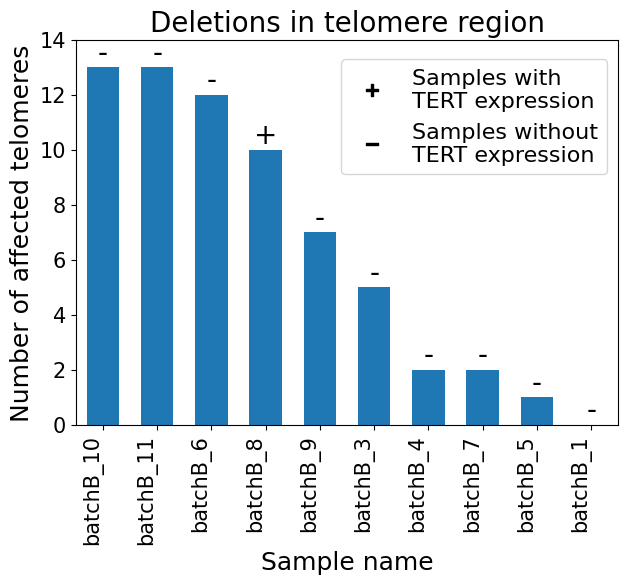

In [34]:
trimmed_telomeres_counts_df = telomeric_deletion_counts.copy()

plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 15})

trimmed_telomeres_counts_df.color = 'tab:blue'

bars = plt.bar(x=trimmed_telomeres_counts_df.Paper_name, 
               height=trimmed_telomeres_counts_df['count'], 
               color=trimmed_telomeres_counts_df.color,
               width=0.6)

trimmed_telomeres_counts_df.reset_index(inplace=True)

i = 0
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             trimmed_telomeres_counts_df.loc[i]['annotation'], 
             ha='center', va='bottom', fontsize=20)
    i += 1

plt.xlim(-0.5, 9.5)
plt.ylim(0, 14)

plt.xticks(rotation=90, ha='right')

plt.xlabel('Sample name', fontsize=18)
plt.ylabel('Number of affected telomeres', fontsize=18)
plt.title('Deletions in telomere region', fontsize=20)

# Update legend to reflect the changes
handles = [
    plt.Line2D([0],[0], marker='$+$', linestyle='', markersize=8,
               color='black', label='Samples with\nTERT expression'),
    plt.Line2D([0],[0], marker='$-$', linestyle='', markersize=8,
               color='black', label='Samples without\nTERT expression')
]
plt.legend(handles=handles, frameon=True, loc='center right',
    fontsize=16, bbox_to_anchor=(1, 0.80))

plt.savefig('./paper_figures/FGF23_telomeric_deletions.svg')

# 8. Mutation analysis

In [11]:
import csv
import gzip
import sys

def parse_info(info_str):
    """Parse INFO string into dict."""
    return dict(kv.split('=', 1) for kv in info_str.split(';') if '=' in kv)

def main(csv_file, vcf_file, output_file):
    # Step 1: Read the VCF file and collect mutations with AF
    mutations = {}
    with gzip.open(vcf_file, 'rt') as vcf:
        for line in vcf:
            if line.startswith('#'):
                continue
            fields = line.strip().split('\t')
            if len(fields) < 8:
                continue
            chrom = fields[0]
            pos = fields[1]
            ref = fields[3]
            alts = fields[4].split(',')
            info = parse_info(fields[7])
            afs = info.get('AF', '').split(',')
            for i, alt in enumerate(alts):
                af = afs[i] if i < len(afs) else '0.0'
                key = (chrom, pos, ref, alt)
                mutations[key] = af

    # Step 2: Read the CSV file, add RuSeq_AF column, and write to output
    with open(csv_file, 'r') as csv_in, open(output_file, 'w', newline='') as csv_out:
        reader = csv.DictReader(csv_in)
        fieldnames = reader.fieldnames + ['RuSeq_AF']
        writer = csv.DictWriter(csv_out, fieldnames=fieldnames)
        writer.writeheader()
        
        for row in reader:
            chrom = row.get('CHROM')
            pos = row.get('POS')
            ref = row.get('REF')
            alt = row.get('ALT')
            if chrom and pos and ref and alt:
                key = (chrom, pos, ref, alt)
                row['RuSeq_AF'] = mutations.get(key, 'NA')
            else:
                row['RuSeq_AF'] = 'NA'  # If missing columns, set to NA
            writer.writerow(row)

In [101]:
main('../mutations/somatic_variant_sample_df_no_ExAC_filter.csv', '/home/olga/Downloads/Oncobox/ACTH/ruseq.sites.v1.1.vcf.gz', '../mutations/somatic_variant_ruseq_AF.csv')

In [12]:
somatic = pd.read_csv('../mutations/somatic_variant_ruseq_AF.csv', index_col=0)
ref_df = pd.read_csv('~/Downloads/Oncobox/ACTH/enc_germinal_variants_v1_746patients_ac_an.csv', sep=',', quotechar='"', comment='#', index_col=0)

In [13]:
ref_df['ENC_AF'] = ref_df['AC'] / ref_df['AN']
ref_df

,AC,n_ind,N_ind,AN,ENC_AF
variant,,,,,
chr1:1000018:G:A,2,2,764,1528,0.001309
chr1:100006981:G:GAACA,1,1,764,1528,0.000654
chr1:100007048:A:G,52,48,764,1528,0.034031
chr1:1000079:A:G,302,156,764,1528,0.197644
chr1:1000112:G:T,185,93,764,1528,0.121073
...,...,...,...,...,...
chrY:9545440:G:A,2,1,76,152,0.013158
chrY:9546254:A:G,2,1,76,152,0.013158
chrY:9546264:A:G,2,1,76,152,0.013158


In [14]:
import re

def normalize_variant(variant_str):
    """chr1:1000018:G:A -> chr1:1000018_G>A"""
    variant_str = variant_str.strip('"')
    variant_str = re.sub(r':(\d+):([A-Z]):([A-ZGACTN]+)', r':\1_\2>\3', variant_str)
    return variant_str

ref_df.index = ref_df.index.map(normalize_variant)
ref_variants = set(ref_df.index)

somatic['ENC_AF'] = somatic['Variant_Identifier'].apply(
    lambda x: ref_df.loc[x, 'ENC_AF'] if x in ref_variants else 0.0
)
somatic

,Variant_Identifier,CHROM,POS,ID,REF,ALT,QUAL,FILTER,Chr,Start,...,W_FGF_3_2_S165,W_FGF_1_S151,W_FGF_12_S136,W_FGF_10_S137,W_FGF_16_S126,W_FGF_8_S134,W_FGF_15_S150,W_FGF_13_S147,RuSeq_AF,ENC_AF
0,chr10:100496342_G>C,chr10,100496342,.,G,C,.,PASS,chr10,100496342,...,-,-,-,-,-,-,-,-,NaN,0.000000
1,chr10:100945413_G>T,chr10,100945413,.,G,T,.,PASS,chr10,100945413,...,-,-,-,-,-,-,-,+,0.000714,0.000000
2,chr10:102067006_A>G,chr10,102067006,.,A,G,.,PASS,chr10,102067006,...,-,-,-,-,-,-,+,-,NaN,0.000000
3,chr10:102133109_C>T,chr10,102133109,.,C,T,.,PASS,chr10,102133109,...,-,-,-,-,-,-,-,-,NaN,0.000000
4,chr10:102369310_C>T,chr10,102369310,.,C,T,.,PASS,chr10,102369310,...,-,-,-,-,-,-,-,-,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3552,chrX:96884407_G>A,chrX,96884407,.,G,A,.,PASS,chrX,96884407,...,-,-,-,-,-,-,-,-,0.229372,0.066099
3553,chrX:96884662_C>T,chrX,96884662,.,C,T,.,PASS,chrX,96884662,...,+,-,-,-,-,-,-,-,NaN,0.000000
3554,chrY:12773782_C>T,chrY,12773782,.,C,T,.,PASS,chrY,12773782,...,+,-,-,-,-,-,-,-,NaN,0.000000
3555,chrY:13366285_G>A,chrY,13366285,.,G,A,.,PASS,chrY,13366285,...,-,-,-,-,-,-,-,-,NaN,0.000000


In [15]:
sample_columns = ['W_FGF_1_S151',
                  'W_FGF_3_2_S165',
                  'W_FGF_4_S149',
                  'W_FGF_6_S123',
                  'W_FGF_7_S132',
                  'W_FGF_8_S134', 
                  'W_FGF_10_S137', 
                  'W_FGF_12_S136',
                  'W_FGF_13_S147',
                  'W_FGF_15_S150',
                  'W_FGF_16_S126'
                    ]

col_rename = {i:'_'.join(i.split('_')[:3]) for i in sample_columns}
somatic = somatic.rename(columns=col_rename)

In [16]:
col_rename.values()

dict_values(['W_FGF_1', 'W_FGF_3', 'W_FGF_4', 'W_FGF_6', 'W_FGF_7', 'W_FGF_8', 'W_FGF_10', 'W_FGF_12', 'W_FGF_13', 'W_FGF_15', 'W_FGF_16'])

In [17]:
columns_to_group = [col for col in col_rename.values() if col != 'W_FGF_8']

In [18]:
somatic = somatic[~((somatic['W_FGF_8'] == '+') & (somatic[columns_to_group] == '-').all(axis=1))]
somatic.drop(columns = ['W_FGF_8'], inplace=True)
somatic['ExAC_ALL'] = somatic['ExAC_ALL'].replace('.', '0.00').astype(float)
somatic = somatic[somatic['ExAC_ALL'] < 0.01]
somatic['RuSeq_AF'] = somatic['RuSeq_AF'].fillna(0)
somatic = somatic[somatic['RuSeq_AF'] < 0.01]
somatic = somatic[somatic['ENC_AF'] < 0.01]

In [9]:
mutation_counts = pd.DataFrame({
    'Sample': columns_to_group,
    'Mutation_Count': [somatic[col].eq('+').sum() for col in columns_to_group]
})

In [10]:
mutation_counts.sort_values(by='Mutation_Count', ascending=False).to_csv('../mutations/mutations_stat.csv', index=False)

In [253]:
somatic.columns.to_list()
#somatic_df['CLNREVSTAT'].value_counts()
#somatic_df['ExonicFunc.refGene'].value_counts()

['Variant_Identifier',
 'CHROM',
 'POS',
 'ID',
 'REF',
 'ALT',
 'QUAL',
 'FILTER',
 'Chr',
 'Start',
 'End',
 'Ref',
 'Alt',
 'Func.refGene',
 'Gene.refGene',
 'GeneDetail.refGene',
 'ExonicFunc.refGene',
 'AAChange.refGene',
 'CLNALLELEID',
 'CLNDN',
 'CLNDISDB',
 'CLNREVSTAT',
 'CLNSIG',
 'SIFT_pred',
 'SIFT4G_pred',
 'LRT_pred',
 'MutationTaster_pred',
 'MutationAssessor_pred',
 'FATHMM_pred',
 'PROVEAN_pred',
 'MetaSVM_pred',
 'MetaLR_pred',
 'MetaRNN_pred',
 'M-CAP_pred',
 'PrimateAI_pred',
 'DEOGEN2_pred',
 'BayesDel_addAF_pred',
 'BayesDel_noAF_pred',
 'ClinPred_pred',
 'LIST-S2_pred',
 'Aloft_pred',
 'fathmm-MKL_coding_pred',
 'fathmm-XF_coding_pred',
 'Sample',
 'ExAC_ALL',
 'avsnp150',
 'W_FGF_6',
 'W_FGF_7',
 'W_FGF_4',
 'W_FGF_3',
 'W_FGF_1',
 'W_FGF_12',
 'W_FGF_10',
 'W_FGF_16',
 'W_FGF_15',
 'W_FGF_13',
 'RuSeq_AF']

In [41]:
genes_of_interest = 'FN1,KL,FGF23,SLC30A3,SYT1,STX1A,SNAP25,PHEX,ERBB4,PCDH7,LRRFIP2,FGFR1'.split(',') # KL, FN not in index
somatic.set_index('Gene.refGene', inplace=True)
somatic.loc['ERBB4'] #there is only ERBB4

,Variant_Identifier,CHROM,POS,ID,REF,ALT,QUAL,FILTER,Chr,Start,...,W_FGF_1,W_FGF_12,W_FGF_10,W_FGF_16,W_FGF_15,W_FGF_13,RuSeq_AF,ENC_AF,bad_prediction_count,bad_prediction_count_stopgain
Gene.refGene,,,,,,,,,,,,,,,,,,,,,
ERBB4,chr2:211387098_A>C,chr2,211387098,.,A,C,.,PASS,chr2,211387098,...,+,-,-,-,-,-,0.0,0.0,3,0
ERBB4,chr2:211722531_A>G,chr2,211722531,.,A,G,.,PASS,chr2,211722531,...,-,-,-,-,-,-,0.0,0.0,18,0


In [159]:
somatic[somatic['ExonicFunc.refGene'] == 'frameshift insertion']['AAChange.refGene'].to_list()

['OR4E1:NM_001317107:exon1:c.587_588insAC:p.H197Pfs*14',
 'KRTAP1-3:NM_030966:exon1:c.68_69insAAGCTGCCAAGCTGCTGTGAGACCAG:p.S23Rfs*89',
 'RHBG:NM_020407:exon9:c.1265dupC:p.D425Rfs*18,RHBG:NM_001256395:exon10:c.1058dupC:p.D356Rfs*18,RHBG:NM_001256396:exon10:c.1175dupC:p.D395Rfs*18',
 'PPP1R15B:NM_032833:exon1:c.30dupA:p.R11Tfs*25',
 'OR2T27:NM_001001824:exon1:c.847_848insTC:p.P283Lfs*33',
 'CNGA1:NM_001142564:exon7:c.359_360insAAAAAAAAACA:p.N120Kfs*78,CNGA1:NM_000087:exon8:c.359_360insAAAAAAAAACA:p.N120Kfs*78,CNGA1:NM_001379270:exon8:c.359_360insAAAAAAAAACA:p.N120Kfs*78',
 'FOXO3:NM_001455:exon2:c.1141dupG:p.L382Afs*3,FOXO3:NM_201559:exon3:c.1141dupG:p.L382Afs*3',
 'ZAN:NM_003386:exon31:c.5768_5769insTT:p.R1924Ffs*18,ZAN:NM_173059:exon31:c.5768_5769insTT:p.R1924Ffs*18',
 'MAD1L1:NM_001304524:exon13:c.1225_1226insCCAGGTGTGTCCTGCAGGGGAGGAGGCGGATACGC:p.L409Pfs*15,MAD1L1:NM_001304523:exon14:c.1501_1502insCCAGGTGTGTCCTGCAGGGGAGGAGGCGGATACGC:p.L501Pfs*15,MAD1L1:NM_001013836:exon15:c.1501_1502i

In [160]:
stopgain = somatic[somatic['ExonicFunc.refGene'] == 'stopgain']
predictor_columns = [
        "SIFT_pred", "SIFT4G_pred", "LRT_pred", "MutationTaster_pred",
        "MutationAssessor_pred", "FATHMM_pred", "PROVEAN_pred", "MetaSVM_pred",
        "MetaLR_pred", "MetaRNN_pred", "M-CAP_pred", "PrimateAI_pred",
        "DEOGEN2_pred", "BayesDel_addAF_pred", "BayesDel_noAF_pred",
        "ClinPred_pred", "LIST-S2_pred", "Aloft_pred", "fathmm-MKL_coding_pred",
        "fathmm-XF_coding_pred"
    ]

for pred in predictor_columns:
    print(stopgain[pred].value_counts())

.    64
Name: SIFT_pred, dtype: int64
.    64
Name: SIFT4G_pred, dtype: int64
.    26
D    21
N    14
U     3
Name: LRT_pred, dtype: int64
A    30
.    18
D    16
Name: MutationTaster_pred, dtype: int64
.    64
Name: MutationAssessor_pred, dtype: int64
.    64
Name: FATHMM_pred, dtype: int64
.    64
Name: PROVEAN_pred, dtype: int64
.    64
Name: MetaSVM_pred, dtype: int64
.    64
Name: MetaLR_pred, dtype: int64
.    64
Name: MetaRNN_pred, dtype: int64
.    64
Name: M-CAP_pred, dtype: int64
.    64
Name: PrimateAI_pred, dtype: int64
.    64
Name: DEOGEN2_pred, dtype: int64
D    43
.    17
T     4
Name: BayesDel_addAF_pred, dtype: int64
D    43
.    17
T     4
Name: BayesDel_noAF_pred, dtype: int64
.    61
D     2
T     1
Name: ClinPred_pred, dtype: int64
.    64
Name: LIST-S2_pred, dtype: int64
Recessive;                                                15
.;.;                                                       6
.                                                          6
.;          

In [5]:
len(predictor_columns)

20

/home/olga/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  import sys


<AxesSubplot:>

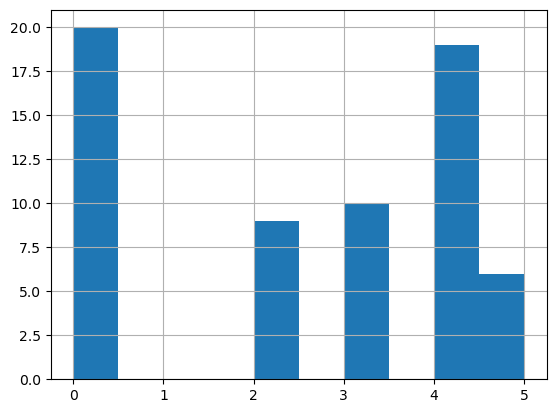

In [161]:
stopgain_pred = ['LRT_pred','MutationTaster_pred','BayesDel_addAF_pred',
                 'BayesDel_noAF_pred','fathmm-MKL_coding_pred','fathmm-XF_coding_pred']
bad_values = {"D", "M", "H"}

stopgain["bad_prediction_count_stopgain"] = stopgain[stopgain_pred].apply(
        lambda row: sum(val in bad_values for val in row if pd.notnull(val)),
        axis=1
    )

stopgain.bad_prediction_count_stopgain.hist()

In [162]:
frameshift_del = somatic[somatic['ExonicFunc.refGene'] == 'frameshift deletion']
predictor_columns = [
        "SIFT_pred", "SIFT4G_pred", "LRT_pred", "MutationTaster_pred",
        "MutationAssessor_pred", "FATHMM_pred", "PROVEAN_pred", "MetaSVM_pred",
        "MetaLR_pred", "MetaRNN_pred", "M-CAP_pred", "PrimateAI_pred",
        "DEOGEN2_pred", "BayesDel_addAF_pred", "BayesDel_noAF_pred",
        "ClinPred_pred", "LIST-S2_pred", "Aloft_pred", "fathmm-MKL_coding_pred",
        "fathmm-XF_coding_pred"
    ]

for pred in predictor_columns:
    print(frameshift_del[pred].value_counts())

.    34
Name: SIFT_pred, dtype: int64
.    34
Name: SIFT4G_pred, dtype: int64
.    34
Name: LRT_pred, dtype: int64
.    34
Name: MutationTaster_pred, dtype: int64
.    34
Name: MutationAssessor_pred, dtype: int64
.    34
Name: FATHMM_pred, dtype: int64
.    34
Name: PROVEAN_pred, dtype: int64
.    34
Name: MetaSVM_pred, dtype: int64
.    34
Name: MetaLR_pred, dtype: int64
.    34
Name: MetaRNN_pred, dtype: int64
.    34
Name: M-CAP_pred, dtype: int64
.    34
Name: PrimateAI_pred, dtype: int64
.    34
Name: DEOGEN2_pred, dtype: int64
.    34
Name: BayesDel_addAF_pred, dtype: int64
.    34
Name: BayesDel_noAF_pred, dtype: int64
.    34
Name: ClinPred_pred, dtype: int64
.    34
Name: LIST-S2_pred, dtype: int64
.    34
Name: Aloft_pred, dtype: int64
.    34
Name: fathmm-MKL_coding_pred, dtype: int64
.    34
Name: fathmm-XF_coding_pred, dtype: int64


In [163]:
frameshift_ins = somatic[somatic['ExonicFunc.refGene'] == 'frameshift insertion']
predictor_columns = [
        "SIFT_pred", "SIFT4G_pred", "LRT_pred", "MutationTaster_pred",
        "MutationAssessor_pred", "FATHMM_pred", "PROVEAN_pred", "MetaSVM_pred",
        "MetaLR_pred", "MetaRNN_pred", "M-CAP_pred", "PrimateAI_pred",
        "DEOGEN2_pred", "BayesDel_addAF_pred", "BayesDel_noAF_pred",
        "ClinPred_pred", "LIST-S2_pred", "Aloft_pred", "fathmm-MKL_coding_pred",
        "fathmm-XF_coding_pred"
    ]

for pred in predictor_columns:
    print(frameshift_ins[pred].value_counts())

.    9
Name: SIFT_pred, dtype: int64
.    9
Name: SIFT4G_pred, dtype: int64
.    9
Name: LRT_pred, dtype: int64
.    9
Name: MutationTaster_pred, dtype: int64
.    9
Name: MutationAssessor_pred, dtype: int64
.    9
Name: FATHMM_pred, dtype: int64
.    9
Name: PROVEAN_pred, dtype: int64
.    9
Name: MetaSVM_pred, dtype: int64
.    9
Name: MetaLR_pred, dtype: int64
.    9
Name: MetaRNN_pred, dtype: int64
.    9
Name: M-CAP_pred, dtype: int64
.    9
Name: PrimateAI_pred, dtype: int64
.    9
Name: DEOGEN2_pred, dtype: int64
.    9
Name: BayesDel_addAF_pred, dtype: int64
.    9
Name: BayesDel_noAF_pred, dtype: int64
.    9
Name: ClinPred_pred, dtype: int64
.    9
Name: LIST-S2_pred, dtype: int64
.    9
Name: Aloft_pred, dtype: int64
.    9
Name: fathmm-MKL_coding_pred, dtype: int64
.    9
Name: fathmm-XF_coding_pred, dtype: int64


In [19]:
def acceptable_clnsig(x):
    """
    Returns True if the CLNSIG field (which may be semicolon-separated)
    contains only allowed values ("Pathogenic" and/or "Likely_pathogenic").
    Otherwise, returns False.
    """
    try:
        tokens = [token.strip() for token in str(x).split("/")]
        tokens_add = [token.strip() for token in str(x).split("|")]
    except Exception:
        return False
    allowed_tokens = {"Pathogenic", "Likely_pathogenic"}
    # Return True if every token is in allowed_tokens and there is at least one allowed token.
    return any(token in allowed_tokens for token in tokens) or any(token in allowed_tokens for token in tokens_add)


def filter_variants_clinvar(df):
    predictor_columns = [
        "SIFT_pred", "SIFT4G_pred", "LRT_pred", "MutationTaster_pred",
        "MutationAssessor_pred", "FATHMM_pred", "PROVEAN_pred", "MetaSVM_pred",
        "MetaLR_pred", "MetaRNN_pred", "M-CAP_pred", "PrimateAI_pred",
        "DEOGEN2_pred", "BayesDel_addAF_pred", "BayesDel_noAF_pred",
        "ClinPred_pred", "LIST-S2_pred", "Aloft_pred", "fathmm-MKL_coding_pred",
        "fathmm-XF_coding_pred"
    ]

    # Define the set of bad prediction values
    bad_values = {"D", "M", "H"}

    # Count how many predictors for each variant have a bad value.
    # This creates a new column 'bad_prediction_count'.
    df["bad_prediction_count"] = df[predictor_columns].apply(
        lambda row: sum(val in bad_values for val in row if pd.notnull(val)),
        axis=1
    )

    # For stopgain creates a new column 'bad_prediction_count_stopgain'
    stopgain_pred = ['LRT_pred','MutationTaster_pred','BayesDel_addAF_pred',
                 'BayesDel_noAF_pred','fathmm-MKL_coding_pred','fathmm-XF_coding_pred']

    stopgain = []
    for _,row in df.iterrows():
        s = 0
        if row['ExonicFunc.refGene'] == 'stopgain':
            for col in stopgain_pred:
                s += row[col] in bad_values
        stopgain.append(s)
            
    df['bad_prediction_count_stopgain'] = stopgain

    clnvar = (df["CLNSIG"].str.contains(r"[Pp]athogenic")&
    ((df['CLNREVSTAT'] == 'criteria_provided\\x2c_multiple_submitters\\x2c_no_conflicts')|
    (df['CLNREVSTAT'] == 'reviewed_by_expert_panel')))

    filtered_df = df[clnvar].copy()
    return filtered_df

def filter_variants(df, threshold=3):
    # List of predictor columns in the final dataframe
    predictor_columns = [
        "SIFT_pred", "SIFT4G_pred", "LRT_pred", "MutationTaster_pred",
        "MutationAssessor_pred", "FATHMM_pred", "PROVEAN_pred", "MetaSVM_pred",
        "MetaLR_pred", "MetaRNN_pred", "M-CAP_pred", "PrimateAI_pred",
        "DEOGEN2_pred", "BayesDel_addAF_pred", "BayesDel_noAF_pred",
        "ClinPred_pred", "LIST-S2_pred", "Aloft_pred", "fathmm-MKL_coding_pred",
        "fathmm-XF_coding_pred"
    ]

    # Define the set of bad prediction values
    bad_values = {"D", "M", "H"}

    # Count how many predictors for each variant have a bad value.
    # This creates a new column 'bad_prediction_count'.
    df["bad_prediction_count"] = df[predictor_columns].apply(
        lambda row: sum(val in bad_values for val in row if pd.notnull(val)),
        axis=1
    )

    # For stopgain creates a new column 'bad_prediction_count_stopgain'
    stopgain_pred = ['LRT_pred','MutationTaster_pred','BayesDel_addAF_pred',
                 'BayesDel_noAF_pred','fathmm-MKL_coding_pred','fathmm-XF_coding_pred']

    stopgain = []
    for _,row in df.iterrows():
        s = 0
        if row['ExonicFunc.refGene'] == 'stopgain':
            for col in stopgain_pred:
                s += row[col] in bad_values
        stopgain.append(s)
            
    df['bad_prediction_count_stopgain'] = stopgain

    # Combine conditions:
    # Retain variants that either have a bad prediction count >= threshold
    # OR have a CLNSIG value that is exclusively Pathogenic/Likely_pathogenic.
    final_condition = (df["bad_prediction_count"] >= threshold) | \
    (df["bad_prediction_count_stopgain"] >= 4) | \
    (df['ExonicFunc.refGene'] == 'frameshift deletion') | \
    (df['ExonicFunc.refGene'] == 'frameshift insertion')

    # Apply the filter
    filtered_df = df[final_condition].copy()
    return filtered_df

def table_preparation(filtered_variants_somatic_ExAC):
    df_counts = pd.DataFrame()
    df_counts[columns_to_group] = filtered_variants_somatic_ExAC[columns_to_group]
    df_counts['Gene.refGene'] = filtered_variants_somatic_ExAC['Gene.refGene']
    df_counts['Variant_Identifier'] = filtered_variants_somatic_ExAC['Variant_Identifier']
    df_counts['AAChange.refGene'] = filtered_variants_somatic_ExAC['AAChange.refGene']
    df_counts['CLNSIG'] = filtered_variants_somatic_ExAC['CLNSIG']
    df_counts['ExAC_ALL'] = filtered_variants_somatic_ExAC['ExAC_ALL']
    df_counts['RuSeq_AF'] = filtered_variants_somatic_ExAC['RuSeq_AF']
    df_counts['ENC_AF'] = filtered_variants_somatic_ExAC['ENC_AF']
#    df_counts['Gnomad_wes_4_AF'] = filtered_variants_somatic_ExAC['Gnomad_wes_4_AF']
#    df_counts['Gnomad_wgs_3_AF'] = filtered_variants_somatic_ExAC['Gnomad_wgs_3_AF']
#    df_counts['rsID'] = filtered_variants_somatic_ExAC['rsID']
    df_counts['ExonicFunc.refGene'] = filtered_variants_somatic_ExAC['ExonicFunc.refGene']
    df_counts['CLNREVSTAT'] = filtered_variants_somatic_ExAC['CLNREVSTAT']
    df_counts['Number_samples'] = filtered_variants_somatic_ExAC[columns_to_group].sum(axis=1)
    df_counts['Samples'] = filtered_variants_somatic_ExAC['Samples']
    
    return df_counts

In [27]:
clinvar_variants = filter_variants_clinvar(somatic)

In [28]:
clinvar_variants.set_index('Gene.refGene', inplace=True)

In [29]:
clinvar_variants[columns_to_group] = clinvar_variants[columns_to_group].apply(lambda x: (x == '+').astype(int))
clinvar_variants['Samples'] = clinvar_variants[columns_to_group].apply(
        lambda row: ', '.join(clinvar_variants[columns_to_group].columns[row == 1]), 
        axis=1
    )

In [43]:
res = res.drop(columns=['chr', 'start', 'end'])
res_reindexed = res.reindex(clinvar_variants.index, fill_value=0)
res_reindexed = res_reindexed.astype(int)
intersection = res_reindexed[columns_to_group] & clinvar_variants[columns_to_group]
intersection

,W_FGF_1,W_FGF_3,W_FGF_4,W_FGF_6,W_FGF_7,W_FGF_10,W_FGF_12,W_FGF_13,W_FGF_15,W_FGF_16
Gene.refGene,,,,,,,,,,
FLCN,0,0,0,0,0,0,0,0,0,0
CYP4V2,0,0,0,0,0,0,0,0,0,0


In [44]:
clinvar_variants['Samples_LOH'] = intersection.apply(lambda row: ','.join(row[row == 1].index), axis=1)
clinvar_variants

,Variant_Identifier,CHROM,POS,ID,REF,ALT,QUAL,FILTER,Chr,Start,...,W_FGF_10,W_FGF_16,W_FGF_15,W_FGF_13,RuSeq_AF,ENC_AF,bad_prediction_count,bad_prediction_count_stopgain,Samples,Samples_LOH
Gene.refGene,,,,,,,,,,,,,,,,,,,,,
FLCN,chr17:17224068_TGAA>T,chr17,17224068,.,TGAA,T,.,PASS,chr17,17224069,...,0,0,1,0,0.0,0.0,0,0,W_FGF_15,
CYP4V2,chr4:186198976_C>T,chr4,186198976,.,C,T,.,PASS,chr4,186198976,...,0,0,0,0,0.0,0.0,4,4,W_FGF_3,


In [30]:
clinvar_variants[['Variant_Identifier', 'bad_prediction_count', 'ExonicFunc.refGene', 'ExAC_ALL', 'RuSeq_AF', 'ENC_AF', 'CLNSIG']]

,Variant_Identifier,bad_prediction_count,ExonicFunc.refGene,ExAC_ALL,RuSeq_AF,ENC_AF,CLNSIG
Gene.refGene,,,,,,,
FLCN,chr17:17224068_TGAA>T,0,nonframeshift deletion,0.000000,0.0,0.0,Pathogenic/Likely_pathogenic
CYP4V2,chr4:186198976_C>T,4,stopgain,0.000033,0.0,0.0,Pathogenic


In [414]:
clinvar_variants.to_csv("Clinvar_variants.tsv", sep="\t")

In [43]:
filtered_variants_somatic = filter_variants(somatic,threshold=0)

In [44]:
filtered_variants_somatic[filtered_variants_somatic['Gene.refGene']=='FLCN']['AAChange.refGene'].to_list()

['FLCN:NM_144606:exon6:c.469_471del:p.F157del,FLCN:NM_144997:exon6:c.469_471del:p.F157del,FLCN:NM_001353230:exon7:c.469_471del:p.F157del,FLCN:NM_001353231:exon7:c.469_471del:p.F157del,FLCN:NM_001353229:exon8:c.523_525del:p.F175del']

In [45]:
filtered_variants_somatic[columns_to_group] = filtered_variants_somatic[columns_to_group].apply(lambda x: (x == '+').astype(int))
filtered_variants_somatic['Samples'] = filtered_variants_somatic[columns_to_group].apply(
        lambda row: ', '.join(filtered_variants_somatic[columns_to_group].columns[row == 1]), 
        axis=1)

In [46]:
filtered_variants_somatic.reset_index(inplace=True)

In [23]:
filtered_variants_somatic.to_csv('somatic_mutation_after_filtration.tsv', sep='\t', index=False)

In [47]:
df_counts = table_preparation(filtered_variants_somatic)

In [48]:
df_counts[df_counts['Gene.refGene'] == 'FLCN']['AAChange.refGene'].to_list()

['FLCN:NM_144606:exon6:c.469_471del:p.F157del,FLCN:NM_144997:exon6:c.469_471del:p.F157del,FLCN:NM_001353230:exon7:c.469_471del:p.F157del,FLCN:NM_001353231:exon7:c.469_471del:p.F157del,FLCN:NM_001353229:exon8:c.523_525del:p.F175del']

In [49]:
agg_dict = {'Samples': ', '.join,
            'CLNSIG': ', '.join,
            'Variant_Identifier': ', '.join,
            'ExonicFunc.refGene': ', '.join, 
            'ExAC_ALL': lambda x: ','.join(x.astype(str)),
            'RuSeq_AF': lambda x: ','.join(x.astype(str)),
            'ENC_AF': lambda x: ','.join(x.astype(str)),
#            'Gnomad_wes_4_AF': lambda x: ','.join(x.astype(str)),
#            'Gnomad_wgs_3_AF': lambda x: ','.join(x.astype(str)),
            'Number_samples': 'sum'
           }

for col in columns_to_group:
    agg_dict[col] = 'sum'

mutation_counts = df_counts.groupby(['Gene.refGene']).agg(agg_dict)

In [50]:
mutation_counts[mutation_counts[columns_to_group].eq(2).any(axis=1)]

,Samples,CLNSIG,Variant_Identifier,ExonicFunc.refGene,ExAC_ALL,RuSeq_AF,ENC_AF,Number_samples,W_FGF_1,W_FGF_3,W_FGF_4,W_FGF_6,W_FGF_7,W_FGF_10,W_FGF_12,W_FGF_13,W_FGF_15,W_FGF_16
Gene.refGene,,,,,,,,,,,,,,,,,,
AHNAK2,"W_FGF_4, W_FGF_4, W_FGF_10, W_FGF_10, W_FGF_13...","., ., ., ., ., .","chr14:104941770_G>T, chr14:104945922_GG>CC, ch...","nonsynonymous SNV, nonframeshift substitution,...","0.008,0.0,0.0,0.006,0.0,0.0006","0.0001006441223832,0.0,0.0,0.0,0.0,0.009961762...","0.0,0.0,0.0,0.0,0.0,0.0",10,0,0,2,1,0,2,1,1,1,2
ANKRD36,"W_FGF_3, W_FGF_7, W_FGF_4, W_FGF_6, W_FGF_1, W...","., ., ., ., .","chr2:97158108_A>C, chr2:97167717_C>T, chr2:971...","nonsynonymous SNV, nonsynonymous SNV, nonframe...","0.0005,0.0009,0.0,0.0023,0.0001","0.000819504199959,0.0002031694433157,0.0,0.001...","0.0,0.0,0.0,0.0,0.0",6,2,1,1,1,1,0,0,0,0,0
ASXL2,"W_FGF_3, W_FGF_3","., .","chr2:25878183_C>CCCAGGT, chr2:25878187_G>GGTCC...","nonframeshift insertion, nonframeshift insertion","0.0,0.0","0.0,0.0","0.0,0.0",2,0,2,0,0,0,0,0,0,0,0
ATP12A,"W_FGF_1, W_FGF_1","., .","chr13:24698688_G>A, chr13:24706425_C>A","nonsynonymous SNV, nonsynonymous SNV","0.0076,0.0075","0.0056281407035175,0.0056359195942137","0.0032722513089005235,0.0032722513089005235",2,2,0,0,0,0,0,0,0,0,0
BRF1,"W_FGF_1, W_FGF_1","., .","chr14:105211194_C>G, chr14:105226102_C>T","nonsynonymous SNV, nonsynonymous SNV","0.0,0.0","0.0,0.0002025111381125","0.0,0.0",2,2,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TSPYL1,"W_FGF_7, W_FGF_7","., .","chr6:116278803_C>G, chr6:116278806_A>G","nonsynonymous SNV, nonsynonymous SNV","0.0,0.0","0.0,0.0","0.0,0.0",2,0,0,0,0,2,0,0,0,0,0
TUBB8B,"W_FGF_3, W_FGF_4, W_FGF_12, W_FGF_16, W_FGF_4,...","., ., .","chr18:47650_G>A, chr18:47686_C>T, chr18:48398_...","nonsynonymous SNV, nonsynonymous SNV, nonframe...","0.0079,0.0011,0.0","0.0,0.0,0.0","0.0,0.0,0.0",8,0,2,2,0,0,0,2,0,0,2
WASHC2A,"W_FGF_4, W_FGF_10, W_FGF_10","., .","chr10:50095689_GT>AG, chr10:50110201_A>G","nonframeshift substitution, nonsynonymous SNV","0.0,0.0","0.0,0.0","0.0,0.0",3,0,0,1,0,0,2,0,0,0,0


In [51]:
mutation_counts['Samples_biallelic'] = mutation_counts[columns_to_group].apply(lambda row: ','.join(row[row > 1].index), axis=1)
mutation_counts[columns_to_group] = mutation_counts[columns_to_group].replace(2, 1)
mutation_counts['total_mutations'] = mutation_counts[columns_to_group].sum(axis=1)

In [61]:
res_reindexed = res.reindex(mutation_counts.index, fill_value=0)
res_reindexed = res_reindexed.astype(int)
intersection = res_reindexed[columns_to_group] & mutation_counts[columns_to_group].astype(int)
mutation_counts['Samples_LOH'] = intersection.apply(lambda row: ','.join(row[row == 1].index), axis=1)

In [62]:
mutation_counts[mutation_counts['total_mutations'] >= 2].sort_values('total_mutations', ascending=False)#.index.to_list()#loc['USP8', 'ExonicFunc.refGene']

,Samples,CLNSIG,Variant_Identifier,ExonicFunc.refGene,ExAC_ALL,RuSeq_AF,ENC_AF,Number_samples,W_FGF_1,W_FGF_3,...,W_FGF_6,W_FGF_7,W_FGF_10,W_FGF_12,W_FGF_13,W_FGF_15,W_FGF_16,Samples_biallelic,total_mutations,Samples_LOH
Gene.refGene,,,,,,,,,,,,,,,,,,,,,
MUC3A,"W_FGF_4, W_FGF_7, W_FGF_4, W_FGF_13, W_FGF_13,...","., ., ., ., ., ., ., ., ., .","chr7:100952147_CA>TG, chr7:100953281_G>A, chr7...","nonframeshift substitution, nonsynonymous SNV,...","0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0","0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0","0.0,0.0,0.0,0.0,0.007267441860465116,0.0,0.0,0...",16,0,0,...,1,3,3,1,3,0,0,"W_FGF_4,W_FGF_7,W_FGF_10,W_FGF_13",16,
MUC16,"W_FGF_3, W_FGF_13, W_FGF_3, W_FGF_13, W_FGF_7,...","., ., ., ., ., ., ., ., ., ., .","chr19:8895981_A>C, chr19:8895991_A>G, chr19:89...","nonsynonymous SNV, nonsynonymous SNV, nonframe...","0.0,0.0,0.0,0.0002,0.0,0.0063,0.0069,0.0,0.001...","0.0024306258861656,0.0024271844660194,0.0,0.0,...","0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0",17,0,5,...,1,1,0,0,3,0,5,"W_FGF_3,W_FGF_6,W_FGF_7,W_FGF_13,W_FGF_16",15,
"KIR2DL1,KIR2DL2,KIR2DL3,KIR2DS2,KIR2DS3,LOC102725023","W_FGF_15, W_FGF_1, W_FGF_3, W_FGF_10, W_FGF_1,...","., ., ., .","chr19:54739507_G>C, chr19:54739516_T>G, chr19:...","nonsynonymous SNV, nonsynonymous SNV, nonsynon...","0.0,0.0023,1.26e-05,3.587e-05","0.0,0.0,0.0,0.0","0.0,0.0,0.0,0.005788712011577424",14,3,3,...,0,0,3,1,1,3,0,"W_FGF_1,W_FGF_3,W_FGF_10,W_FGF_15",14,
LILRA2,"W_FGF_12, W_FGF_1, W_FGF_6, W_FGF_7, W_FGF_16,...","., ., ., ., .","chr19:54573885_C>T, chr19:54574088_G>A, chr19:...","nonsynonymous SNV, nonsynonymous SNV, nonsynon...","0.0,0.0,4.125e-05,0.0,0.0001","0.0,0.0,0.0,0.0,0.0","0.0,0.0,0.0,0.0,0.0",17,4,3,...,1,1,1,1,1,0,1,"W_FGF_1,W_FGF_3,W_FGF_4,W_FGF_12,W_FGF_16",14,"W_FGF_10,W_FGF_13"
FRG2C,"W_FGF_3, W_FGF_4, W_FGF_6, W_FGF_7, W_FGF_10, ...","., Benign, ., .","chr3:75664890_G>A, chr3:75665551_A>G, chr3:756...","nonsynonymous SNV, nonsynonymous SNV, nonsynon...","0.0,0.0,0.0,0.0","0.0,0.0,0.0,0.0","0.0,0.0,0.0,0.0",13,0,1,...,4,1,1,1,3,0,0,"W_FGF_4,W_FGF_6,W_FGF_13",12,W_FGF_10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WDR11,"W_FGF_1, W_FGF_3","., .","chr10:120862921_G>A, chr10:120889956_CAAAAATTA...","nonsynonymous SNV, frameshift deletion","0.0,0.0","0.0,0.0","0.0,0.0",2,1,1,...,0,0,0,0,0,0,0,,2,
ZNF638,"W_FGF_16, W_FGF_12","., .","chr2:71349067_G>T, chr2:71431402_A>C","nonsynonymous SNV, nonsynonymous SNV","0.0,0.0","0.0,0.0","0.0,0.0",2,0,0,...,0,0,0,1,0,0,1,,2,
ZNF560,"W_FGF_4, W_FGF_3","., .","chr19:9466866_C>T, chr19:9468123_C>T","nonsynonymous SNV, nonsynonymous SNV","0.0001,0.0004","0.0002019386106623,0.0007077856420626","0.0,0.0",2,0,1,...,0,0,0,0,0,0,0,,2,


In [57]:
', '.join(sorted(mutation_counts[(mutation_counts.Samples_LOH != '')&(mutation_counts.total_mutations >= 0)].sort_values('total_mutations', ascending=False).index.to_list()))

'ABCA6, ACADVL, ADAM7, ALDH6A1, ATP12A, ATP13A5, ATP2A3, CCR6, CLCN2, DIS3L2, IGSF11, IQCA1, LHFPL6, MYH1, MYH4, MYO16, N4BP2L2, NHLRC3, NID2, OPLAH, PAX3, PDS5B, PIK3C2G, PRKAG3, PYGL, SUB1, SUMF1, TTI2'

In [63]:
genes_important = ['FLCN', 'RBPJ', 'SIRPB1', 'UBE2N']

In [80]:
genes_nonsyn = mutation_counts.loc[mutation_counts.index.isin(genes_important)&(mutation_counts['total_mutations'] >= 2)&(mutation_counts['ExonicFunc.refGene'].str.contains('nonsynonymous SNV'))].sort_values('total_mutations', ascending=False).index.to_list()
genes_frameshift = mutation_counts.loc[mutation_counts.index.isin(genes_important)&(mutation_counts['total_mutations'] >= 1)&(mutation_counts['ExonicFunc.refGene'].str.contains('frameshift'))].sort_values('total_mutations', ascending=False).index.to_list()

In [81]:
genes = genes_nonsyn + genes_frameshift
genes = sorted(list(set(genes)))
genes

['FLCN', 'RBPJ', 'SIRPB1', 'UBE2N']

In [82]:
res_df_to_plot = mutation_counts[columns_to_group]
res_df_to_plot.reset_index(inplace=True)

In [83]:
res_df_to_plot = res_df_to_plot[res_df_to_plot['Gene.refGene'].isin(genes)]
res_df_to_plot.set_index('Gene.refGene', inplace=True)
res_df_to_plot

,W_FGF_1,W_FGF_3,W_FGF_4,W_FGF_6,W_FGF_7,W_FGF_10,W_FGF_12,W_FGF_13,W_FGF_15,W_FGF_16
Gene.refGene,,,,,,,,,,
FLCN,0,0,0,0,0,0,0,0,1,0
RBPJ,0,1,0,0,1,0,0,0,0,1
SIRPB1,1,1,1,0,0,0,0,0,0,0
UBE2N,0,1,1,0,0,0,0,0,0,0


In [84]:
res_df_to_plot[::-1]

,W_FGF_1,W_FGF_3,W_FGF_4,W_FGF_6,W_FGF_7,W_FGF_10,W_FGF_12,W_FGF_13,W_FGF_15,W_FGF_16
Gene.refGene,,,,,,,,,,
UBE2N,0,1,1,0,0,0,0,0,0,0
SIRPB1,1,1,1,0,0,0,0,0,0,0
RBPJ,0,1,0,0,1,0,0,0,0,1
FLCN,0,0,0,0,0,0,0,0,1,0


In [85]:
mut_types = df_counts[columns_to_group + ['Gene.refGene', 'ExonicFunc.refGene']]
mut_types_in = mut_types.set_index('Gene.refGene')['ExonicFunc.refGene']
mut_types.set_index('Gene.refGene', inplace=True)
mut_types_df = mut_types.apply(lambda col: mut_types_in[col == 1].groupby('Gene.refGene').first())

mut_types_df = mut_types_df.fillna('')

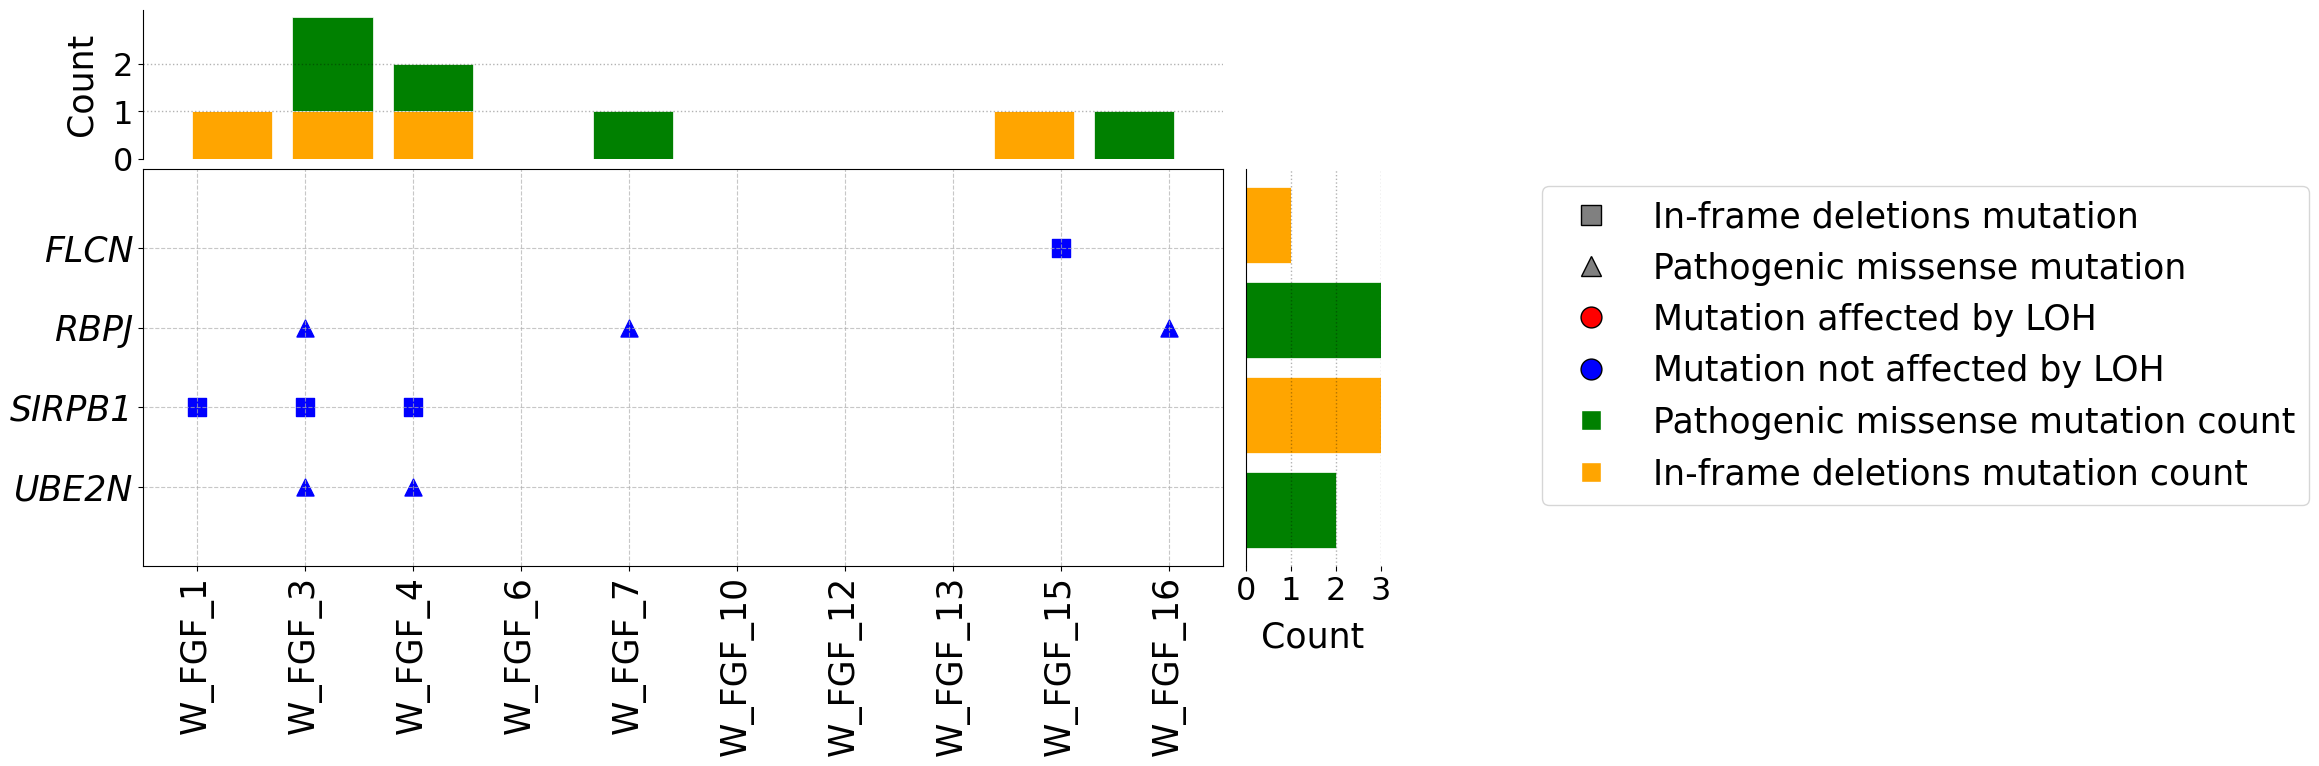

In [88]:
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patches as patches

plt.rcParams.update({
    'font.size': 20,           # Основной размер шрифта
    'axes.titlesize': 22,      # Заголовок графика
    'axes.labelsize': 21,      # Подписи осей (xlabel, ylabel)
    'xtick.labelsize': 20,     # Подписи тиков на оси X
    'ytick.labelsize': 20,     # Подписи тиков на оси Y
    'legend.fontsize': 19      # Текст легенды
})

#plt.style.use('default')

df_plot = res_df_to_plot[::-1]

mut_type_symbols = {
    'frameshift deletion': ('D', 's'),  # Квадрат
    'nonframeshift deletion': ('D', 's'),  # Квадрат
    'frameshift insertion': ('D', 's'), # Квадрат
    'nonsynonymous SNV': ('S', '^')     # Треугольник
}

fig = plt.figure(figsize=(18, 8))
gs = gridspec.GridSpec(3, 3, width_ratios=[4, 0.5, 0.5], height_ratios=[1.5, 4, 0.5], 
                      wspace=0.05, hspace=0.05)

# 2. main graph
ax_main = plt.subplot(gs[1, 0])

# Получаем границы оси
x_min, x_max = -0.5, len(df_plot.columns) - 0.5
y_min, y_max = -1, len(df_plot.index)
#y_min, y_max = ax_main.get_ylim()

# Отрисовываем точки
rows, cols = np.where(df_plot == 1)  # Индексы, где есть мутации
for row, col in zip(rows, cols):
    gene = df_plot.index[row]
    sample = df_plot.columns[col]
    mut_type = mut_types_df.loc[gene, sample]
    
    color = 'red' if sample in mutation_counts.loc[gene, 'Samples_LOH'] else 'blue'
    
    if isinstance(mut_type, str):
        _, marker = mut_type_symbols.get(mut_type, ('?', 'o'))
        ax_main.scatter(col, row, c=color, marker=marker, s=150)
    else:
        for mtype in mut_type:
            _, marker = mut_type_symbols.get(mtype, ('?', 'o'))
            ax_main.scatter(col, row, c=color, marker=marker, s=150, alpha=0.7)

# Настройки осей
ax_main.set_yticks(range(len(df_plot)))
ax_main.set_yticklabels(df_plot.index, fontstyle='italic', fontsize=25)
ax_main.set_xticks(range(len(df_plot.columns)))
ax_main.set_xticklabels(df_plot.columns, rotation=90, fontsize=25)
ax_main.grid(axis='both', linestyle='--', alpha=0.7)

ax_main.set_xlim(x_min, x_max)
ax_main.set_ylim(y_min, y_max)
            
# 1. Гистограмма по образцам (сверху)
ax_xhist = plt.subplot(gs[0, 0])

# Подсчет количества мутаций по образцам
sample_frameshift_counts = {sample: 0 for sample in df_plot.columns}
sample_other_counts = {sample: 0 for sample in df_plot.columns}

for gene, sample in zip(rows, cols):
    sample_name = df_plot.columns[sample]
    gene_name = df_plot.index[gene]
    mut_type = mut_types_df.loc[gene_name, sample_name]
    
    if isinstance(mut_type, str):
        mut_type = [mut_type]
    
    for mtype in mut_type:
        if 'frameshift' in mtype:
            sample_frameshift_counts[sample_name] += 1
        else:
            sample_other_counts[sample_name] += 1

# Создаем stacked bar plot
x_pos = range(len(df_plot.columns))
bars_frameshift = ax_xhist.bar(x_pos, [sample_frameshift_counts[g] for g in df_plot.columns], 
                             color='orange', edgecolor='white', linewidth=0.5)
bars_other = ax_xhist.bar(x_pos, [sample_other_counts[g] for g in df_plot.columns], 
                         bottom=[sample_frameshift_counts[g] for g in df_plot.columns],
                         color='green', edgecolor='white', linewidth=0.5)

# Добавляем разделительные линии для масштаба (каждые  мутации)
max_count = max(sample_other_counts.values())
for y in np.arange(1, max_count + 1, 1):
    ax_xhist.axhline(y, color='black', linestyle=':', alpha=0.3, linewidth=1)

# Настройки гистограммы образцов
ax_xhist.set_xticks([])
ax_xhist.set_yticks(np.arange(0, max_count + 1, 1))
ax_xhist.set_yticklabels(np.arange(0, max_count + 1, 1), fontsize=23)
ax_xhist.spines['top'].set_visible(False)
ax_xhist.spines['right'].set_visible(False)
ax_xhist.spines['bottom'].set_visible(False)
ax_xhist.set_ylabel('Count', fontsize=25, labelpad=10)

# 3. Гистограмма по генам (справа)
ax_yhist = plt.subplot(gs[1, 1])

# Подсчет мутаций по генам
gene_frameshift_counts = {gene: 0 for gene in df_plot.index}
gene_other_counts = {gene: 0 for gene in df_plot.index}

for gene, sample in zip(rows, cols):
    sample_name = df_plot.columns[sample]
    gene_name = df_plot.index[gene]
    mut_type = mut_types_df.loc[gene_name, sample_name]
    
    if isinstance(mut_type, str):
        mut_type = [mut_type]
    
    for mtype in mut_type:
        if 'frameshift' in mtype:
            gene_frameshift_counts[gene_name] += 1
        else:
            gene_other_counts[gene_name] += 1

# Создаем горизонтальную stacked bar plot
y_pos = range(len(df_plot.index))
ax_yhist.barh(y_pos, [gene_frameshift_counts[s] for s in df_plot.index], color='orange',
             edgecolor='white', linewidth=0.5)
ax_yhist.barh(y_pos, [gene_other_counts[s] for s in df_plot.index], 
              left=[gene_frameshift_counts[s] for s in df_plot.index],
              color='green', edgecolor='white', linewidth=0.5)

# Добавляем разделительные линии для масштаба (каждые  мутации)
max_count = max(gene_other_counts.values())
for y in np.arange(1, max_count + 1, 1):
    ax_yhist.axvline(y, color='black', linestyle=':', alpha=0.3, linewidth=1)

# Настройки гистограммы генов
ax_yhist.set_yticks([])
ax_yhist.set_xticks(np.arange(0, max_count + 1, 1))
ax_yhist.set_xticklabels(np.arange(0, max_count + 1, 1), fontsize=23)
ax_yhist.spines['top'].set_visible(False)
ax_yhist.spines['right'].set_visible(False)
ax_yhist.spines['bottom'].set_visible(False)
ax_yhist.set_xlabel('Count', fontsize=25, labelpad=10)

# 4. Легенда (справа)
ax_legend = plt.subplot(gs[1, 2])
ax_legend.axis('off')

legend_mut_types = [
    plt.Line2D([0], [0], marker='s', color='w', label='In-frame deletions mutation',
          markersize=15, markerfacecolor='gray', markeredgecolor='black'),
    plt.Line2D([0], [0], marker='^', color='w', label='Pathogenic missense mutation',
          markersize=15, markerfacecolor='gray', markeredgecolor='black'),
    plt.Line2D([0], [0], marker='o', color='w', label='Mutation affected by LOH',
          markersize=15, markerfacecolor='red', markeredgecolor='black'),
    plt.Line2D([0], [0], marker='o', color='w', label='Mutation not affected by LOH',
          markersize=15, markerfacecolor='blue', markeredgecolor='black'),
    plt.Line2D([0], [0], marker='s', color='w', label='Pathogenic missense mutation count',
              markersize=15, markerfacecolor='green', markeredgecolor='white'),
    plt.Line2D([0], [0], marker='s', color='w', label='In-frame deletions mutation count',
              markersize=15, markerfacecolor='orange', markeredgecolor='white')
]

ax_legend.legend(
    handles=legend_mut_types,
    title='',
    bbox_to_anchor=(0.9, 1),
    loc='upper left',
    fontsize=25
)

#plt.tight_layout()
plt.savefig('./paper_figures/mutation_dotplot.svg')

## 8a. Analysis of mutations with tumor.AF ~ 0.5 

In [13]:
fgf_3 = pd.read_csv('../mutations/spl_annofix_vep_FDA_RuSeq_W_FGF_3_2_S165_annotated.txt', sep='\t')

In [144]:
somatic_af = fgf_3.loc[fgf_3.FILTER == 'PASS']
somatic_af['W_FGF_3_2_S165.AF'] = somatic_af['W_FGF_3_2_S165.AF'].astype(float)
somatic_af.loc[somatic_af.POS == 93411143, 'W_FGF_3_2_S165.AF']

/tmp/ipykernel_79702/2501609654.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  somatic_af['W_FGF_3_2_S165.AF'] = somatic_af['W_FGF_3_2_S165.AF'].astype(float)


6778    0.076
Name: W_FGF_3_2_S165.AF, dtype: float64

<Axes: >

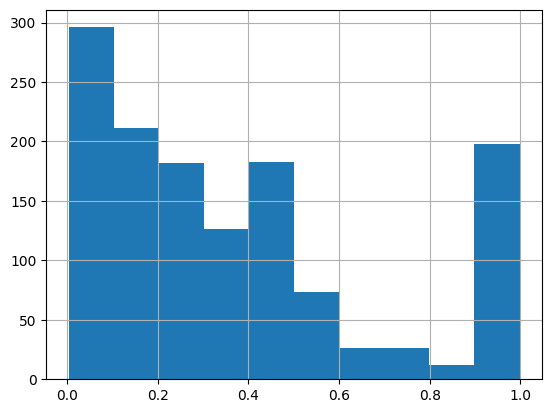

In [41]:
somatic_af['W_FGF_3_2_S165.AF'].hist()

In [90]:
fgf_10 = pd.read_csv('../mutations/spl_annofix_vep_FDA_RuSeq_W_FGF_10_S137_annotated.txt', sep='\t')

In [119]:
somatic_af = fgf_10.loc[fgf_10.FILTER == 'PASS']
somatic_af['ExAC_ALL'] = somatic_af['ExAC_ALL'].replace('.', '0.00').astype(float)
somatic_af['RuSeq.AF'].fillna(0, inplace=True)
somatic_af = somatic_af.loc[(somatic_af.ExAC_ALL < 0.01)&(somatic_af['RuSeq.AF'] < 0.01)]

somatic_af['W_FGF_10_S137.AF'] = somatic_af['W_FGF_10_S137.AF'].astype(float)
somatic_af.loc[somatic_af.POS == 196782706, ['W_FGF_10_S137.AF']]

/tmp/ipykernel_79702/2829001245.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  somatic_af['ExAC_ALL'] = somatic_af['ExAC_ALL'].replace('.', '0.00').astype(float)
/tmp/ipykernel_79702/2829001245.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  somatic_af['RuSeq.AF'].fillna(0, inpl

,W_FGF_10_S137.AF
19471,0.119


<Axes: >

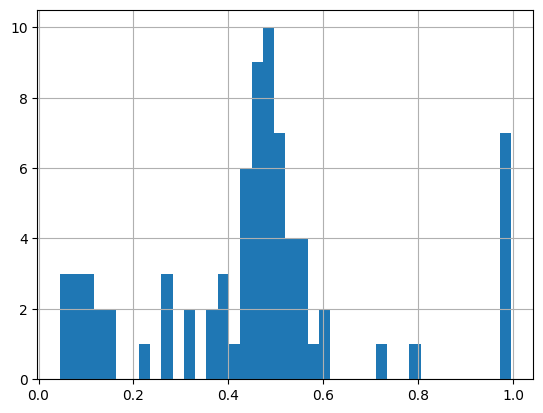

In [67]:
somatic_af['W_FGF_10_S137.AF'].hist(bins=40)

In [56]:
fgf_6 = pd.read_csv('../mutations/spl_annofix_vep_FDA_RuSeq_W_FGF_6_S123_annotated.txt', sep='\t')

In [145]:
somatic_af = fgf_6.loc[fgf_6.FILTER == 'PASS']
somatic_af['W_FGF_6_S123.AF'] = somatic_af['W_FGF_6_S123.AF'].astype(float)
somatic_af.loc[somatic_af.POS == 93411143, 'W_FGF_6_S123.AF']

/tmp/ipykernel_79702/1659465937.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  somatic_af['W_FGF_6_S123.AF'] = somatic_af['W_FGF_6_S123.AF'].astype(float)


Series([], Name: W_FGF_6_S123.AF, dtype: float64)

In [125]:
fgf_7 = pd.read_csv('../mutations/spl_annofix_vep_FDA_RuSeq_W_FGF_7_S132_annotated.txt', sep='\t')
somatic_af = fgf_7.loc[fgf_7.FILTER == 'PASS']
somatic_af['W_FGF_7_S132.AF'] = somatic_af['W_FGF_7_S132.AF'].astype(float)
somatic_af.loc[somatic_af.POS == 26424396, 'W_FGF_7_S132.AF']

/tmp/ipykernel_79702/889610598.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  somatic_af['W_FGF_7_S132.AF'] = somatic_af['W_FGF_7_S132.AF'].astype(float)


19200    0.046
Name: W_FGF_7_S132.AF, dtype: float64

In [62]:
fgf_13 = pd.read_csv('../mutations/spl_annofix_vep_FDA_RuSeq_W_FGF_13_S147_annotated.txt', sep='\t')
somatic_af = fgf_13.loc[fgf_13.FILTER == 'PASS']
somatic_af['ExAC_ALL'] = somatic_af['ExAC_ALL'].replace('.', '0.00').astype(float)
somatic_af['RuSeq.AF'].fillna(0, inplace=True)
somatic_af = somatic_af.loc[(somatic_af.ExAC_ALL < 0.01)&(somatic_af['RuSeq.AF'] < 0.01)]

somatic_af['W_FGF_13_S147.AF'] = somatic_af['W_FGF_13_S147.AF'].astype(float)
somatic_af.loc[somatic_af.POS == 33276005, 'W_FGF_13_S147.AF']

/tmp/ipykernel_31872/3334244879.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  somatic_af['ExAC_ALL'] = somatic_af['ExAC_ALL'].replace('.', '0.00').astype(float)
/tmp/ipykernel_31872/3334244879.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  somatic_af['RuSeq.AF'].fillna(0, inpl

22384    0.075
Name: W_FGF_13_S147.AF, dtype: float64

<Axes: >

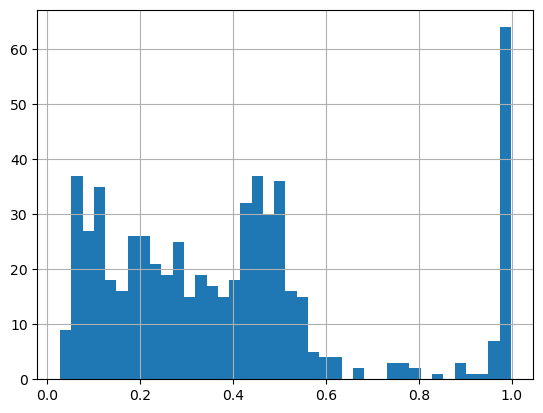

In [63]:
somatic_af['W_FGF_13_S147.AF'].hist(bins=40)

In [60]:
fgf_1 = pd.read_csv('../mutations/spl_annofix_vep_FDA_RuSeq_W_FGF_1_S151_annotated.txt', sep='\t')
somatic_af = fgf_1.loc[fgf_1.FILTER == 'PASS']
somatic_af['ExAC_ALL'] = somatic_af['ExAC_ALL'].replace('.', '0.00').astype(float)
somatic_af['RuSeq.AF'].fillna(0, inplace=True)
somatic_af = somatic_af.loc[(somatic_af.ExAC_ALL < 0.01)&(somatic_af['RuSeq.AF'] < 0.01)]

somatic_af['W_FGF_1_S151.AF'] = somatic_af['W_FGF_1_S151.AF'].astype(float)
somatic_af.loc[somatic_af.POS == 1578377, 'W_FGF_1_S151.AF']

/tmp/ipykernel_31872/3220480901.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  somatic_af['ExAC_ALL'] = somatic_af['ExAC_ALL'].replace('.', '0.00').astype(float)
/tmp/ipykernel_31872/3220480901.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  somatic_af['RuSeq.AF'].fillna(0, inpl

17161    0.124
Name: W_FGF_1_S151.AF, dtype: float64

<Axes: >

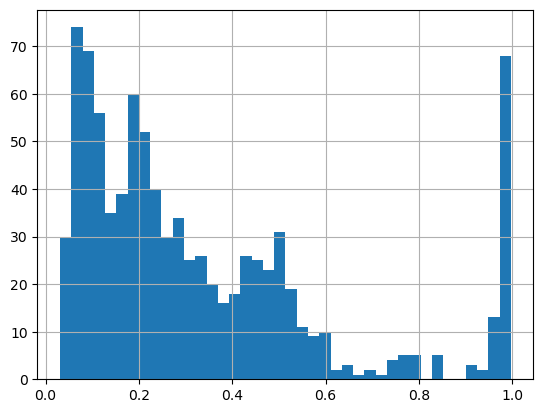

In [61]:
somatic_af['W_FGF_1_S151.AF'].hist(bins=40)

In [146]:
fgf_4 = pd.read_csv('../mutations/spl_annofix_vep_FDA_RuSeq_W_FGF_4_S149_annotated.txt', sep='\t')
somatic_af = fgf_4.loc[fgf_4.FILTER == 'PASS']
somatic_af['W_FGF_1_S151.AF'] = somatic_af['W_FGF_4_S149.AF'].astype(float)
somatic_af.loc[somatic_af.POS == 93411143, 'W_FGF_4_S149.AF']

/tmp/ipykernel_79702/3645108429.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  somatic_af['W_FGF_1_S151.AF'] = somatic_af['W_FGF_4_S149.AF'].astype(float)


6661    0.107
Name: W_FGF_4_S149.AF, dtype: object

In [120]:
fgf_12 = pd.read_csv('../mutations/spl_annofix_vep_FDA_RuSeq_W_FGF_12_S136_annotated.txt', sep='\t')
somatic_af = fgf_12.loc[fgf_12.FILTER == 'PASS']
somatic_af['W_FGF_12_S136.AF'] = somatic_af['W_FGF_12_S136.AF'].astype(float)
somatic_af.loc[somatic_af.POS == 196782706, 'W_FGF_12_S136.AF']

/tmp/ipykernel_79702/3988252594.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  somatic_af['W_FGF_12_S136.AF'] = somatic_af['W_FGF_12_S136.AF'].astype(float)


19002    0.074
Name: W_FGF_12_S136.AF, dtype: float64

In [133]:
fgf_15 = pd.read_csv('../mutations/spl_annofix_vep_FDA_RuSeq_W_FGF_15_S150_annotated.txt', sep='\t')
somatic_af = fgf_15.loc[fgf_15.FILTER == 'PASS']
somatic_af['W_FGF_15_S150.AF'] = somatic_af['W_FGF_15_S150.AF'].astype(float)
somatic_af.loc[somatic_af.POS == 33276005, 'W_FGF_15_S150.AF']

/tmp/ipykernel_79702/2588477979.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  somatic_af['W_FGF_15_S150.AF'] = somatic_af['W_FGF_15_S150.AF'].astype(float)


23284    0.143
Name: W_FGF_15_S150.AF, dtype: float64

In [3]:
fgf_16 = pd.read_csv('../mutations/spl_annofix_vep_FDA_RuSeq_W_FGF_16_S126_annotated.txt', sep='\t')
#somatic_af = fgf_16.loc[fgf_16.FILTER == 'PASS']
#somatic_af['W_FGF_16_S126.AF'] = somatic_af['W_FGF_16_S126.AF'].astype(float)
#somatic_af.loc[somatic_af.POS == 33276005, 'W_FGF_16_S126.AF']

In [19]:
cols = ['CHROM', 'POS', 'REF', 'ALT', 
        'Func.refGene', 'Gene.refGene', 'ExonicFunc.refGene',
 'AAChange.refGene', 'cosmic', 'avsnp150',
 'CLNALLELEID', 'CLNDN', 'CLNDISDB', 'CLNREVSTAT', 'CLNSIG',
 'RuSeq.AF', 'ExAC_ALL']

In [23]:
germline = fgf_16[fgf_16.FILTER == 'germline'][cols]
germline.to_csv('FGF16_germline.txt', sep='\t')

## 8b. Lollipop plots

In [90]:
# For FLCN gene

gene_features = pd.read_csv('NM_144997.gff3', sep='\t', skiprows=5, header=None)
gene_features[8] = gene_features[8].apply(lambda x: {pair.split('=')[0]: pair.split('=')[1] for pair in x.split(';')})

gene_features_regions = gene_features[gene_features[8].apply(lambda x: x['gbkey']) == 'Region']
gene_features_regions = gene_features_regions[gene_features_regions[8].apply(lambda x: 'Disordered' not in x['Name'])]

gene_features_regions['Note'] = gene_features_regions[8].apply(lambda x: x['Note'])
gene_features_regions['Name'] = gene_features_regions[8].apply(lambda x: x['Name'])

gene_features_regions.rename(columns = {3: 'start', 4: 'stop'}, inplace=True)
gene_features_regions.Name = gene_features_regions.Name.apply(lambda x: x.split('.')[0])
gene_features_regions['length'] = gene_features_regions.stop - gene_features_regions.start
gene_features_regions

,0,1,2,start,stop,5,6,7,8,Note,Name,length
5,NP_659434.2,RefSeq,biological_region,106,265,.,+,.,"{'ID': 'id-NP_659434.2:106..265', 'Dbxref': 'C...",Vesicle coat protein involved in Golgi to plas...,Folliculin,159
7,NP_659434.2,RefSeq,biological_region,210,220,.,+,.,"{'ID': 'id-NP_659434.2:210..220', 'Name': 'Ess...",propagated from UniProtKB/Swiss-Prot (Q8NFG4.1),Essential for interaction with LDHA,10
10,NP_659434.2,RefSeq,biological_region,344,566,.,+,.,"{'ID': 'id-NP_659434.2:344..566', 'Dbxref': 'C...",Folliculin C-terminal domain,Folliculin_C,222


In [91]:
import re

def extract_protein_change(input_string, transcript_id):
    """
    Extracts the protein position and amino acid change for a given transcript ID from a string of records.

    Parameters:
    input_string (str): The input string containing comma-separated records.
    transcript_id (str): The transcript ID to extract the information for.

    Returns:
    dict: A dictionary with keys 'position' (int), 'reference' (str), and 'alternative' (str) if found, else None.
    
    Raises:
    ValueError: If the protein change format is invalid.

    Example:
    input_string = "USP8:NM_001283049:exon11:c.1833_1835del:p.S613del,USP8:NM_001128610:exon14:c.2151_2153del:p.S719del"
    transcript_id = "NM_001128610"
    result = extract_protein_change(input_string, transcript_id)
    # result: {'position': 719, 'reference': 'S', 'alternative': '-'}
    """
    # Split input string into individual records and remove any whitespace
    records = [record.strip() for record in input_string.split(",")]
    
    # Iterate through records to find the one matching the transcript ID
    for record in records:
        parts = record.split(":")
        # Ensure record has at least 5 parts and the transcript ID matches the second part
        if len(parts) >= 5 and parts[1] == transcript_id:
            # Extract protein change from the last part
            protein_change = parts[-1]
            if not protein_change.startswith("p."):
                raise ValueError(f"Invalid protein change format: {protein_change}")
            
            # Remove "p." prefix
            change = protein_change[2:]
            
            # Parse the protein change using regex
            match = re.match(r"(\w)(\d+)(.*)", change)
            if match:
                reference = match.group(1)  # First letter (reference amino acid)
                position = int(match.group(2))  # Number (position)
                change_type = match.group(3)  # Remaining part (e.g., "del" or new amino acid)
                
                # Determine the alternative value based on change type
                alternative = change_type
                
                # Return dictionary with extracted information
                return {
                    "position": position,
                    "reference": reference,
                    "alternative": alternative
                }
            else:
                raise ValueError(f"Invalid protein change format: {change}")
    
    # Return None if transcript ID is not found
    return None

In [92]:
flcn_mutations = df_counts[df_counts['Gene.refGene'] == 'FLCN']
prot_id = 'NM_144997'
flcn_mutations['mutation_data'] = flcn_mutations['AAChange.refGene'].apply(lambda x: extract_protein_change(x, prot_id))
flcn_mutations['aa_mut_position'] = flcn_mutations.mutation_data.apply(lambda x: x['position'])
flcn_mutations['aa_reference'] = flcn_mutations.mutation_data.apply(lambda x: x['reference'])
flcn_mutations['aa_alternative'] = flcn_mutations.mutation_data.apply(lambda x: x['alternative'])
flcn_mutations

/tmp/ipykernel_15551/3159119118.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flcn_mutations['mutation_data'] = flcn_mutations['AAChange.refGene'].apply(lambda x: extract_protein_change(x, prot_id))
/tmp/ipykernel_15551/3159119118.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flcn_mutations['aa_mut_position'] = flcn_mutations.mutation_data.apply(lambda x: x['position'])
/tmp/ipykernel_15551/3159119118.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

,W_FGF_1,W_FGF_3,W_FGF_4,W_FGF_6,W_FGF_7,W_FGF_10,W_FGF_12,W_FGF_13,W_FGF_15,W_FGF_16,...,RuSeq_AF,ENC_AF,ExonicFunc.refGene,CLNREVSTAT,Number_samples,Samples,mutation_data,aa_mut_position,aa_reference,aa_alternative
441,0,0,0,0,0,0,0,0,1,0,...,0.0,0.0,nonframeshift deletion,criteria_provided\x2c_multiple_submitters\x2c_...,1,W_FGF_15,"{'position': 157, 'reference': 'F', 'alternati...",157,F,del


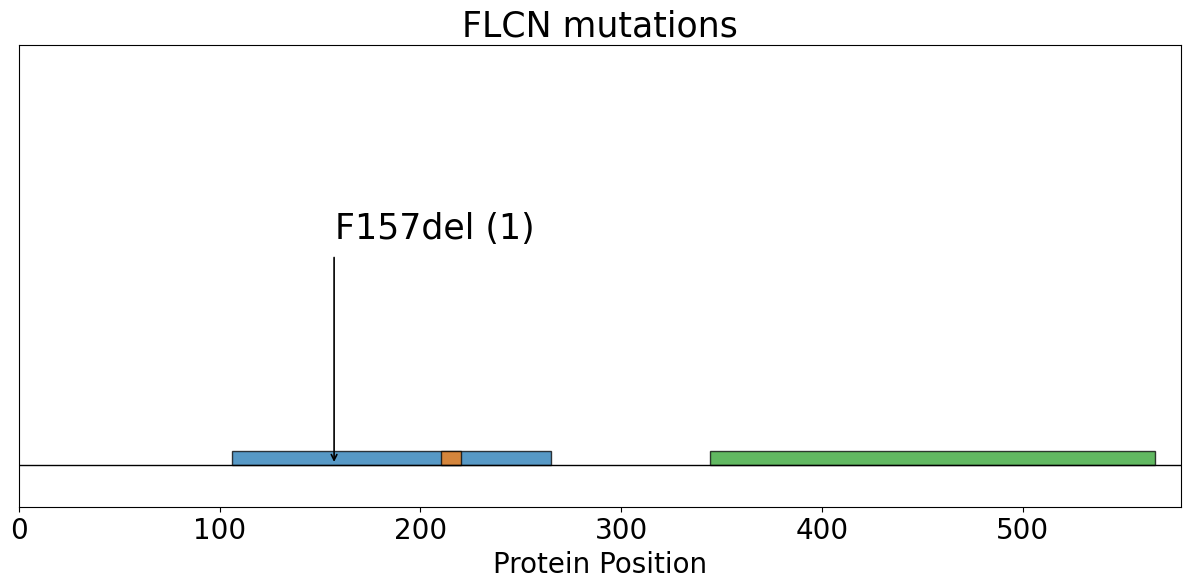

In [95]:
df = gene_features_regions
fig, ax = plt.subplots(figsize=(15, 6))

# Get the 'tab10' colormap for distinct colors
cmap = plt.get_cmap('tab10')
N = 10  # Number of colors in 'tab10'

# Plot each feature as a rectangle with a unique color
for i, (index, row) in enumerate(df.iterrows()):
    start = row['start']
    stop = row['stop']
    name = row['Name']
    color = cmap((i % N) / N)  # Assign color from colormap, cycling every 10 features
    rect = plt.Rectangle((start, 0), stop - start, 1, facecolor=color, edgecolor='black', alpha=0.75)
    ax.add_patch(rect)

# Set x-axis limits based on data
xmin = 0
xmax = 579
ax.set_xlim(xmin, xmax)

# Set y-axis limits to show rectangles and labels
ax.set_ylim(-3, 30)

# Remove y-axis ticks since all rectangles are on one line
ax.tick_params(axis='y',          # Apply to y-axis
               which='both',      # Apply to both major and minor ticks
               left=False,        # Hide left ticks
               right=False,       # Hide right ticks
               labelleft=False)  # Hide left tick labels

# Label x-axis
ax.set_xlabel('Protein Position', fontsize = 20)

# Add a horizontal line at y=0 to represent the sequence
ax.plot([xmin, xmax], [0, 0], color='black', linewidth=1)

# Add labels for each stem with mutation effect (refposalt)
texts = []
for i, row in flcn_mutations.iterrows():
    label = f"{row['aa_reference']}{row['aa_mut_position']}{row['aa_alternative']} ({row['Number_samples']})"
    # Стрелка от точки к тексту (смещение: 5 вверх, 10 вправо)
    texts.append(
        plt.text(row['aa_mut_position'] + 0.1, 15 + 0.3, label,
                 fontsize=25,ha='left', va='bottom'))
    # Стрелка
    ax.annotate('',
                 xy=(row['aa_mut_position'], 0), xytext=(row['aa_mut_position'], 15),
                 arrowprops=dict(arrowstyle='->', lw=1.2),
                 fontsize=10)

adjust_text(texts,
            x=flcn_mutations['aa_mut_position'], y=[15]*len(flcn_mutations),
            arrowprops=dict(arrowstyle='-', color='black', lw=0),  # соединительные линии
            expand_text=(1.2, 1.2),   # расширение вокруг текста
            expand_points=(1.2, 1.2),
            force_text=(0.5, 0.5),    # сила отталкивания текста
            force_points=(0.3, 0.3),  # сила отталкивания от точек
            lim=100) # макс. итераций

ax.set_title('FLCN mutations', fontsize = 25)

plt.savefig('paper_figures/flcn_lolipop.svg')

In [87]:
# For RBPJ gene

gene_features = pd.read_csv('NM_015874.gff3', sep='\t', skiprows=5, header=None)
gene_features[8] = gene_features[8].apply(lambda x: {pair.split('=')[0]: pair.split('=')[1] for pair in x.split(';')})

gene_features_regions = gene_features[gene_features[8].apply(lambda x: x['gbkey']) == 'Region']
gene_features_regions = gene_features_regions[gene_features_regions[8].apply(lambda x: 'Disordered' not in x['Name'])]

gene_features_regions['Note'] = gene_features_regions[8].apply(lambda x: x['Note'])
gene_features_regions['Name'] = gene_features_regions[8].apply(lambda x: x['Name'])

gene_features_regions.rename(columns = {3: 'start', 4: 'stop'}, inplace=True)
gene_features_regions.Name = gene_features_regions.Name.apply(lambda x: x.split('.')[0])
gene_features_regions['length'] = gene_features_regions.stop - gene_features_regions.start
gene_features_regions

,0,1,2,start,stop,5,6,7,8,Note,Name,length
2,NP_056958.3,RefSeq,biological_region,35,165,.,+,.,"{'ID': 'id-NP_056958.3:35..165', 'Dbxref': 'CD...",LAG1%2C DNA binding,LAG1-DNAbind,130
3,NP_056958.3,RefSeq,biological_region,193,315,.,+,.,"{'ID': 'id-NP_056958.3:193..315', 'Dbxref': 'C...",Beta-trefoil DNA-binding domain,BTD,122
4,NP_056958.3,RefSeq,biological_region,337,433,.,+,.,"{'ID': 'id-NP_056958.3:337..433', 'Dbxref': 'C...",IPT domain of the recombination signal Jkappa ...,IPT_RBP-Jkappa,96


In [88]:
rbpj_mutations = df_counts[df_counts['Gene.refGene'] == 'RBPJ']
prot_id = 'NM_015874'
rbpj_mutations['mutation_data'] = rbpj_mutations['AAChange.refGene'].apply(lambda x: extract_protein_change(x, prot_id))
rbpj_mutations['aa_mut_position'] = rbpj_mutations.mutation_data.apply(lambda x: x['position'])
rbpj_mutations['aa_reference'] = rbpj_mutations.mutation_data.apply(lambda x: x['reference'])
rbpj_mutations['aa_alternative'] = rbpj_mutations.mutation_data.apply(lambda x: x['alternative'])
rbpj_mutations

/tmp/ipykernel_44396/488463482.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rbpj_mutations['mutation_data'] = rbpj_mutations['AAChange.refGene'].apply(lambda x: extract_protein_change(x, prot_id))
/tmp/ipykernel_44396/488463482.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rbpj_mutations['aa_mut_position'] = rbpj_mutations.mutation_data.apply(lambda x: x['position'])
/tmp/ipykernel_44396/488463482.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


,W_FGF_1,W_FGF_3,W_FGF_4,W_FGF_6,W_FGF_7,W_FGF_10,W_FGF_12,W_FGF_13,W_FGF_15,W_FGF_16,...,RuSeq_AF,ENC_AF,ExonicFunc.refGene,CLNREVSTAT,Number_samples,Samples,mutation_data,aa_mut_position,aa_reference,aa_alternative
232,0,1,0,0,1,0,0,0,0,1,...,0.000246,0.0,nonsynonymous SNV,.,3,"W_FGF_3, W_FGF_7, W_FGF_16","{'position': 184, 'reference': 'T', 'alternati...",184,T,R


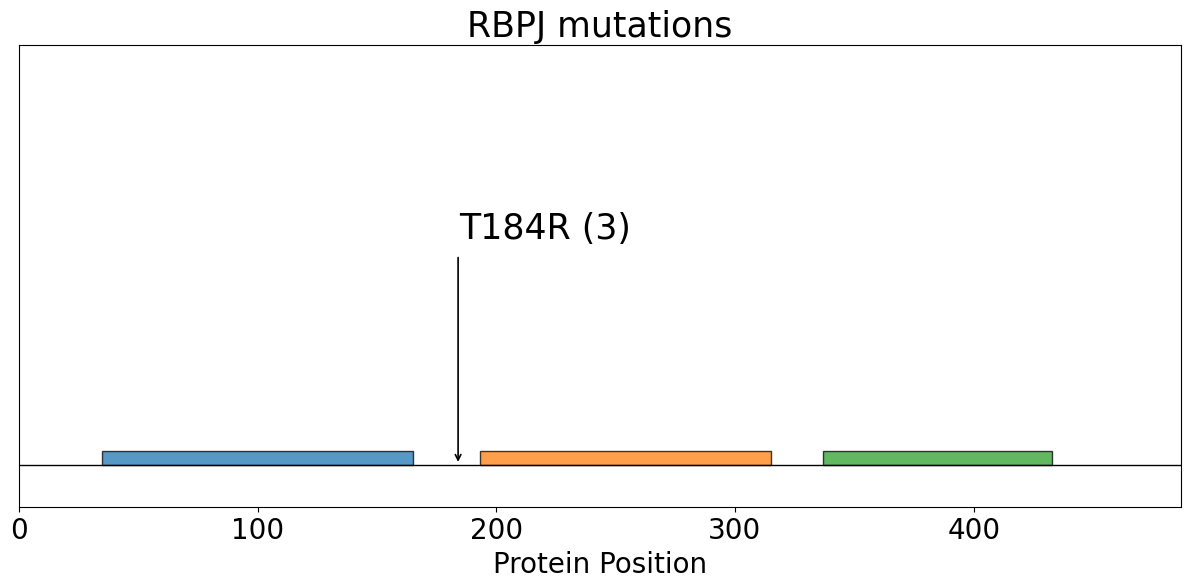

In [89]:
df = gene_features_regions
fig, ax = plt.subplots(figsize=(15, 6))

# Get the 'tab10' colormap for distinct colors
cmap = plt.get_cmap('tab10')
N = 10  # Number of colors in 'tab10'

# Plot each feature as a rectangle with a unique color
for i, (index, row) in enumerate(df.iterrows()):
    start = row['start']
    stop = row['stop']
    name = row['Note']
    color = cmap((i % N) / N)  # Assign color from colormap, cycling every 10 features
    rect = plt.Rectangle((start, 0), stop - start, 1, facecolor=color, edgecolor='black', alpha=0.75)
    ax.add_patch(rect)

# Set x-axis limits based on data
xmin = 0
xmax = 487
ax.set_xlim(xmin, xmax)

# Set y-axis limits to show rectangles and labels
ax.set_ylim(-3, 30)

# Remove y-axis ticks since all rectangles are on one line
ax.tick_params(axis='y',          # Apply to y-axis
               which='both',      # Apply to both major and minor ticks
               left=False,        # Hide left ticks
               right=False,       # Hide right ticks
               labelleft=False)  # Hide left tick labels

# Label x-axis
ax.set_xlabel('Protein Position', fontsize = 20)

# Add a horizontal line at y=0 to represent the sequence
ax.plot([xmin, xmax], [0, 0], color='black', linewidth=1)

# Add labels for each stem with mutation effect (refposalt)
texts = []
for i, row in rbpj_mutations.iterrows():
    label = f"{row['aa_reference']}{row['aa_mut_position']}{row['aa_alternative']} ({row['Number_samples']})"
    # Стрелка от точки к тексту (смещение: 5 вверх, 10 вправо)
    texts.append(
        plt.text(row['aa_mut_position'] + 0.1, 15 + 0.3, label,
                 fontsize=25,ha='left', va='bottom'))
    # Стрелка
    ax.annotate('',
                 xy=(row['aa_mut_position'], 0), xytext=(row['aa_mut_position'], 15),
                 arrowprops=dict(arrowstyle='->', lw=1.2),
                 fontsize=10)

adjust_text(texts,
            x=rbpj_mutations['aa_mut_position'], y=[15]*len(rbpj_mutations),
            arrowprops=dict(arrowstyle='-', color='black', lw=0),  # соединительные линии
            expand_text=(1.2, 1.2),   # расширение вокруг текста
            expand_points=(1.2, 1.2),
            force_text=(0.5, 0.5),    # сила отталкивания текста
            force_points=(0.3, 0.3),  # сила отталкивания от точек
            lim=100) # макс. итераций

ax.set_title('RBPJ mutations', fontsize = 25)

#plt.savefig('paper_figures/rbpj_lolipop.svg')

In [90]:
# For SIRPB1 gene

gene_features = pd.read_csv('NM_006065.gff3', sep='\t', skiprows=5, header=None)
gene_features[8] = gene_features[8].apply(lambda x: {pair.split('=')[0]: pair.split('=')[1] for pair in x.split(';')})

gene_features_regions = gene_features[gene_features[8].apply(lambda x: x['gbkey']) == 'Region']
gene_features_regions = gene_features_regions[gene_features_regions[8].apply(lambda x: 'Disordered' not in x['Name'])]

gene_features_regions['Note'] = gene_features_regions[8].apply(lambda x: x['Note'])
gene_features_regions['Name'] = gene_features_regions[8].apply(lambda x: x['Name'])

gene_features_regions.rename(columns = {3: 'start', 4: 'stop'}, inplace=True)
gene_features_regions.Name = gene_features_regions.Name.apply(lambda x: x.split('.')[0])
gene_features_regions['length'] = gene_features_regions.stop - gene_features_regions.start
gene_features_regions

,0,1,2,start,stop,5,6,7,8,Note,Name,length
4,NP_006056.2,RefSeq,biological_region,34,144,.,+,.,"{'ID': 'id-NP_006056.2:34..144', 'Dbxref': 'CD...",Immunoglobulin (Ig)-like variable (V) domain o...,IgV_SIRP,110
5,NP_006056.2,RefSeq,biological_region,34,55,.,+,.,"{'ID': 'id-NP_006056.2:34..55', 'Dbxref': 'CDD...",FR1 [structural motif],FR1,21
6,NP_006056.2,RefSeq,biological_region,34,37,.,+,.,"{'ID': 'id-NP_006056.2:34..37', 'Dbxref': 'CDD...",Ig strand A [structural motif],Ig strand A,3
9,NP_006056.2,RefSeq,biological_region,41,45,.,+,.,"{'ID': 'id-NP_006056.2:41..45', 'Dbxref': 'CDD...",Ig strand A' [structural motif],Ig strand A',4
10,NP_006056.2,RefSeq,biological_region,48,56,.,+,.,"{'ID': 'id-NP_006056.2:48..56', 'Dbxref': 'CDD...",Ig strand B [structural motif],Ig strand B,8
11,NP_006056.2,RefSeq,biological_region,56,62,.,+,.,"{'ID': 'id-NP_006056.2:56..62', 'Dbxref': 'CDD...",CDR1 [structural motif],CDR1,6
13,NP_006056.2,RefSeq,biological_region,63,71,.,+,.,"{'ID': 'id-NP_006056.2:63..71', 'Dbxref': 'CDD...",FR2 [structural motif],FR2,8
14,NP_006056.2,RefSeq,biological_region,63,69,.,+,.,"{'ID': 'id-NP_006056.2:63..69', 'Dbxref': 'CDD...",Ig strand C [structural motif],Ig strand C,6
15,NP_006056.2,RefSeq,biological_region,72,86,.,+,.,"{'ID': 'id-NP_006056.2:72..86', 'Dbxref': 'CDD...",CDR2 [structural motif],CDR2,14
16,NP_006056.2,RefSeq,biological_region,75,78,.,+,.,"{'ID': 'id-NP_006056.2:75..78', 'Dbxref': 'CDD...",Ig strand C' [structural motif],Ig strand C',3


In [91]:
gene_features_regions = gene_features_regions[~(gene_features_regions.Name.str.contains('Ig strand', na=False))]
gene_features_regions

,0,1,2,start,stop,5,6,7,8,Note,Name,length
4,NP_006056.2,RefSeq,biological_region,34,144,.,+,.,"{'ID': 'id-NP_006056.2:34..144', 'Dbxref': 'CD...",Immunoglobulin (Ig)-like variable (V) domain o...,IgV_SIRP,110
5,NP_006056.2,RefSeq,biological_region,34,55,.,+,.,"{'ID': 'id-NP_006056.2:34..55', 'Dbxref': 'CDD...",FR1 [structural motif],FR1,21
11,NP_006056.2,RefSeq,biological_region,56,62,.,+,.,"{'ID': 'id-NP_006056.2:56..62', 'Dbxref': 'CDD...",CDR1 [structural motif],CDR1,6
13,NP_006056.2,RefSeq,biological_region,63,71,.,+,.,"{'ID': 'id-NP_006056.2:63..71', 'Dbxref': 'CDD...",FR2 [structural motif],FR2,8
15,NP_006056.2,RefSeq,biological_region,72,86,.,+,.,"{'ID': 'id-NP_006056.2:72..86', 'Dbxref': 'CDD...",CDR2 [structural motif],CDR2,14
18,NP_006056.2,RefSeq,biological_region,87,125,.,+,.,"{'ID': 'id-NP_006056.2:87..125', 'Dbxref': 'CD...",FR3 [structural motif],FR3,38
22,NP_006056.2,RefSeq,biological_region,126,130,.,+,.,"{'ID': 'id-NP_006056.2:126..130', 'Dbxref': 'C...",CDR3 [structural motif],CDR3,4
24,NP_006056.2,RefSeq,biological_region,131,144,.,+,.,"{'ID': 'id-NP_006056.2:131..144', 'Dbxref': 'C...",FR4 [structural motif],FR4,13
26,NP_006056.2,RefSeq,biological_region,146,248,.,+,.,"{'ID': 'id-NP_006056.2:146..248', 'Dbxref': 'C...",Signal-regulatory protein (SIRP) immunoglobuli...,IgC1_SIRP_domain_2,102
38,NP_006056.2,RefSeq,biological_region,251,346,.,+,.,"{'ID': 'id-NP_006056.2:251..346', 'Dbxref': 'C...",Signal-regulatory protein (SIRP) immunoglobuli...,IgC1_SIRP_domain_3,95


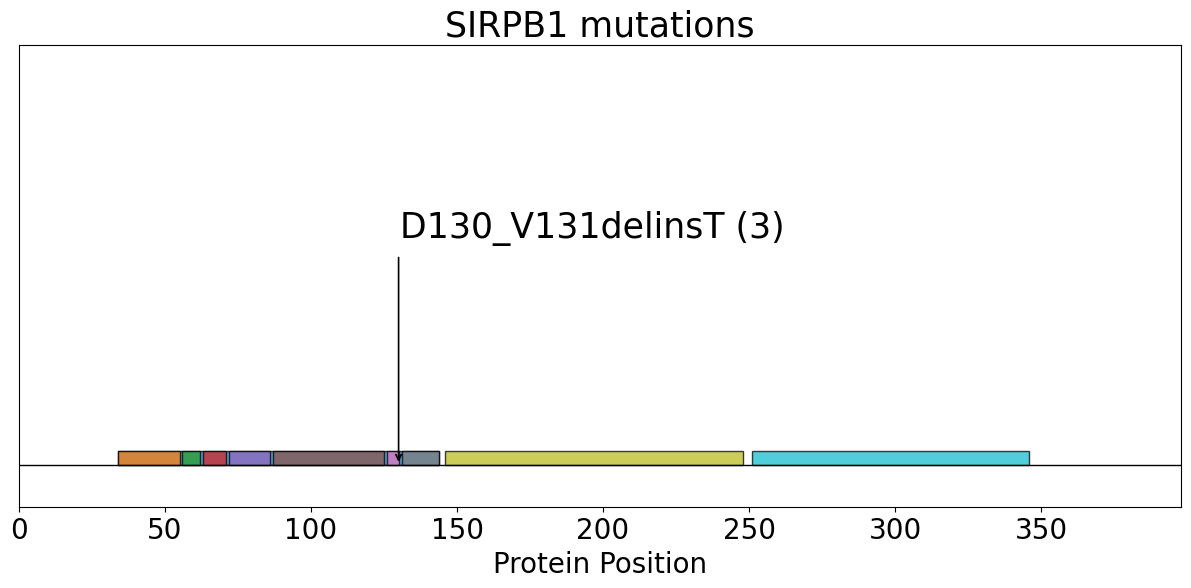

In [92]:
df = gene_features_regions
fig, ax = plt.subplots(figsize=(15, 6))

# Get the 'tab10' colormap for distinct colors
cmap = plt.get_cmap('tab10')
N = 10  # Number of colors in 'tab10'

# Plot each feature as a rectangle with a unique color
for i, (index, row) in enumerate(df.iterrows()):
    start = row['start']
    stop = row['stop']
    color = cmap((i % N) / N)  # Assign color from colormap, cycling every 10 features
    rect = plt.Rectangle((start, 0), stop - start, 1, facecolor=color, edgecolor='black', alpha=0.75)
    ax.add_patch(rect)

# Set x-axis limits based on data
xmin = 0
xmax = 398
ax.set_xlim(xmin, xmax)

# Set y-axis limits to show rectangles and labels
ax.set_ylim(-3, 30)

# Remove y-axis ticks since all rectangles are on one line
ax.tick_params(axis='y',          # Apply to y-axis
               which='both',      # Apply to both major and minor ticks
               left=False,        # Hide left ticks
               right=False,       # Hide right ticks
               labelleft=False)  # Hide left tick labels

# Label x-axis
ax.set_xlabel('Protein Position', fontsize = 20)

# Add a horizontal line at y=0 to represent the sequence
ax.plot([xmin, xmax], [0, 0], color='black', linewidth=1)

# Add labels for each stem with mutation effect (refposalt)
texts = []
label = f"D130_V131delinsT (3)"
# Стрелка от точки к тексту (смещение: 5 вверх, 10 вправо)
texts.append(
    plt.text(130 + 0.1, 15 + 0.3, label,
             fontsize=25,ha='left', va='bottom'))
# Стрелка
ax.annotate('',
                 xy=(130, 0), xytext=(130, 15),
                 arrowprops=dict(arrowstyle='->', lw=1.2),
                 fontsize=10)

adjust_text(texts,
            x=130, y=[15],
            arrowprops=dict(arrowstyle='-', color='black', lw=0),  # соединительные линии
            expand_text=(1.2, 1.2),   # расширение вокруг текста
            expand_points=(1.2, 1.2),
            force_text=(0.5, 0.5),    # сила отталкивания текста
            force_points=(0.3, 0.3),  # сила отталкивания от точек
            lim=100) # макс. итераций

ax.set_title('SIRPB1 mutations', fontsize = 25)

#plt.savefig('paper_figures/sirpb1_lolipop.svg')

In [93]:
# For UBE2N gene

gene_features = pd.read_csv('NM_003348.gff3', sep='\t', skiprows=5, header=None)
gene_features[8] = gene_features[8].apply(lambda x: {pair.split('=')[0]: pair.split('=')[1] for pair in x.split(';')})

gene_features_regions = gene_features[gene_features[8].apply(lambda x: x['gbkey']) == 'Region']
gene_features_regions = gene_features_regions[gene_features_regions[8].apply(lambda x: 'Disordered' not in x['Name'])]

gene_features_regions['Note'] = gene_features_regions[8].apply(lambda x: x['Note'])
gene_features_regions['Name'] = gene_features_regions[8].apply(lambda x: x['Name'])

gene_features_regions.rename(columns = {3: 'start', 4: 'stop'}, inplace=True)
gene_features_regions.Name = gene_features_regions.Name.apply(lambda x: x.split('.')[0])
gene_features_regions['length'] = gene_features_regions.stop - gene_features_regions.start
gene_features_regions

,0,1,2,start,stop,5,6,7,8,Note,Name,length
2,NP_003339.1,RefSeq,biological_region,4,147,.,+,.,"{'ID': 'id-NP_003339.1:4..147', 'Dbxref': 'CDD...",Ubiquitin-conjugating enzyme E2%2C catalytic (...,UBCc_UBE2N,143


In [94]:
ube2n_mutations = df_counts[df_counts['Gene.refGene'] == 'UBE2N']
prot_id = 'NM_003348'
ube2n_mutations['mutation_data'] = ube2n_mutations['AAChange.refGene'].apply(lambda x: extract_protein_change(x, prot_id))
ube2n_mutations['aa_mut_position'] = ube2n_mutations.mutation_data.apply(lambda x: x['position'])
ube2n_mutations['aa_reference'] = ube2n_mutations.mutation_data.apply(lambda x: x['reference'])
ube2n_mutations['aa_alternative'] = ube2n_mutations.mutation_data.apply(lambda x: x['alternative'])
ube2n_mutations

/tmp/ipykernel_44396/2285401585.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ube2n_mutations['mutation_data'] = ube2n_mutations['AAChange.refGene'].apply(lambda x: extract_protein_change(x, prot_id))
/tmp/ipykernel_44396/2285401585.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ube2n_mutations['aa_mut_position'] = ube2n_mutations.mutation_data.apply(lambda x: x['position'])
/tmp/ipykernel_44396/2285401585.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

,W_FGF_1,W_FGF_3,W_FGF_4,W_FGF_6,W_FGF_7,W_FGF_10,W_FGF_12,W_FGF_13,W_FGF_15,W_FGF_16,...,RuSeq_AF,ENC_AF,ExonicFunc.refGene,CLNREVSTAT,Number_samples,Samples,mutation_data,aa_mut_position,aa_reference,aa_alternative
48,0,1,1,0,0,0,0,0,0,0,...,0.005732,0.0,nonsynonymous SNV,.,2,"W_FGF_3, W_FGF_4","{'position': 63, 'reference': 'P', 'alternativ...",63,P,A


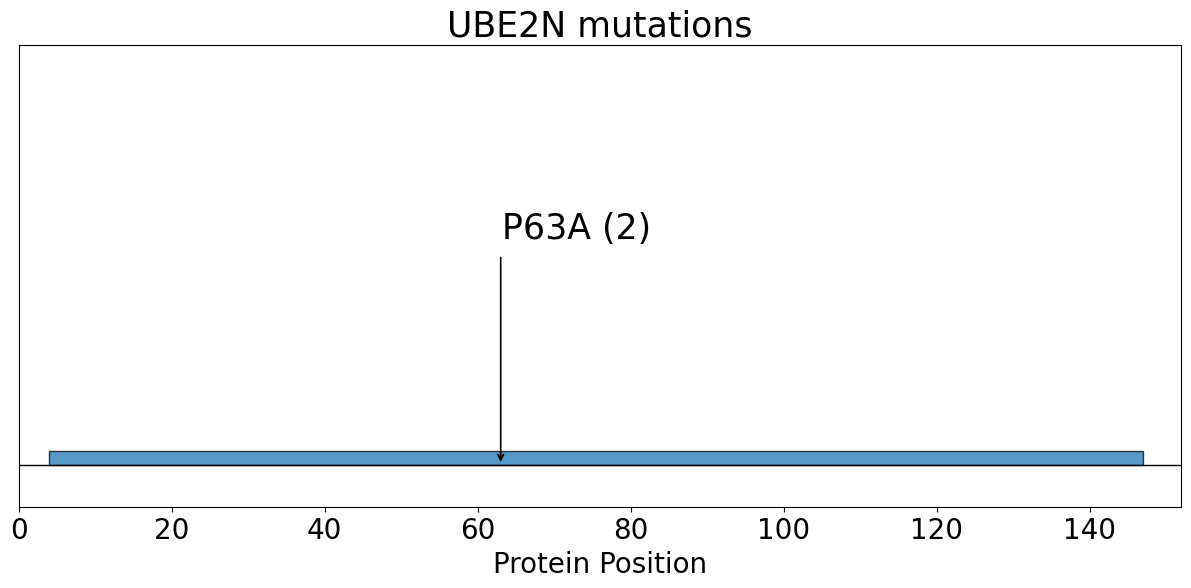

In [95]:
df = gene_features_regions
fig, ax = plt.subplots(figsize=(15, 6))

# Get the 'tab10' colormap for distinct colors
cmap = plt.get_cmap('tab10')
N = 10  # Number of colors in 'tab10'

# Plot each feature as a rectangle with a unique color
for i, (index, row) in enumerate(df.iterrows()):
    start = row['start']
    stop = row['stop']
    color = cmap((i % N) / N)  # Assign color from colormap, cycling every 10 features
    rect = plt.Rectangle((start, 0), stop - start, 1, facecolor=color, edgecolor='black', alpha=0.75)
    ax.add_patch(rect)

# Set x-axis limits based on data
xmin = 0
xmax = 152
ax.set_xlim(xmin, xmax)

# Set y-axis limits to show rectangles and labels
ax.set_ylim(-3, 30)

# Remove y-axis ticks since all rectangles are on one line
ax.tick_params(axis='y',          # Apply to y-axis
               which='both',      # Apply to both major and minor ticks
               left=False,        # Hide left ticks
               right=False,       # Hide right ticks
               labelleft=False)  # Hide left tick labels

# Label x-axis
ax.set_xlabel('Protein Position', fontsize = 20)

# Add a horizontal line at y=0 to represent the sequence
ax.plot([xmin, xmax], [0, 0], color='black', linewidth=1)

# Add labels for each stem with mutation effect (refposalt)
texts = []
for i, row in ube2n_mutations.iterrows():
    label = f"{row['aa_reference']}{row['aa_mut_position']}{row['aa_alternative']} ({row['Number_samples']})"
    # Стрелка от точки к тексту (смещение: 5 вверх, 10 вправо)
    texts.append(
        plt.text(row['aa_mut_position'] + 0.1, 15 + 0.3, label,
                 fontsize=25,ha='left', va='bottom'))
    # Стрелка
    ax.annotate('',
                 xy=(row['aa_mut_position'], 0), xytext=(row['aa_mut_position'], 15),
                 arrowprops=dict(arrowstyle='->', lw=1.2),
                 fontsize=10)

adjust_text(texts,
            x=ube2n_mutations['aa_mut_position'], y=[15]*len(ube2n_mutations),
            arrowprops=dict(arrowstyle='-', color='black', lw=0),  # соединительные линии
            expand_text=(1.2, 1.2),   # расширение вокруг текста
            expand_points=(1.2, 1.2),
            force_text=(0.5, 0.5),    # сила отталкивания текста
            force_points=(0.3, 0.3),  # сила отталкивания от точек
            lim=100) # макс. итераций

ax.set_title('UBE2N mutations', fontsize = 25)

#plt.savefig('paper_figures/ube2n_lolipop.svg')